# 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## importing data

In [2]:
file_addr = 'try.csv'
dataset  = pd.read_csv(file_addr)
dataset

,date,hostel,meal,pwaste,twaste,foodsample,kwaste,hostel type
0,02-03-2025,A,breakfast,6.80,1.8,0.5,0.100,girls
1,02-03-2025,B,breakfast,5.30,2.4,0.6,7.600,boys
2,02-03-2025,C,breakfast,3.10,1.6,0.8,0.011,boys
3,02-03-2025,D,breakfast,13.11,2.6,0.8,3.800,boys
4,02-03-2025,FRG,breakfast,4.11,NaN,NaN,2.500,boys
...,...,...,...,...,...,...,...,...
145,06-03-2025,M,dinner,13.60,5.7,0.6,6.900,boys
146,06-03-2025,N,dinner,6.50,3.0,0.6,3.600,girls
147,06-03-2025,O,dinner,15.40,4.3,0.6,9.200,boys
148,06-03-2025,PG,dinner,6.50,NaN,NaN,4.200,girls


## Data-preprocessing

In [3]:
dataset.isnull().sum()

date            0
hostel          0
meal            0
pwaste          4
twaste         32
foodsample     33
kwaste          9
hostel type     0
dtype: int64

One

### filling up missing values with their median

In [4]:
dataset[['pwaste', 'kwaste', 'foodsample', 'twaste']] = (dataset[['pwaste', 'kwaste', 'foodsample', 'twaste']]).apply(lambda col:col.fillna(col.median()) if col.dtype != 'O' else col)
dataset

,date,hostel,meal,pwaste,twaste,foodsample,kwaste,hostel type
0,02-03-2025,A,breakfast,6.80,1.8,0.5,0.100,girls
1,02-03-2025,B,breakfast,5.30,2.4,0.6,7.600,boys
2,02-03-2025,C,breakfast,3.10,1.6,0.8,0.011,boys
3,02-03-2025,D,breakfast,13.11,2.6,0.8,3.800,boys
4,02-03-2025,FRG,breakfast,4.11,4.3,0.6,2.500,boys
...,...,...,...,...,...,...,...,...
145,06-03-2025,M,dinner,13.60,5.7,0.6,6.900,boys
146,06-03-2025,N,dinner,6.50,3.0,0.6,3.600,girls
147,06-03-2025,O,dinner,15.40,4.3,0.6,9.200,boys
148,06-03-2025,PG,dinner,6.50,4.3,0.6,4.200,girls


In [5]:
dataset.isnull().sum()

date           0
hostel         0
meal           0
pwaste         0
twaste         0
foodsample     0
kwaste         0
hostel type    0
dtype: int64

### Encoding Categorical Data

#### OneHotEncoding on 'meal'

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# one_hot_encoder = OneHotEncoder(sparse_output=False)

# one_hot_encoded_meal = one_hot_encoder.fit_transform(dataset[['meal']]) # we apply double square brackets as to not pass a 'series', to make a dataframe we use this approach

# one_hot_encoded_meal

transformer = ColumnTransformer(
    transformers=[
        ('ohe_meal', OneHotEncoder(sparse_output=False),['meal'])
    ],
    remainder='passthrough'
)

df_transformed = transformer.fit_transform(dataset)

encoded_column_names = (transformer.named_transformers_['ohe_meal'].get_feature_names_out(['meal']))
remainder_column_names = dataset.columns.difference(['meal'], sort = False).to_list()

new_column_names = list(encoded_column_names) + remainder_column_names

dataset = pd.DataFrame(df_transformed, columns=new_column_names)

dataset

,meal_breakfast,meal_dinner,meal_lunch,date,hostel,pwaste,twaste,foodsample,kwaste,hostel type
0,1.0,0.0,0.0,02-03-2025,A,6.8,1.8,0.5,0.1,girls
1,1.0,0.0,0.0,02-03-2025,B,5.3,2.4,0.6,7.6,boys
2,1.0,0.0,0.0,02-03-2025,C,3.1,1.6,0.8,0.011,boys
3,1.0,0.0,0.0,02-03-2025,D,13.11,2.6,0.8,3.8,boys
4,1.0,0.0,0.0,02-03-2025,FRG,4.11,4.3,0.6,2.5,boys
...,...,...,...,...,...,...,...,...,...,...
145,0.0,1.0,0.0,06-03-2025,M,13.6,5.7,0.6,6.9,boys
146,0.0,1.0,0.0,06-03-2025,N,6.5,3.0,0.6,3.6,girls
147,0.0,1.0,0.0,06-03-2025,O,15.4,4.3,0.6,9.2,boys
148,0.0,1.0,0.0,06-03-2025,PG,6.5,4.3,0.6,4.2,girls


#### Binary Encoding on 'hostel'

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset['hostel'] = le.fit_transform(dataset['hostel'])

def int_to_binary(n, bits):
    return list(np.binary_repr(n, width=bits))

numberOfBits = len(np.binary_repr(dataset['hostel'].max()))

binary_hostel = dataset['hostel'].apply(lambda x: int_to_binary(x, numberOfBits))

binary_hostel = pd.DataFrame(binary_hostel.tolist(), columns = [f'hostel_binary_{i}' for i in range(numberOfBits)])

dataset = pd.concat([dataset.drop(columns = ['hostel']), binary_hostel], axis = 1)

dataset

,meal_breakfast,meal_dinner,meal_lunch,date,pwaste,twaste,foodsample,kwaste,hostel type,hostel_binary_0,hostel_binary_1,hostel_binary_2,hostel_binary_3
0,1.0,0.0,0.0,02-03-2025,6.8,1.8,0.5,0.1,girls,0,0,0,0
1,1.0,0.0,0.0,02-03-2025,5.3,2.4,0.6,7.6,boys,0,0,0,1
2,1.0,0.0,0.0,02-03-2025,3.1,1.6,0.8,0.011,boys,0,0,1,0
3,1.0,0.0,0.0,02-03-2025,13.11,2.6,0.8,3.8,boys,0,0,1,1
4,1.0,0.0,0.0,02-03-2025,4.11,4.3,0.6,2.5,boys,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.0,1.0,0.0,06-03-2025,13.6,5.7,0.6,6.9,boys,0,1,0,1
146,0.0,1.0,0.0,06-03-2025,6.5,3.0,0.6,3.6,girls,0,1,1,0
147,0.0,1.0,0.0,06-03-2025,15.4,4.3,0.6,9.2,boys,0,1,1,1
148,0.0,1.0,0.0,06-03-2025,6.5,4.3,0.6,4.2,girls,1,0,0,0


In [8]:
dataset.columns

Index(['meal_breakfast', 'meal_dinner', 'meal_lunch', 'date', 'pwaste',
       'twaste', 'foodsample', 'kwaste', 'hostel type', 'hostel_binary_0',
       'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3'],
      dtype='object')

#### One Hot Encoding 'hostel type'

In [9]:
dataset['hostel type']

0      girls
1       boys
2       boys
3       boys
4       boys
       ...  
145     boys
146    girls
147     boys
148    girls
149    girls
Name: hostel type, Length: 150, dtype: object

In [10]:
transformer = ColumnTransformer(
    transformers=[
        ('ohe_hostel_type', OneHotEncoder(sparse_output=False),['hostel type'])
    ],
    remainder = 'passthrough'
)

dataset_transformed = transformer.fit_transform(dataset)

encoded_cols_names = transformer.named_transformers_['ohe_hostel_type'].get_feature_names_out(['hostel type'])
remiander_cols_names = dataset.columns.difference(['hostel type'], sort = False).to_list()

col_names = list(encoded_cols_names) + remiander_cols_names

dataset = pd.DataFrame(dataset_transformed, columns = col_names)

dataset

,hostel type_boys,hostel type_girls,meal_breakfast,meal_dinner,meal_lunch,date,pwaste,twaste,foodsample,kwaste,hostel_binary_0,hostel_binary_1,hostel_binary_2,hostel_binary_3
0,0.0,1.0,1.0,0.0,0.0,02-03-2025,6.8,1.8,0.5,0.1,0,0,0,0
1,1.0,0.0,1.0,0.0,0.0,02-03-2025,5.3,2.4,0.6,7.6,0,0,0,1
2,1.0,0.0,1.0,0.0,0.0,02-03-2025,3.1,1.6,0.8,0.011,0,0,1,0
3,1.0,0.0,1.0,0.0,0.0,02-03-2025,13.11,2.6,0.8,3.8,0,0,1,1
4,1.0,0.0,1.0,0.0,0.0,02-03-2025,4.11,4.3,0.6,2.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1.0,0.0,0.0,1.0,0.0,06-03-2025,13.6,5.7,0.6,6.9,0,1,0,1
146,0.0,1.0,0.0,1.0,0.0,06-03-2025,6.5,3.0,0.6,3.6,0,1,1,0
147,1.0,0.0,0.0,1.0,0.0,06-03-2025,15.4,4.3,0.6,9.2,0,1,1,1
148,0.0,1.0,0.0,1.0,0.0,06-03-2025,6.5,4.3,0.6,4.2,1,0,0,0


## Data Insights

In [11]:
sns.set_style("darkgrid", {
    'axes.facecolor' : 'black',
    'figure.facecolor' : 'black',
    'grid.color' : 'white'
})


In [12]:
# df_long = pd.melt(dataset, id_vars="date", value_vars = ["twaste", "pwaste", "kwaste", "foodsample"], value_name="waste in kgs", var_name = "waste")
# df_long

In [13]:
# sns.barplot(df_long, x = "date", y = "waste in kgs", hue = "waste", palette="colorblind")
# sns.lineplot(dataset, x = "date", y = dataset.loc[:, 'pwaste'])
# plt.title("waste generated v/s dates", color = "white")
# plt.xticks(color = "white")
# plt.yticks(color = "white")
# plt.xlabel('dates', color = 'white')
# plt.ylabel('waste in kgs', color = 'white')
# legend = plt.legend()
# legend.set_title("waste")
# for text in legend.get_texts():
#     text.set_color('white')
# if legend.get_title():
#     legend.get_title().set_color('white')
# plt.show()

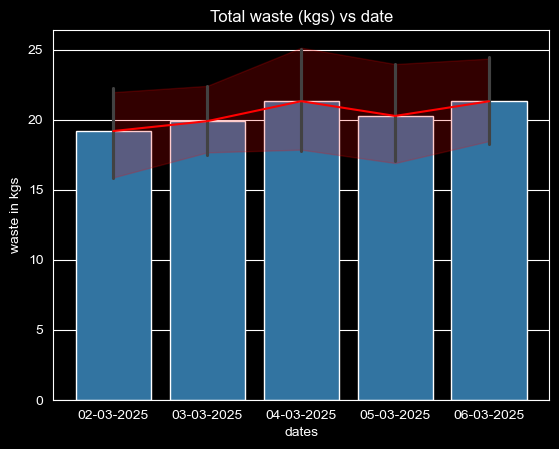

In [14]:
total_waste = dataset.loc[:, 'twaste'] + dataset.loc[:, 'pwaste'] + dataset.loc[:, 'foodsample'] + dataset.loc[:, 'kwaste']
sns.barplot(dataset, x = dataset.loc[:, 'date'], y = total_waste)
sns.lineplot(dataset, x = dataset.loc[:, 'date'], y = total_waste, color = 'red')
plt.title("Total waste (kgs) vs date", color = 'white')
plt.xlabel('dates', color = 'white')
plt.ylabel('waste in kgs', color = 'white')
plt.xticks(color = 'white')
plt.yticks(color = 'white')
plt.show()

In [15]:
total = dataset.loc[:, 'twaste'] + dataset.loc[:, 'pwaste'] + dataset.loc[:, 'kwaste'] + dataset.loc[:, 'foodsample']
print(total.shape)
dataset.shape


(150,)


(150, 14)

# now random forest

Using binary hostel columns: ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
Mapped decoded hostel IDs to names: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'FRG', 5: 'M', 6: 'N', 7: 'O', 8: 'PG', 9: 'Q'}

Hostel Ranking by Total Waste Generation:
  hostel_name total_waste
7           O      416.51
3           D      398.32
5           M   382.82031
0           A      377.11
1           B      365.71
4         FRG      252.51
9           Q       248.9
6           N    232.5505
2           C     193.031
8          PG       191.1


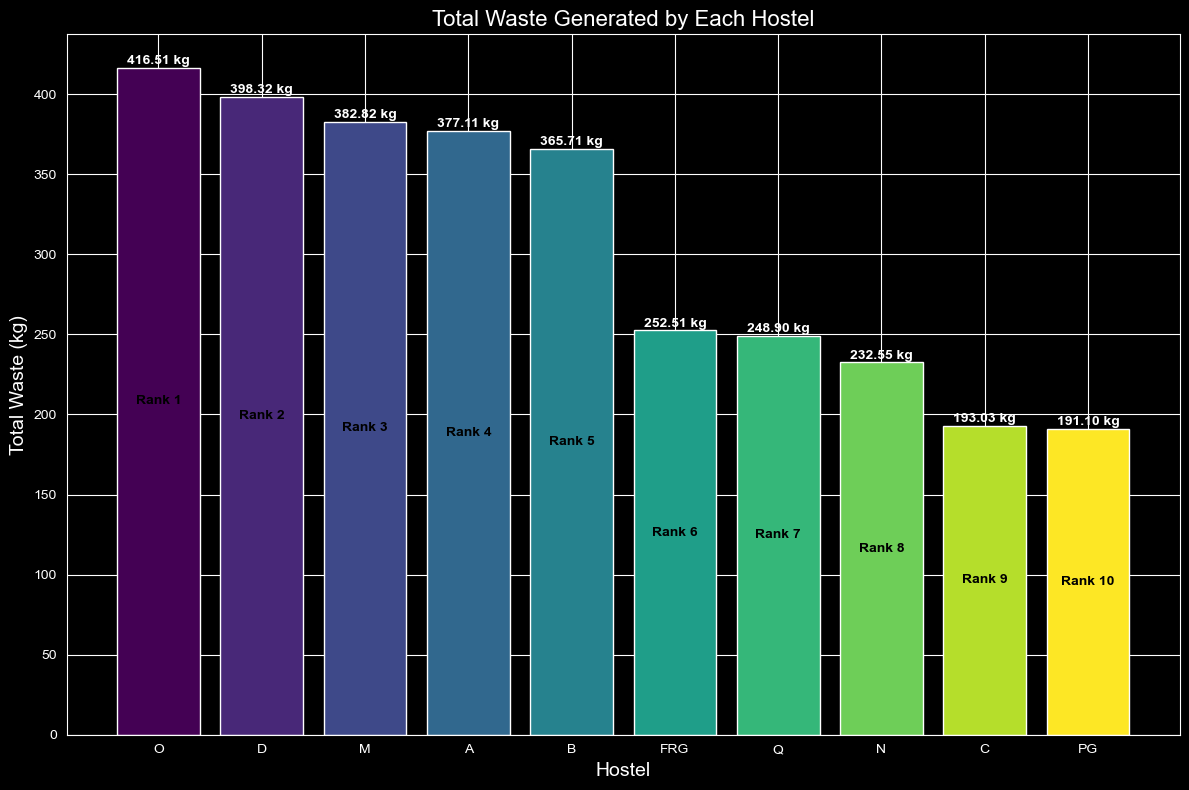

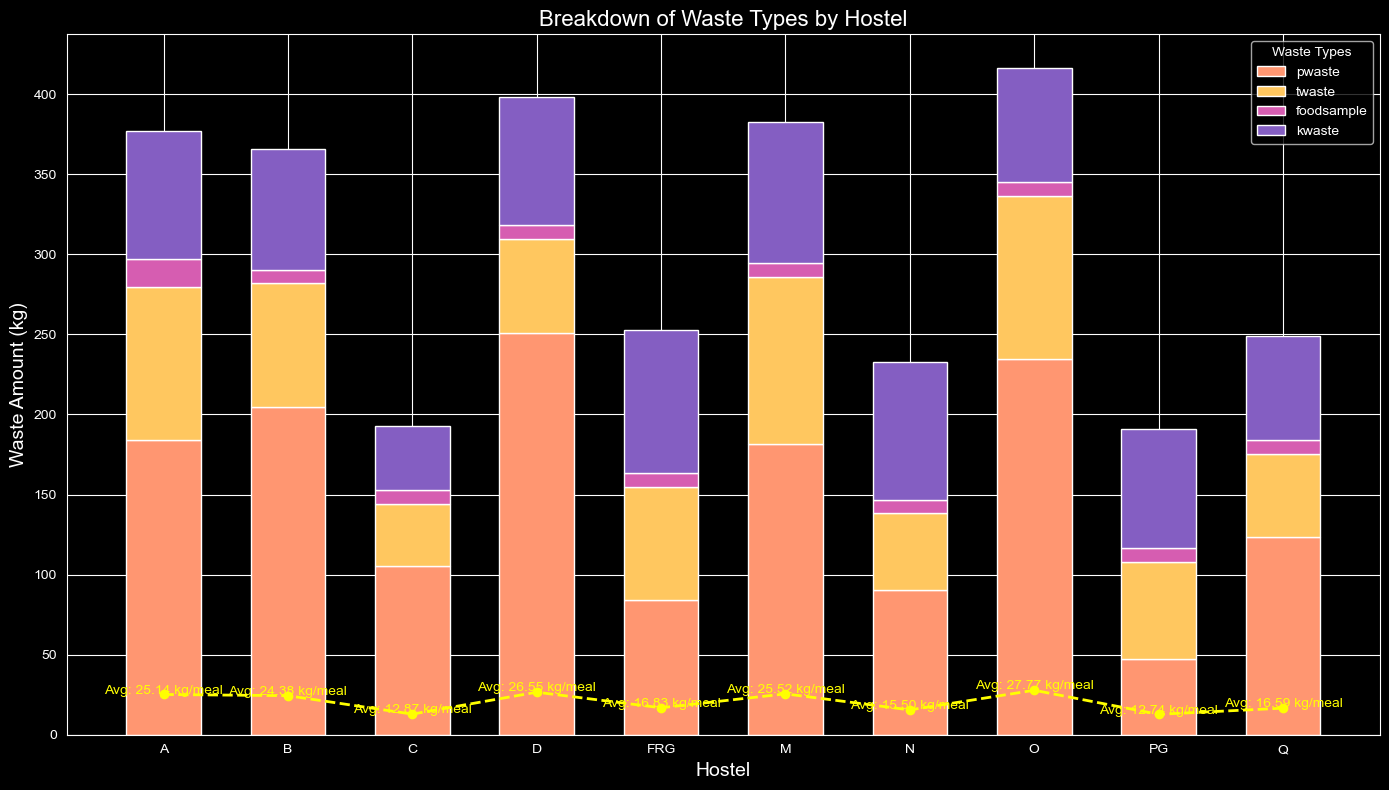


All available numeric columns: ['decoded_hostel']

Selected features for prediction: []
Number of features: 0

Feature data types:
pwaste: object
kwaste: object
foodsample: object
twaste: object

X shape: (150, 4), y shape: (150,)
Train set: (120, 4), Test set: (30, 4)

Training Random Forest model to predict total waste...
Model Performance:
Mean Squared Error: 2.64
Mean Absolute Error: 1.08
R² Score: 0.94

Factors influencing waste generation:
      Feature  Importance
0      pwaste    0.652966
1      kwaste    0.226258
3      twaste    0.113215
2  foodsample    0.007561


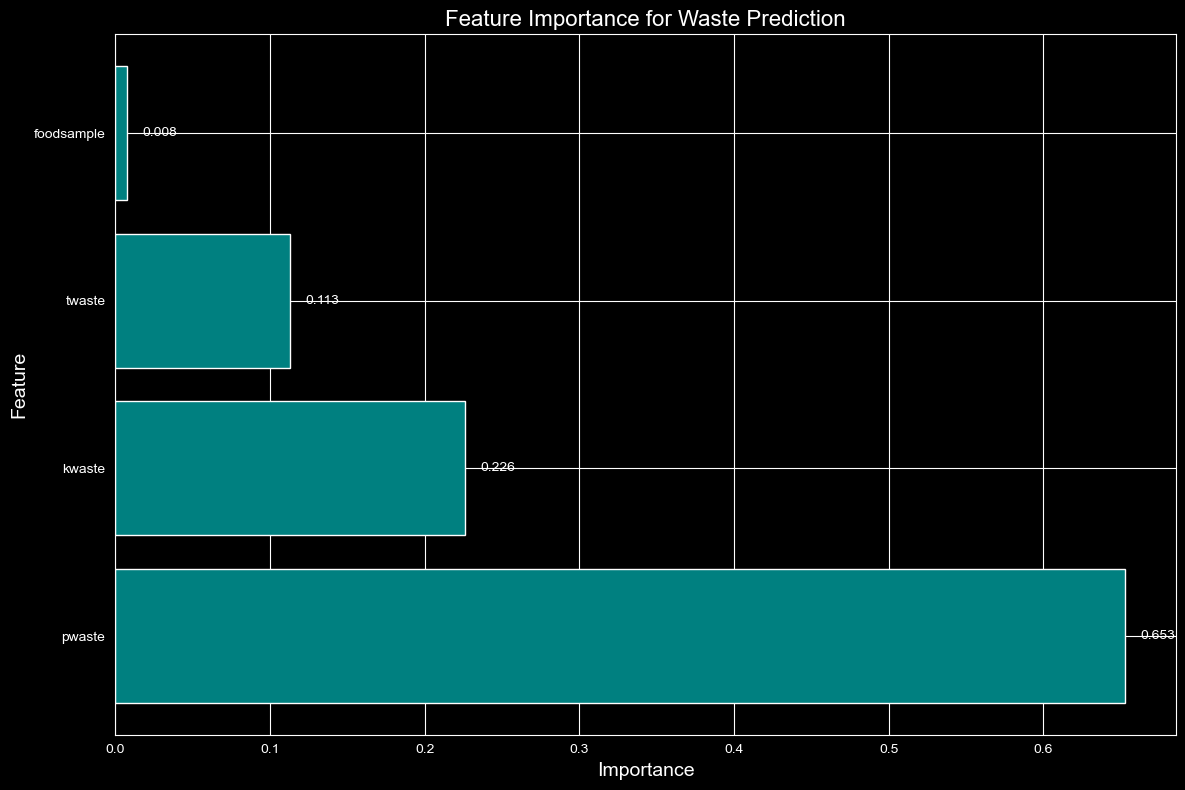

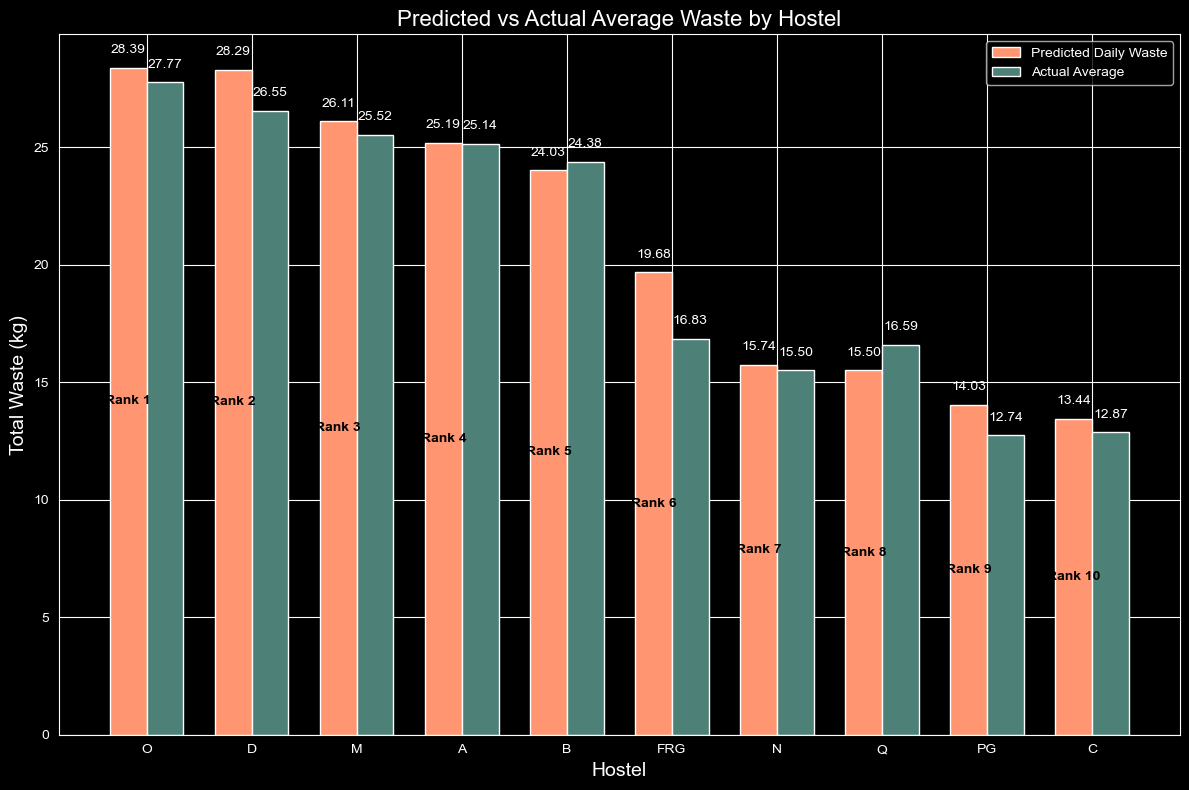

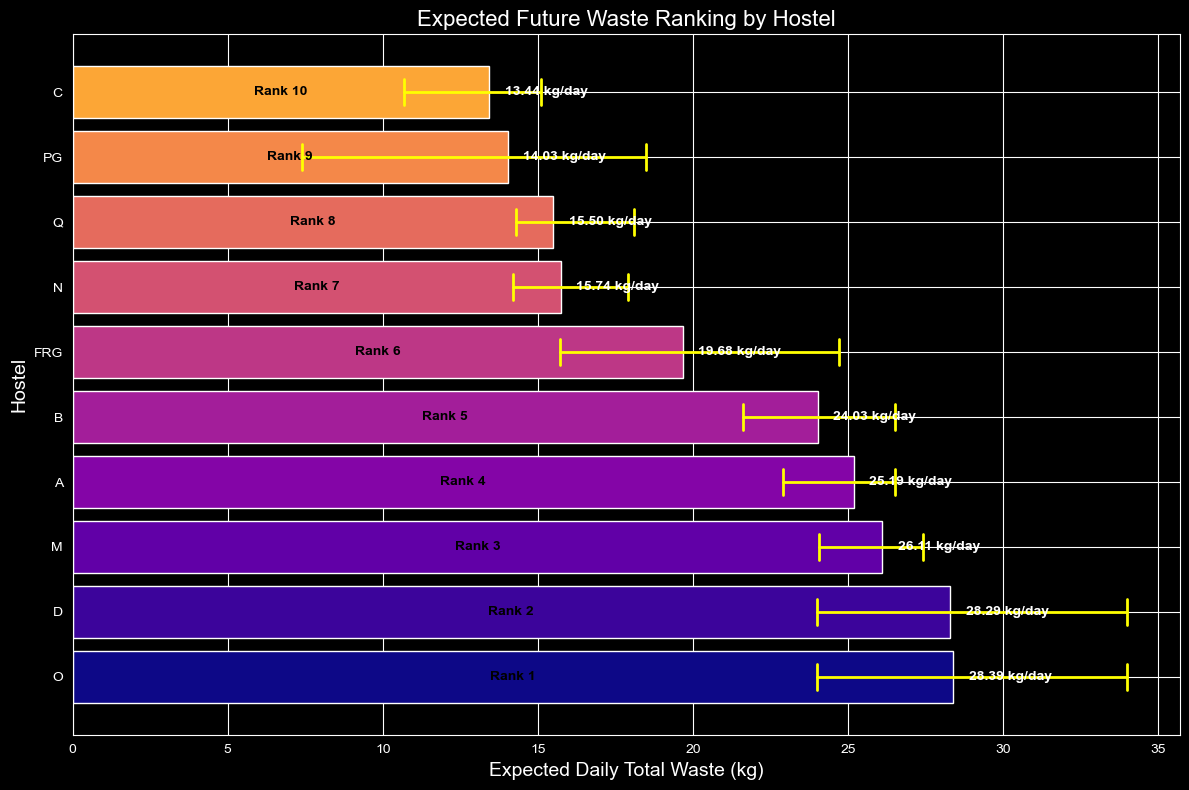


===== WASTE REDUCTION RECOMMENDATIONS =====

Hostel O - Rank 1 (Expected daily waste: 28.39 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• HIGH PLATE WASTE (56.3%): Consider reducing portion sizes
  and monitoring student food preferences
• Based on our model, focus on optimizing: pwaste

Hostel D - Rank 2 (Expected daily waste: 28.29 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• HIGH PLATE WASTE (63.0%): Consider reducing portion sizes
  and monitoring student food preferences
• Based on our model, focus on optimizing: pwaste

Hostel M - Rank 3 (Expected daily waste: 26.11 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• MODERATE PLATE WASTE (47.4%): Review serving practices
• Based on our model, focus on optimizing: pwaste

Hostel A - Rank 4 (Expected daily waste: 25.19 kg)
• MODERATE PLATE WASTE (48.8%): Review serving practices
• Based on our model, focus on optimizing: pwaste

Hostel B - Rank 5 (Expected da

In [17]:
# ======================================
# RANDOM FOREST WASTE PREDICTION MODEL
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configure plot style
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Calculate total waste for each entry
dataset['total_waste'] = dataset['pwaste'] + dataset['twaste'] + dataset['foodsample'] + dataset['kwaste']

# ===============================
# DECODE BINARY HOSTEL COLUMNS
# ===============================

# Identify the binary hostel columns
binary_cols = ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
print(f"Using binary hostel columns: {binary_cols}")

# Create a function to decode the binary encoding to hostel IDs
def decode_hostel_id(row):
    binary_string = ''
    for col in binary_cols:
        binary_string += str(int(row[col]))
    return int(binary_string, 2)

# Apply the decoding function
dataset['decoded_hostel'] = dataset.apply(decode_hostel_id, axis=1)

# Define correct hostel names
correct_hostel_names = ["A", "B", "C", "D", "FRG", "M", "N", "O", "PG", "Q"]

# Map the decoded hostel IDs to the correct names
unique_hostel_ids = sorted(dataset['decoded_hostel'].unique())
hostel_name_map = {}

for i, hostel_id in enumerate(unique_hostel_ids):
    if i < len(correct_hostel_names):
        hostel_name_map[hostel_id] = correct_hostel_names[i]
    else:
        # If we have more unique IDs than names, use the ID as a string
        hostel_name_map[hostel_id] = f"Hostel {hostel_id}"

# Add the hostel name to the dataset
dataset['hostel_name'] = dataset['decoded_hostel'].map(hostel_name_map)

print(f"Mapped decoded hostel IDs to names: {hostel_name_map}")

# ===============================
# PART 1: HOSTEL WASTE ANALYSIS
# ===============================

# Get total waste by hostel
hostel_waste = dataset.groupby('hostel_name')['total_waste'].sum().reset_index()
hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)

# Display the ranked results
print("\nHostel Ranking by Total Waste Generation:")
print(hostel_waste)

# Visualization 1: Total Waste by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f} kg',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 2: Waste Type Breakdown by Hostel
waste_types = ['pwaste', 'twaste', 'foodsample', 'kwaste']
hostel_waste_breakdown = dataset.groupby('hostel_name')[waste_types].sum().reset_index()

plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste_breakdown))
width = 0.6
bottom = np.zeros(len(hostel_waste_breakdown))

# Create the stacked bars
colors = ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']
for i, waste_type in enumerate(waste_types):
    plt.bar(x, hostel_waste_breakdown[waste_type], width, bottom=bottom, 
           label=waste_type, color=colors[i])
    bottom += hostel_waste_breakdown[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste_breakdown['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add average waste per meal line
avg_waste_per_meal = dataset.groupby('hostel_name')['total_waste'].mean()
hostel_order = hostel_waste_breakdown['hostel_name'].tolist()
avg_values = [avg_waste_per_meal[h] for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.5, f'Avg: {avg:.2f} kg/meal', ha='center', color='yellow', fontsize=10)

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# ===============================
# PART 2: RANDOM FOREST MODEL - FIXED
# ===============================

# Identify all numeric columns first
numeric_cols = [col for col in dataset.columns if 
                dataset[col].dtype in ['int64', 'float64', 'bool']]

# Print available numeric columns for debugging
print(f"\nAll available numeric columns: {numeric_cols}")

# Now identify which ones to use as features (exclude target and identifiers)
exclude_cols = ['total_waste', 'decoded_hostel'] + binary_cols
X_cols = [col for col in numeric_cols if col not in exclude_cols]

# Print selected features
print(f"\nSelected features for prediction: {X_cols}")
print(f"Number of features: {len(X_cols)}")

# If no features were found, manually select some
if len(X_cols) == 0:
    print("WARNING: No features automatically detected. Using waste components as features.")
    X_cols = ['pwaste', 'kwaste', 'foodsample', 'twaste']
    
# Print feature data types to verify they're numeric
print("\nFeature data types:")
for col in X_cols:
    print(f"{col}: {dataset[col].dtype}")

# Create feature matrix and target vector
X = dataset[X_cols].copy()
y = dataset['total_waste'].copy()

# Print shapes to verify data
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

# Handle any missing values
if X.isnull().any().any():
    print("Handling missing values in features...")
    X = X.fillna(X.mean())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
print("\nTraining Random Forest model to predict total waste...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFactors influencing waste generation:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(min(10, len(feature_importance)))
bars = plt.barh(top_features['Feature'], top_features['Importance'], color='teal')

plt.title('Feature Importance for Waste Prediction', color='white', fontsize=16)
plt.xlabel('Importance', color='white', fontsize=14)
plt.ylabel('Feature', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add importance values
for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', color='white', va='center')

plt.tight_layout()
plt.show()

# ===============================
# PART 3: PREDICTED WASTE BY HOSTEL
# ===============================

# Group data by hostel name for prediction
grouped_data = dataset.groupby('hostel_name')

# Calculate average features for each hostel
hostel_features = []
for name, group in grouped_data:
    # Calculate mean of each feature for this hostel
    avg_features = {col: group[col].mean() for col in X_cols}
    avg_features['hostel_name'] = name
    avg_features['actual_avg_waste'] = group['total_waste'].mean()
    hostel_features.append(avg_features)

# Convert to DataFrame
hostel_df = pd.DataFrame(hostel_features)

# Scale the features for prediction
pred_features = hostel_df[X_cols]
scaled_features = scaler.transform(pred_features)

# Predict waste for each hostel
hostel_df['predicted_waste'] = rf_model.predict(scaled_features)

# Sort by predicted waste
hostel_df = hostel_df.sort_values('predicted_waste', ascending=False)

# Visualization 3: Predicted vs Actual Waste
plt.figure(figsize=(12, 8))

# Create a comparison chart
x = np.arange(len(hostel_df))
width = 0.35

# Plot predicted and actual average
pred_bars = plt.bar(x - width/2, hostel_df['predicted_waste'], width, label='Predicted Daily Waste', color='#FF9671')
actual_bars = plt.bar(x + width/2, hostel_df['actual_avg_waste'], width, label='Actual Average', color='#4D8076')

plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.title('Predicted vs Actual Average Waste by Hostel', color='white', fontsize=16)
plt.xticks(x, hostel_df['hostel_name'], color='white')
plt.yticks(color='white')

# Add ranking numbers and values
for i, (pred, actual) in enumerate(zip(hostel_df['predicted_waste'], hostel_df['actual_avg_waste'])):
    plt.text(i - width/2, pred + 0.5, f'{pred:.2f}', ha='center', va='bottom', color='white')
    plt.text(i + width/2, actual + 0.5, f'{actual:.2f}', ha='center', va='bottom', color='white')
    plt.text(i - width/2, pred/2, f'Rank {i+1}', ha='center', va='center', color='black', fontweight='bold')

# Set up legend with white text
legend = plt.legend()
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.show()

# Create confidence intervals using model's prediction variance
hostel_predictions = []

# For each hostel, get predictions from all trees in the forest to calculate confidence interval
for i, row in hostel_df.iterrows():
    hostel_name = row['hostel_name']
    features = pred_features.iloc[i:i+1]
    scaled_feat = scaler.transform(features)
    
    # Get predictions from all trees in the forest
    predictions = []
    for tree in rf_model.estimators_:
        predictions.append(tree.predict(scaled_feat)[0])
    
    # Calculate statistics
    mean_pred = np.mean(predictions)
    lower_bound = np.percentile(predictions, 5)
    upper_bound = np.percentile(predictions, 95)
    
    hostel_predictions.append({
        'Hostel': hostel_name,
        'Predicted_Waste': mean_pred,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Actual_Average': row['actual_avg_waste']
    })

# Convert to DataFrame and sort
future_df = pd.DataFrame(hostel_predictions).sort_values('Predicted_Waste', ascending=False)

# Final visualization: Future waste prediction with confidence intervals
plt.figure(figsize=(12, 8))

# Plot the predictions with confidence intervals
bars = plt.barh(future_df['Hostel'], future_df['Predicted_Waste'], 
               color=plt.cm.plasma(np.linspace(0, 0.8, len(future_df))))

# Add error bars for confidence intervals
for i, (lower, upper) in enumerate(zip(future_df['Lower_Bound'], future_df['Upper_Bound'])):
    plt.plot([lower, upper], [i, i], color='yellow', linewidth=2)
    plt.plot([lower, lower], [i-0.2, i+0.2], color='yellow', linewidth=2)
    plt.plot([upper, upper], [i-0.2, i+0.2], color='yellow', linewidth=2)

# Add value labels and ranking
for i, (bar, waste) in enumerate(zip(bars, future_df['Predicted_Waste'])):
    width = bar.get_width()
    plt.text(width + 0.5, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Expected Future Waste Ranking by Hostel', color='white', fontsize=16)
plt.xlabel('Expected Daily Total Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# ===============================
# PART 4: WASTE REDUCTION RECOMMENDATIONS
# ===============================

# Calculate waste composition percentages for each hostel
waste_percentages = {}
for name, group in dataset.groupby('hostel_name'):
    total = group[waste_types].sum().sum()
    percentages = {}
    for waste_type in waste_types:
        percentages[waste_type] = 100 * group[waste_type].sum() / total if total > 0 else 0
    waste_percentages[name] = percentages

print("\n===== WASTE REDUCTION RECOMMENDATIONS =====")

for i, row in future_df.iterrows():
    hostel = row['Hostel']
    pred_waste = row['Predicted_Waste']
    rank = i + 1
    
    # Get waste percentages
    if hostel in waste_percentages:
        percentages = waste_percentages[hostel]
        pwaste_pct = percentages['pwaste']
        kwaste_pct = percentages['kwaste']
    else:
        pwaste_pct = 0
        kwaste_pct = 0
    
    print(f"\nHostel {hostel} - Rank {rank} (Expected daily waste: {pred_waste:.2f} kg)")
    
    if rank <= 3:
        print("⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators")
    
    if pwaste_pct > 50:
        print(f"• HIGH PLATE WASTE ({pwaste_pct:.1f}%): Consider reducing portion sizes")
        print("  and monitoring student food preferences")
    elif pwaste_pct > 30:
        print(f"• MODERATE PLATE WASTE ({pwaste_pct:.1f}%): Review serving practices")
    
    if kwaste_pct > 40:
        print(f"• HIGH KITCHEN WASTE ({kwaste_pct:.1f}%): Improve food preparation methods")
        print("  and inventory management to reduce spoilage")
    
    # Add model-based recommendations using feature importance
    if not feature_importance.empty:
        top_feature = feature_importance['Feature'].iloc[0]
        print(f"• Based on our model, focus on optimizing: {top_feature}")

# now xg boost model

Using binary hostel columns: ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
Mapped decoded hostel IDs to names: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'FRG', 5: 'M', 6: 'N', 7: 'O', 8: 'PG', 9: 'Q'}

Hostel Ranking by Total Waste Generation:
  hostel_name total_waste
7           O      416.51
3           D      398.32
5           M   382.82031
0           A      377.11
1           B      365.71
4         FRG      252.51
9           Q       248.9
6           N    232.5505
2           C     193.031
8          PG       191.1


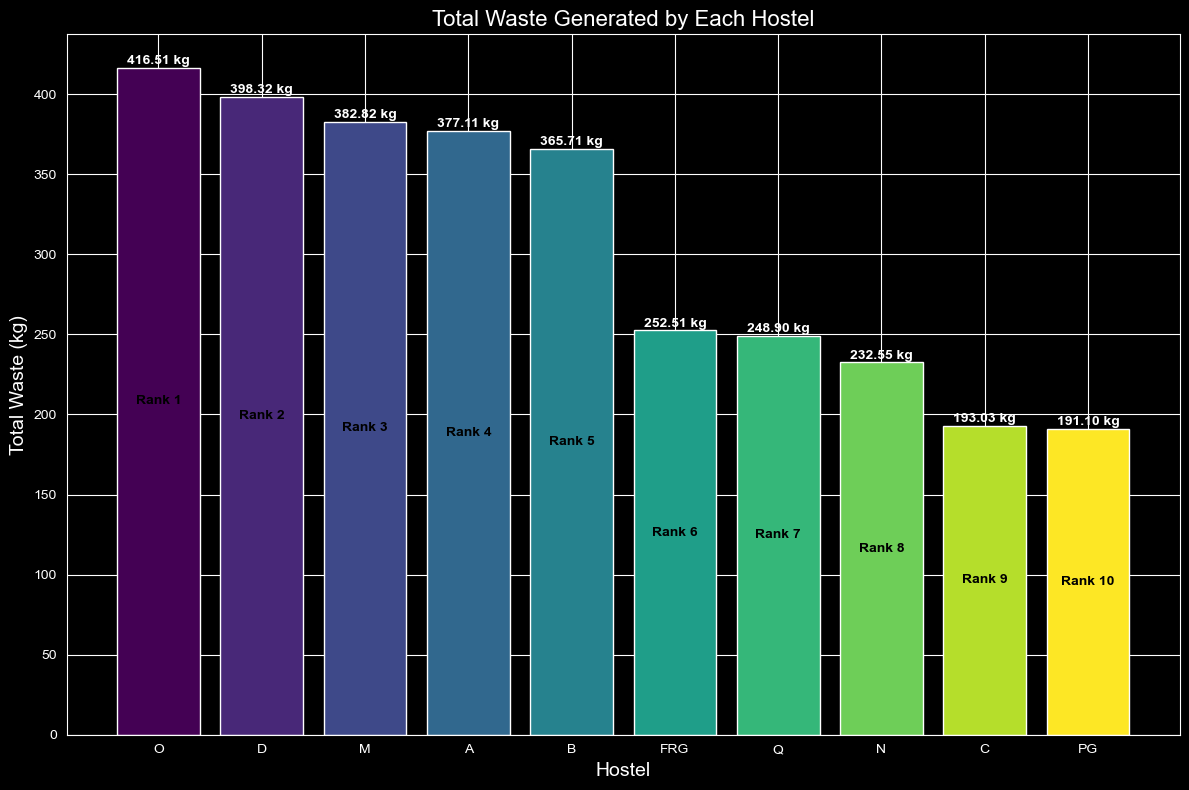

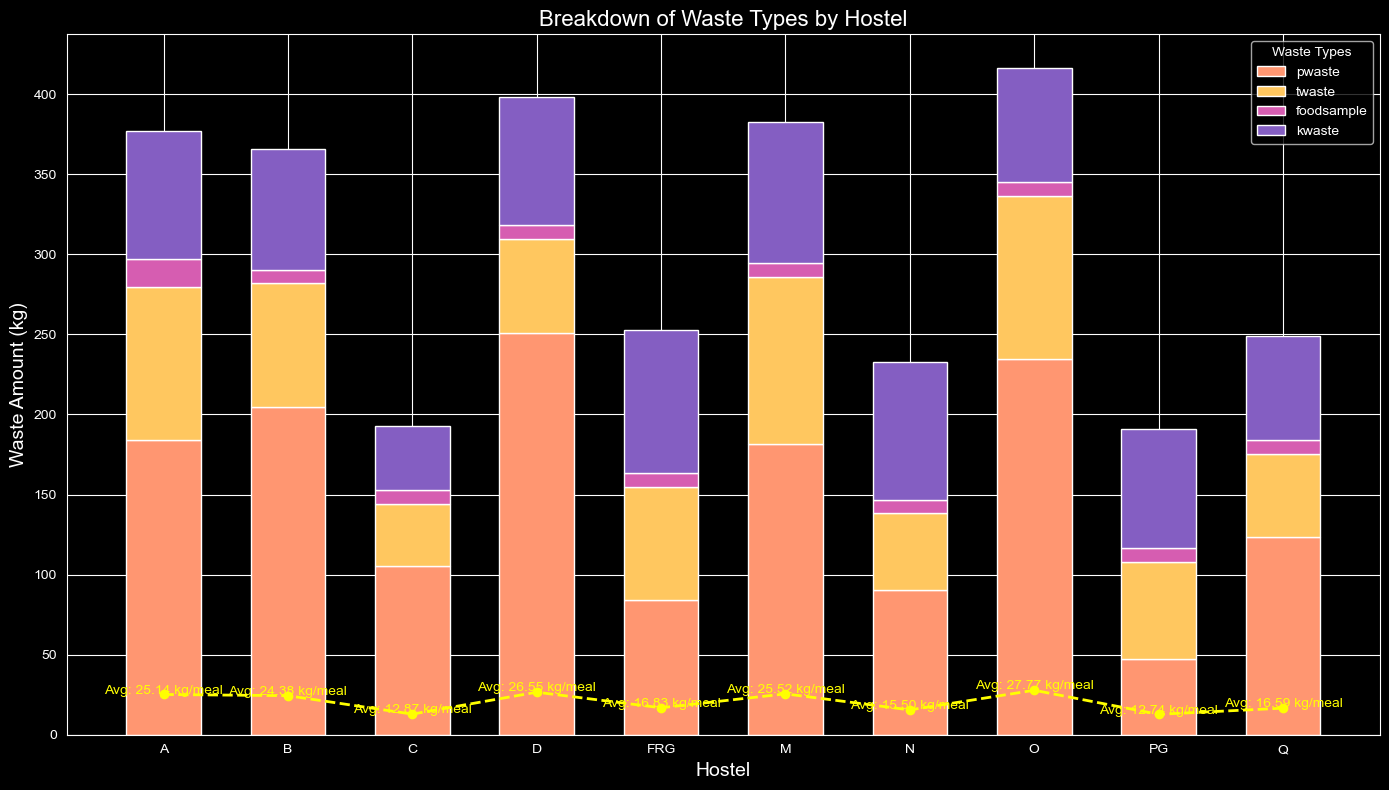


All available numeric columns: ['decoded_hostel']

Selected features for prediction: []
Number of features: 0

Feature data types:
pwaste: object
kwaste: object
foodsample: object
twaste: object

X shape: (150, 4), y shape: (150,)
Train set: (120, 4), Test set: (30, 4)

Training XGBoost model to predict total waste...
Model Performance:
Mean Squared Error: 0.97
Mean Absolute Error: 0.77
R² Score: 0.98

Factors influencing waste generation:
      Feature  Importance
0      pwaste    0.430327
3      twaste    0.304446
1      kwaste    0.209692
2  foodsample    0.055536


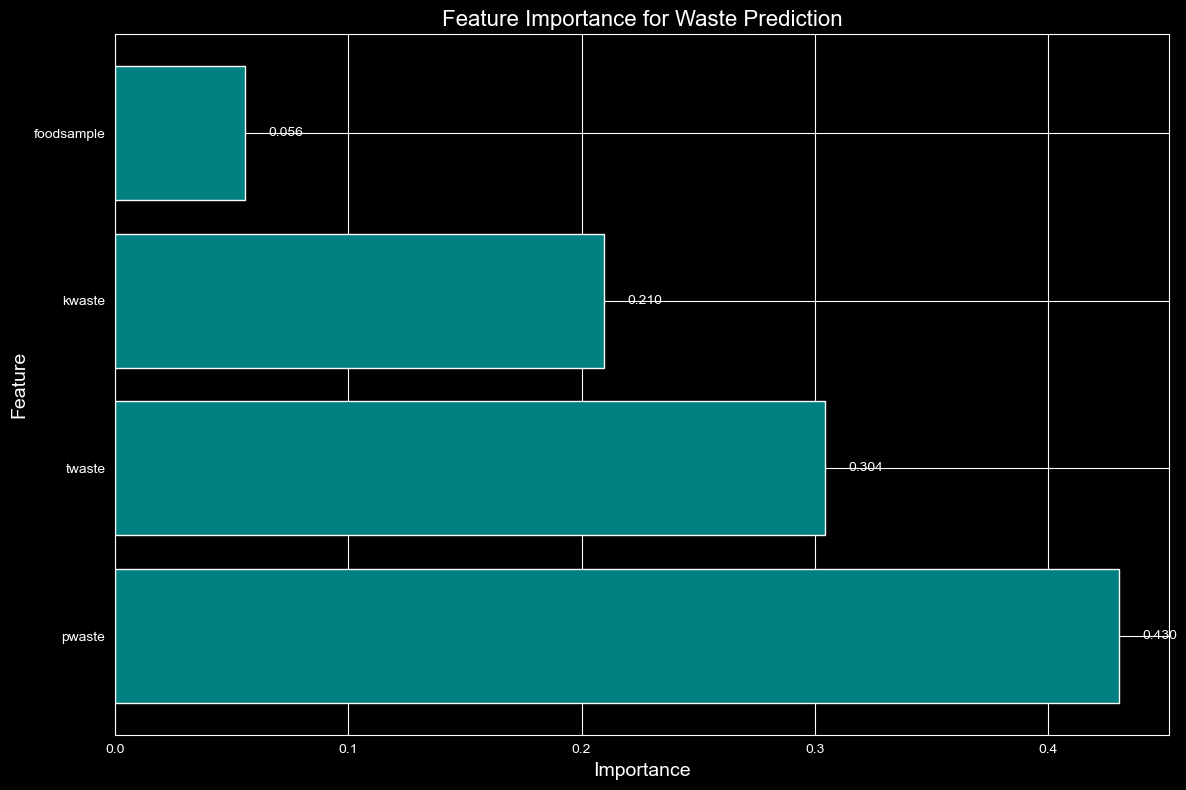

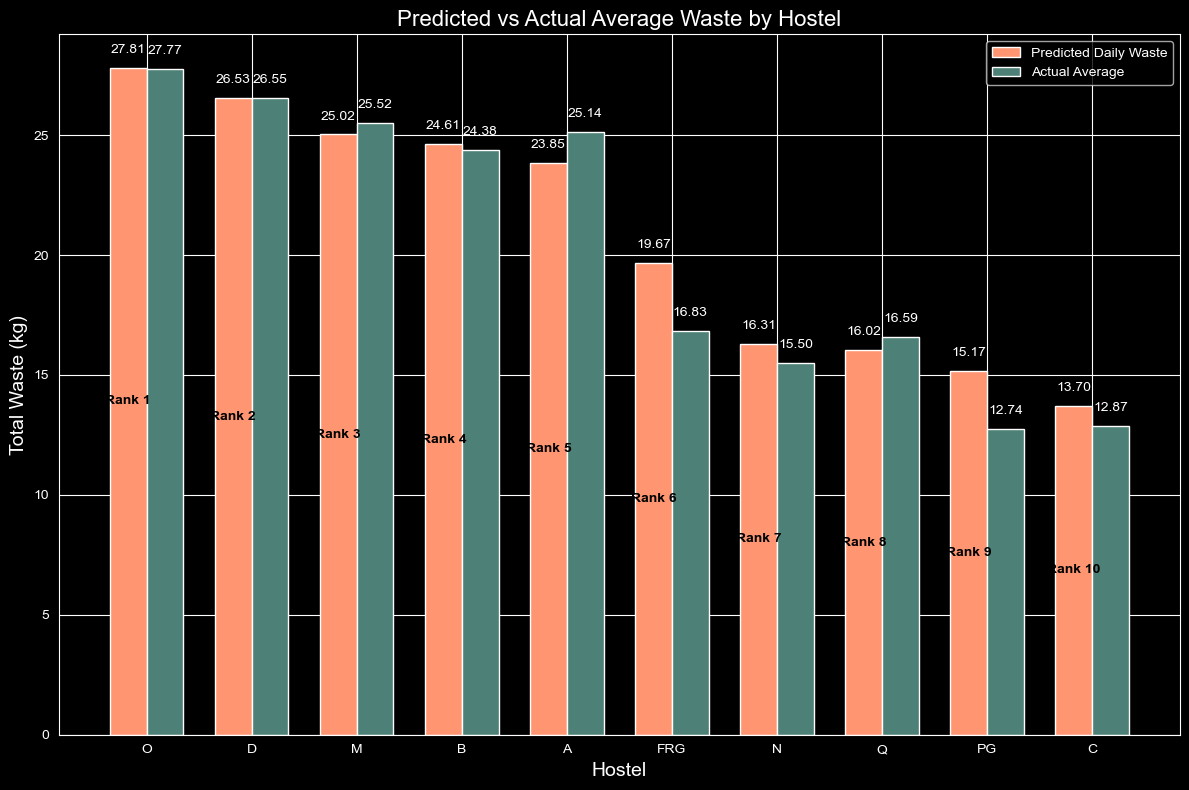

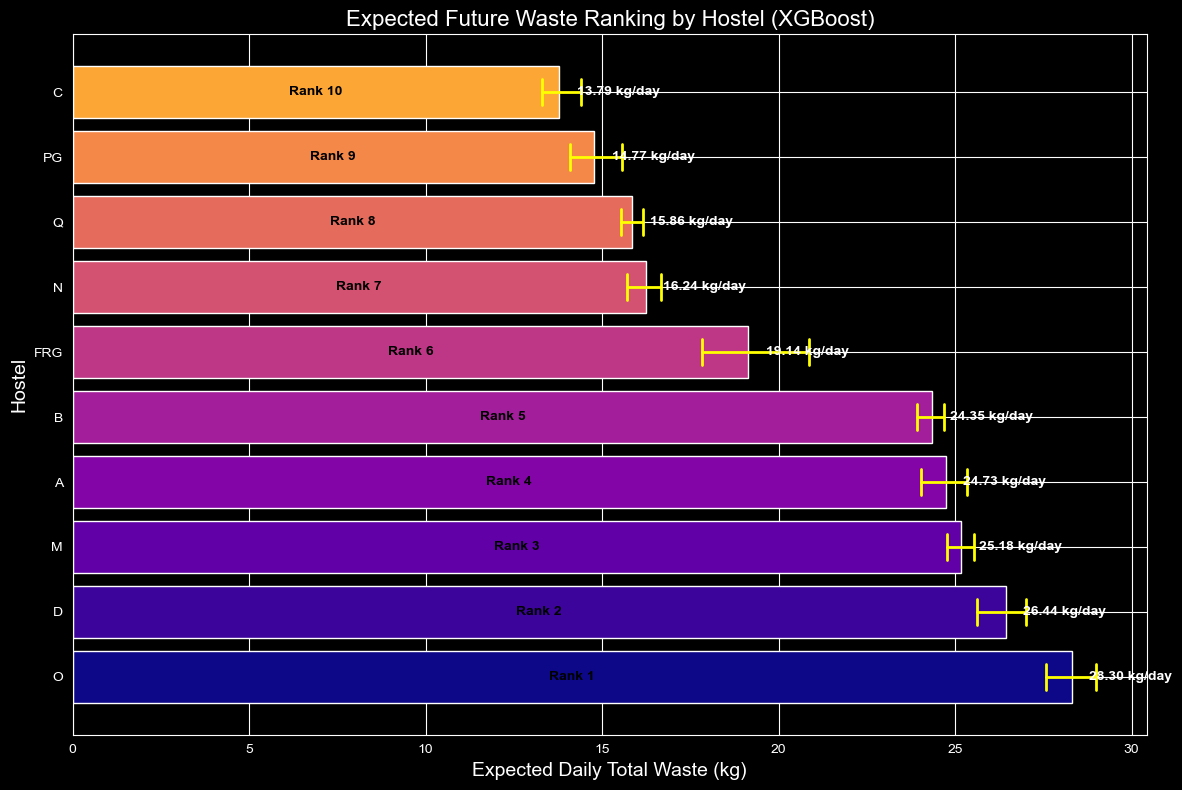


===== WASTE REDUCTION RECOMMENDATIONS =====

Hostel O - Rank 1 (Expected daily waste: 28.30 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• HIGH PLATE WASTE (56.3%): Consider reducing portion sizes
  and monitoring student food preferences
• Based on XGBoost model, focus on optimizing: pwaste

Hostel D - Rank 2 (Expected daily waste: 26.44 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• HIGH PLATE WASTE (63.0%): Consider reducing portion sizes
  and monitoring student food preferences
• Based on XGBoost model, focus on optimizing: pwaste

Hostel M - Rank 3 (Expected daily waste: 25.18 kg)
⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators
• MODERATE PLATE WASTE (47.4%): Review serving practices
• Based on XGBoost model, focus on optimizing: pwaste

Hostel A - Rank 5 (Expected daily waste: 24.73 kg)
• MODERATE PLATE WASTE (48.8%): Review serving practices
• Based on XGBoost model, focus on optimizing: pwaste

Hostel B - Ran

In [19]:
# ======================================
# XGBOOST WASTE PREDICTION MODEL
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb  # Import XGBoost

# Configure plot style
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Calculate total waste for each entry
dataset['total_waste'] = dataset['pwaste'] + dataset['twaste'] + dataset['foodsample'] + dataset['kwaste']

# ===============================
# DECODE BINARY HOSTEL COLUMNS
# ===============================

# Identify the binary hostel columns
binary_cols = ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
print(f"Using binary hostel columns: {binary_cols}")

# Create a function to decode the binary encoding to hostel IDs
def decode_hostel_id(row):
    binary_string = ''
    for col in binary_cols:
        binary_string += str(int(row[col]))
    return int(binary_string, 2)

# Apply the decoding function
dataset['decoded_hostel'] = dataset.apply(decode_hostel_id, axis=1)

# Define correct hostel names
correct_hostel_names = ["A", "B", "C", "D", "FRG", "M", "N", "O", "PG", "Q"]

# Map the decoded hostel IDs to the correct names
unique_hostel_ids = sorted(dataset['decoded_hostel'].unique())
hostel_name_map = {}

for i, hostel_id in enumerate(unique_hostel_ids):
    if i < len(correct_hostel_names):
        hostel_name_map[hostel_id] = correct_hostel_names[i]
    else:
        # If we have more unique IDs than names, use the ID as a string
        hostel_name_map[hostel_id] = f"Hostel {hostel_id}"

# Add the hostel name to the dataset
dataset['hostel_name'] = dataset['decoded_hostel'].map(hostel_name_map)

print(f"Mapped decoded hostel IDs to names: {hostel_name_map}")

# ===============================
# PART 1: HOSTEL WASTE ANALYSIS
# ===============================

# Get total waste by hostel
hostel_waste = dataset.groupby('hostel_name')['total_waste'].sum().reset_index()
hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)

# Display the ranked results
print("\nHostel Ranking by Total Waste Generation:")
print(hostel_waste)

# Visualization 1: Total Waste by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f} kg',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 2: Waste Type Breakdown by Hostel
waste_types = ['pwaste', 'twaste', 'foodsample', 'kwaste']
hostel_waste_breakdown = dataset.groupby('hostel_name')[waste_types].sum().reset_index()

plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste_breakdown))
width = 0.6
bottom = np.zeros(len(hostel_waste_breakdown))

# Create the stacked bars
colors = ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']
for i, waste_type in enumerate(waste_types):
    plt.bar(x, hostel_waste_breakdown[waste_type], width, bottom=bottom, 
           label=waste_type, color=colors[i])
    bottom += hostel_waste_breakdown[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste_breakdown['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Add average waste per meal line
avg_waste_per_meal = dataset.groupby('hostel_name')['total_waste'].mean()
hostel_order = hostel_waste_breakdown['hostel_name'].tolist()
avg_values = [avg_waste_per_meal[h] for h in hostel_order]

# Plot average line
avg_points = []
for i, avg in enumerate(avg_values):
    avg_points.append((i, avg))
    plt.text(i, avg + 0.5, f'Avg: {avg:.2f} kg/meal', ha='center', color='yellow', fontsize=10)

avg_x, avg_y = zip(*avg_points)
plt.plot(avg_x, avg_y, 'o--', color='yellow', linewidth=2, label='Avg waste/meal')

plt.tight_layout()
plt.show()

# ===============================
# PART 2: XGBOOST MODEL
# ===============================

# Identify all numeric columns first
numeric_cols = [col for col in dataset.columns if 
                dataset[col].dtype in ['int64', 'float64', 'bool']]

# Print available numeric columns for debugging
print(f"\nAll available numeric columns: {numeric_cols}")

# Now identify which ones to use as features (exclude target and identifiers)
exclude_cols = ['total_waste', 'decoded_hostel'] + binary_cols
X_cols = [col for col in numeric_cols if col not in exclude_cols]

# Print selected features
print(f"\nSelected features for prediction: {X_cols}")
print(f"Number of features: {len(X_cols)}")

# If no features were found, manually select some
if len(X_cols) == 0:
    print("WARNING: No features automatically detected. Using waste components as features.")
    X_cols = ['pwaste', 'kwaste', 'foodsample', 'twaste']
    
# Print feature data types to verify they're numeric
print("\nFeature data types:")
for col in X_cols:
    print(f"{col}: {dataset[col].dtype}")

# Create feature matrix and target vector
X = dataset[X_cols].copy()
y = dataset['total_waste'].copy()

# Print shapes to verify data
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

# Handle any missing values
if X.isnull().any().any():
    print("Handling missing values in features...")
    X = X.fillna(X.mean())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
print("\nTraining XGBoost model to predict total waste...")
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFactors influencing waste generation:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(min(10, len(feature_importance)))
bars = plt.barh(top_features['Feature'], top_features['Importance'], color='teal')

plt.title('Feature Importance for Waste Prediction', color='white', fontsize=16)
plt.xlabel('Importance', color='white', fontsize=14)
plt.ylabel('Feature', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add importance values
for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', color='white', va='center')

plt.tight_layout()
plt.show()

# ===============================
# PART 3: PREDICTED WASTE BY HOSTEL
# ===============================

# Group data by hostel name for prediction
grouped_data = dataset.groupby('hostel_name')

# Calculate average features for each hostel
hostel_features = []
for name, group in grouped_data:
    # Calculate mean of each feature for this hostel
    avg_features = {col: group[col].mean() for col in X_cols}
    avg_features['hostel_name'] = name
    avg_features['actual_avg_waste'] = group['total_waste'].mean()
    hostel_features.append(avg_features)

# Convert to DataFrame
hostel_df = pd.DataFrame(hostel_features)

# Scale the features for prediction
pred_features = hostel_df[X_cols]
scaled_features = scaler.transform(pred_features)

# Predict waste for each hostel
hostel_df['predicted_waste'] = xgb_model.predict(scaled_features)

# Sort by predicted waste
hostel_df = hostel_df.sort_values('predicted_waste', ascending=False)

# Visualization 3: Predicted vs Actual Waste
plt.figure(figsize=(12, 8))

# Create a comparison chart
x = np.arange(len(hostel_df))
width = 0.35

# Plot predicted and actual average
pred_bars = plt.bar(x - width/2, hostel_df['predicted_waste'], width, label='Predicted Daily Waste', color='#FF9671')
actual_bars = plt.bar(x + width/2, hostel_df['actual_avg_waste'], width, label='Actual Average', color='#4D8076')

plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.title('Predicted vs Actual Average Waste by Hostel', color='white', fontsize=16)
plt.xticks(x, hostel_df['hostel_name'], color='white')
plt.yticks(color='white')

# Add ranking numbers and values
for i, (pred, actual) in enumerate(zip(hostel_df['predicted_waste'], hostel_df['actual_avg_waste'])):
    plt.text(i - width/2, pred + 0.5, f'{pred:.2f}', ha='center', va='bottom', color='white')
    plt.text(i + width/2, actual + 0.5, f'{actual:.2f}', ha='center', va='bottom', color='white')
    plt.text(i - width/2, pred/2, f'Rank {i+1}', ha='center', va='center', color='black', fontweight='bold')

# Set up legend with white text
legend = plt.legend()
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.show()

# Create confidence intervals using model predictions with different parameters
hostel_predictions = []

# For each hostel, create multiple predictions by varying hyperparameters
for i, row in hostel_df.iterrows():
    hostel_name = row['hostel_name']
    features = pred_features.iloc[i:i+1]
    scaled_feat = scaler.transform(features)
    
    # Generate predictions with different hyperparameter configurations
    predictions = []
    learning_rates = [0.05, 0.1, 0.15, 0.2]
    max_depths = [3, 4, 5, 6]
    
    for lr in learning_rates:
        for depth in max_depths:
            model = xgb.XGBRegressor(
                objective='reg:squarederror',
                n_estimators=100,
                learning_rate=lr,
                max_depth=depth,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
            model.fit(X_train_scaled, y_train)
            pred = model.predict(scaled_feat)[0]
            predictions.append(pred)
    
    # Calculate statistics
    mean_pred = np.mean(predictions)
    lower_bound = np.percentile(predictions, 5)
    upper_bound = np.percentile(predictions, 95)
    
    hostel_predictions.append({
        'Hostel': hostel_name,
        'Predicted_Waste': mean_pred,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Actual_Average': row['actual_avg_waste']
    })

# Convert to DataFrame and sort
future_df = pd.DataFrame(hostel_predictions).sort_values('Predicted_Waste', ascending=False)

# Final visualization: Future waste prediction with confidence intervals
plt.figure(figsize=(12, 8))

# Plot the predictions with confidence intervals
bars = plt.barh(future_df['Hostel'], future_df['Predicted_Waste'], 
               color=plt.cm.plasma(np.linspace(0, 0.8, len(future_df))))

# Add error bars for confidence intervals
for i, (lower, upper) in enumerate(zip(future_df['Lower_Bound'], future_df['Upper_Bound'])):
    plt.plot([lower, upper], [i, i], color='yellow', linewidth=2)
    plt.plot([lower, lower], [i-0.2, i+0.2], color='yellow', linewidth=2)
    plt.plot([upper, upper], [i-0.2, i+0.2], color='yellow', linewidth=2)

# Add value labels and ranking
for i, (bar, waste) in enumerate(zip(bars, future_df['Predicted_Waste'])):
    width = bar.get_width()
    plt.text(width + 0.5, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Expected Future Waste Ranking by Hostel (XGBoost)', color='white', fontsize=16)
plt.xlabel('Expected Daily Total Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# ===============================
# PART 4: WASTE REDUCTION RECOMMENDATIONS
# ===============================

# Calculate waste composition percentages for each hostel
waste_percentages = {}
for name, group in dataset.groupby('hostel_name'):
    total = group[waste_types].sum().sum()
    percentages = {}
    for waste_type in waste_types:
        percentages[waste_type] = 100 * group[waste_type].sum() / total if total > 0 else 0
    waste_percentages[name] = percentages

print("\n===== WASTE REDUCTION RECOMMENDATIONS =====")

for i, row in future_df.iterrows():
    hostel = row['Hostel']
    pred_waste = row['Predicted_Waste']
    rank = i + 1
    
    # Get waste percentages
    if hostel in waste_percentages:
        percentages = waste_percentages[hostel]
        pwaste_pct = percentages['pwaste']
        kwaste_pct = percentages['kwaste']
    else:
        pwaste_pct = 0
        kwaste_pct = 0
    
    print(f"\nHostel {hostel} - Rank {rank} (Expected daily waste: {pred_waste:.2f} kg)")
    
    if rank <= 3:
        print("⚠️ HIGH PRIORITY: This hostel is among the top 3 waste generators")
    
    if pwaste_pct > 50:
        print(f"• HIGH PLATE WASTE ({pwaste_pct:.1f}%): Consider reducing portion sizes")
        print("  and monitoring student food preferences")
    elif pwaste_pct > 30:
        print(f"• MODERATE PLATE WASTE ({pwaste_pct:.1f}%): Review serving practices")
    
    if kwaste_pct > 40:
        print(f"• HIGH KITCHEN WASTE ({kwaste_pct:.1f}%): Improve food preparation methods")
        print("  and inventory management to reduce spoilage")
    
    # Add model-based recommendations using feature importance
    if not feature_importance.empty:
        top_feature = feature_importance['Feature'].iloc[0]
        print(f"• Based on XGBoost model, focus on optimizing: {top_feature}")

## now per capita xg boost

Loaded hostel capacity data:
  hostel  capacity
0      A       928
1      B       724
2      C       387
3      D       928
4    FRG       480
5      M      1148
6      N       500
7      O       928
8     PG       404
9      Q       928

Using binary hostel columns: ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
Mapped decoded hostel IDs to names: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'FRG', 5: 'M', 6: 'N', 7: 'O', 8: 'PG', 9: 'Q'}

Hostel Ranking by Total Waste Generation:
  hostel_name total_waste  capacity per_capita_waste
0           O      416.51       928         0.448825
1           D      398.32       928         0.429224
2           M   382.82031      1148         0.333467
3           A      377.11       928         0.406369
4           B      365.71       724         0.505124
5         FRG      252.51       480         0.526062
6           Q       248.9       928         0.268211
7           N    232.5505       500         0.465101
8           C  

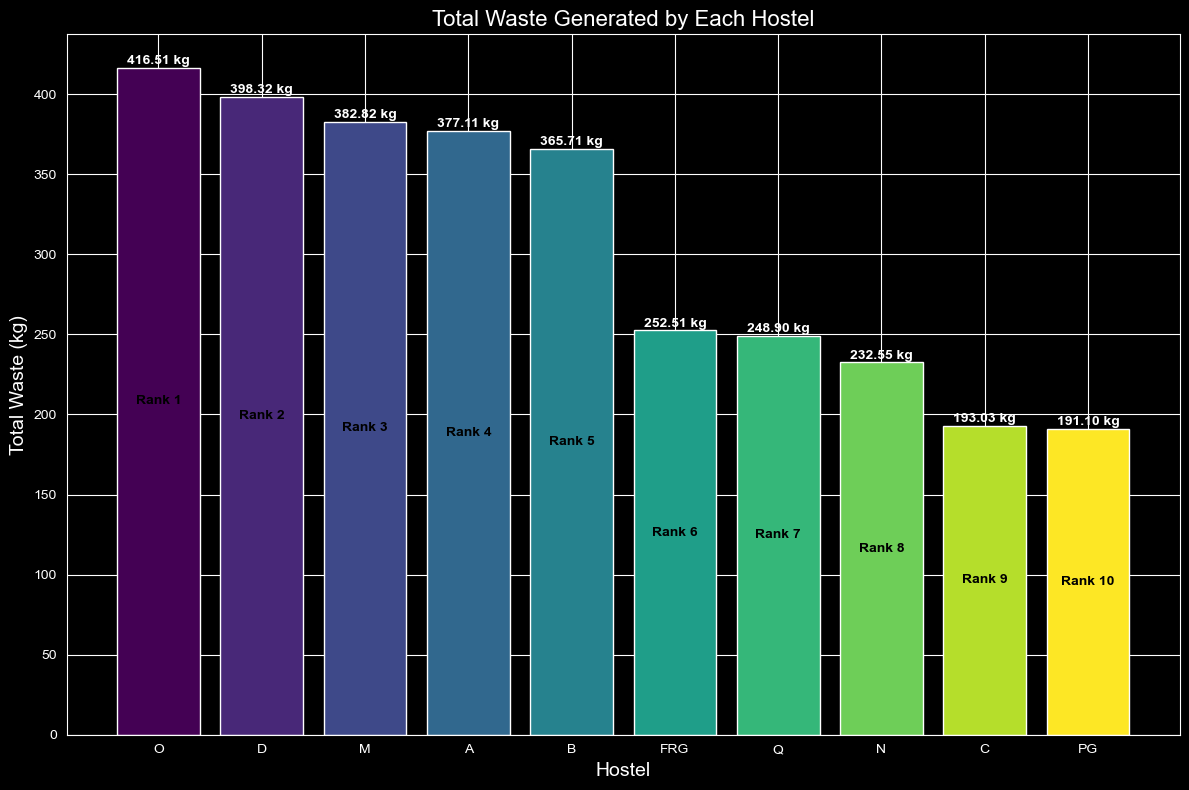

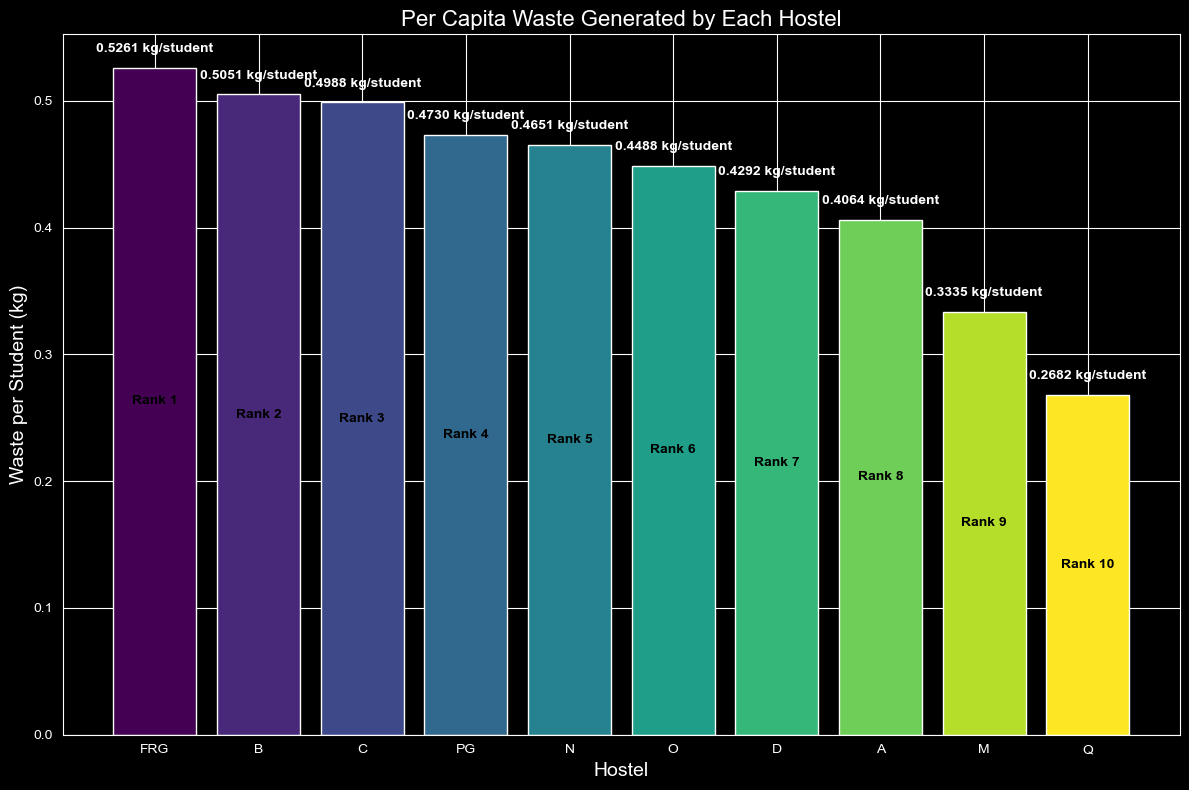

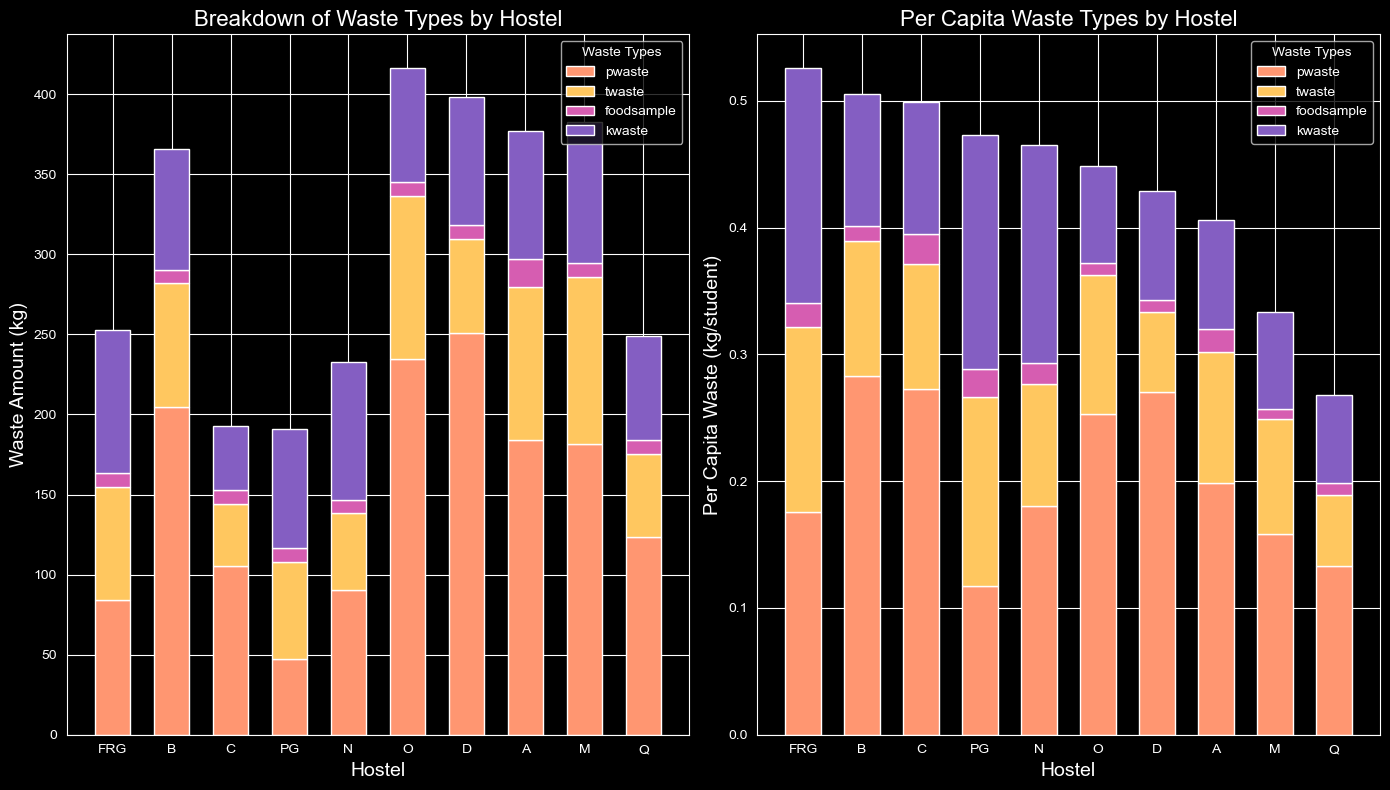


All available numeric columns: ['decoded_hostel', 'capacity']

Selected features for prediction: []
Number of features: 0

X shape: (150, 4), y shape: (150,)
Train set: (120, 4), Test set: (30, 4)

Training XGBoost model to predict per capita waste...
Per Capita Model Performance:
Mean Squared Error: 0.000083
Mean Absolute Error: 0.006028
R² Score: 0.28

Factors influencing per capita waste generation:
      Feature  Importance
1      kwaste    0.380519
0      pwaste    0.254789
3      twaste    0.227012
2  foodsample    0.137680


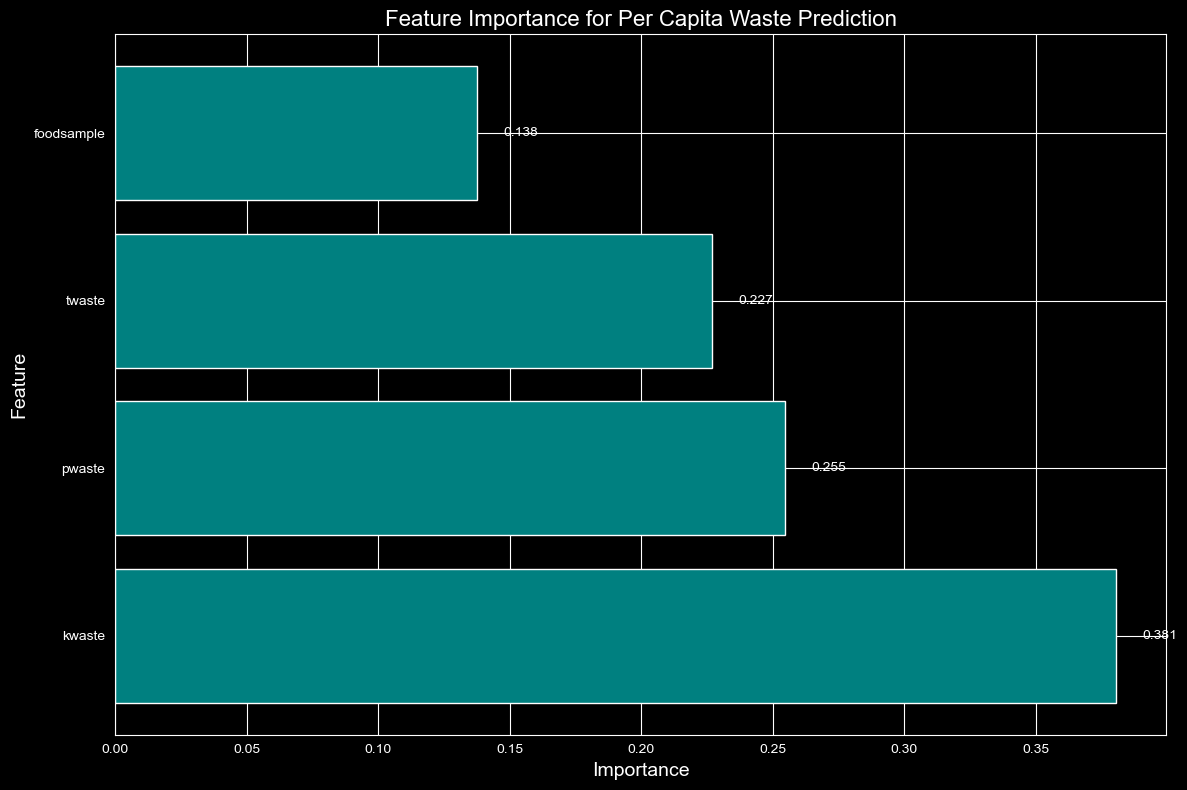

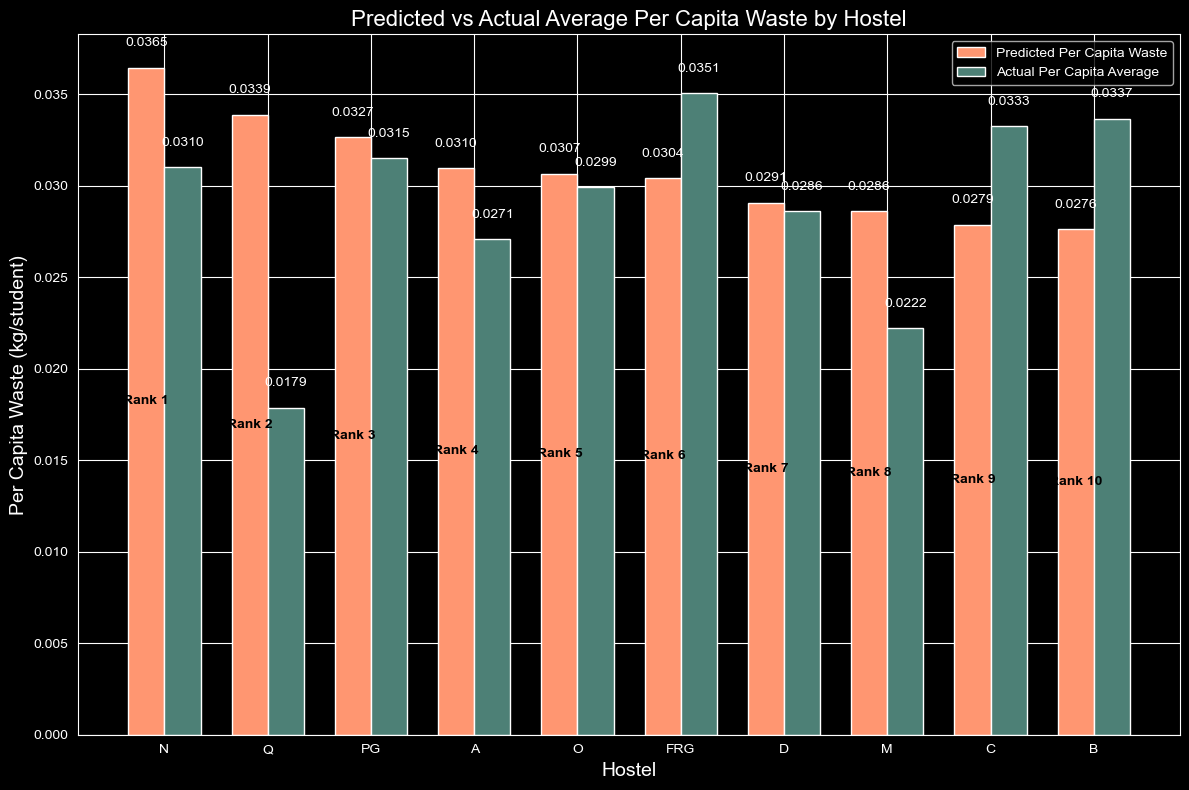

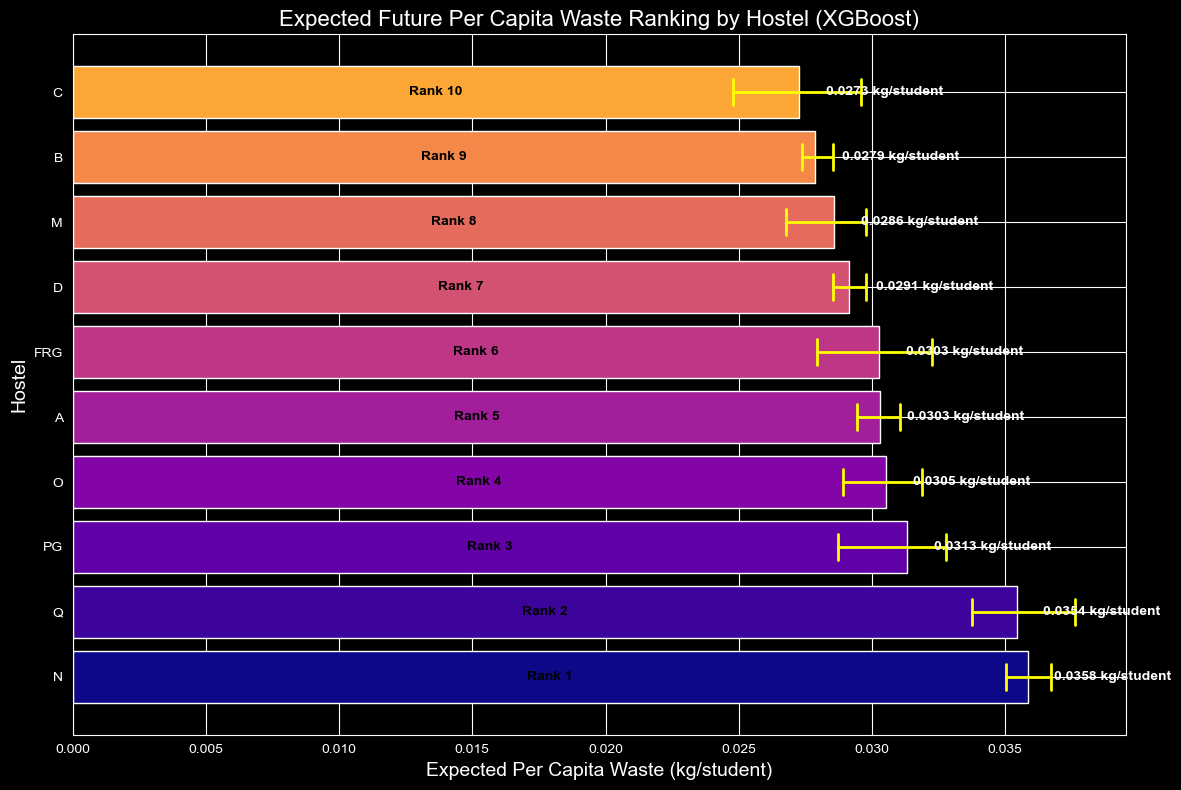

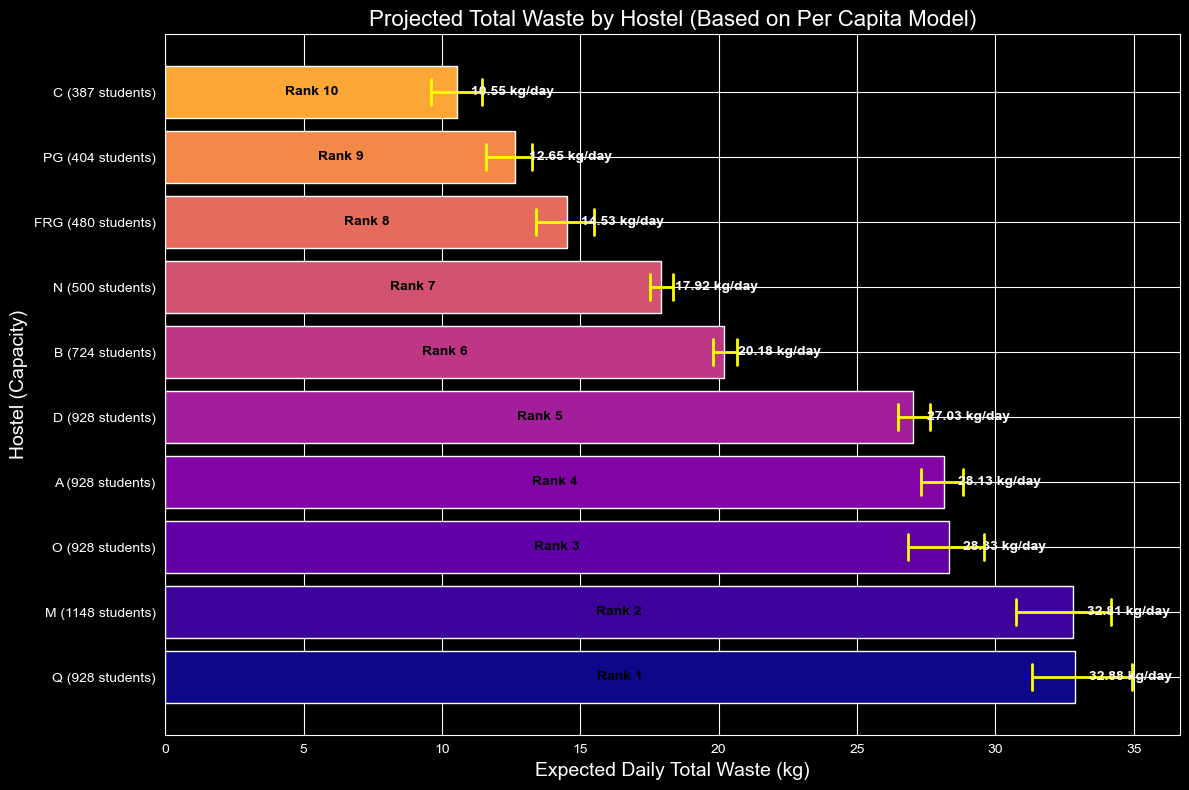


===== WASTE REDUCTION RECOMMENDATIONS BASED ON PER CAPITA ANALYSIS =====

Hostel N - Per Capita Rank 1 (Students: 500)
Expected waste: 0.0358 kg/student, 17.92 kg total/day
⚠️ HIGH PRIORITY: This hostel has among the highest per capita waste generation
• MODERATE PLATE WASTE (38.8%): Review serving practices
• Based on XGBoost per capita model, focus on optimizing: kwaste

Hostel Q - Per Capita Rank 2 (Students: 928)
Expected waste: 0.0354 kg/student, 32.88 kg total/day
⚠️ HIGH PRIORITY: This hostel has among the highest per capita waste generation
• MODERATE PLATE WASTE (49.5%): Review serving practices
• Based on XGBoost per capita model, focus on optimizing: kwaste

Hostel PG - Per Capita Rank 3 (Students: 404)
Expected waste: 0.0313 kg/student, 12.65 kg total/day
⚠️ HIGH PRIORITY: This hostel has among the highest per capita waste generation
• Based on XGBoost per capita model, focus on optimizing: kwaste

Hostel O - Per Capita Rank 5 (Students: 928)
Expected waste: 0.0305 kg/stud

In [21]:
# ======================================
# HOSTEL PER CAPITA WASTE ANALYSIS WITH XGBOOST
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Configure plot style
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# Step 1: Load the hostel capacity data
capacity_file = 'capacity.csv'
capacity_data = pd.read_csv(capacity_file)
print("Loaded hostel capacity data:")
print(capacity_data)

# Calculate total waste for each entry
dataset['total_waste'] = dataset['pwaste'] + dataset['twaste'] + dataset['foodsample'] + dataset['kwaste']

# ===============================
# DECODE BINARY HOSTEL COLUMNS
# ===============================

# Identify the binary hostel columns
binary_cols = ['hostel_binary_0', 'hostel_binary_1', 'hostel_binary_2', 'hostel_binary_3']
print(f"\nUsing binary hostel columns: {binary_cols}")

# Create a function to decode the binary encoding to hostel IDs
def decode_hostel_id(row):
    binary_string = ''
    for col in binary_cols:
        binary_string += str(int(row[col]))
    return int(binary_string, 2)

# Apply the decoding function
dataset['decoded_hostel'] = dataset.apply(decode_hostel_id, axis=1)

# Define correct hostel names
correct_hostel_names = ["A", "B", "C", "D", "FRG", "M", "N", "O", "PG", "Q"]

# Map the decoded hostel IDs to the correct names
unique_hostel_ids = sorted(dataset['decoded_hostel'].unique())
hostel_name_map = {}

for i, hostel_id in enumerate(unique_hostel_ids):
    if i < len(correct_hostel_names):
        hostel_name_map[hostel_id] = correct_hostel_names[i]
    else:
        # If we have more unique IDs than names, use the ID as a string
        hostel_name_map[hostel_id] = f"Hostel {hostel_id}"

# Add the hostel name to the dataset
dataset['hostel_name'] = dataset['decoded_hostel'].map(hostel_name_map)

print(f"Mapped decoded hostel IDs to names: {hostel_name_map}")

# ===============================
# PART 1: HOSTEL TOTAL WASTE ANALYSIS
# ===============================

# Get total waste by hostel
hostel_waste = dataset.groupby('hostel_name')['total_waste'].sum().reset_index()
hostel_waste = hostel_waste.sort_values('total_waste', ascending=False)

# Merge with capacity data
hostel_waste = pd.merge(hostel_waste, capacity_data, left_on='hostel_name', right_on='hostel', how='left')
hostel_waste.drop('hostel', axis=1, inplace=True, errors='ignore')  # Remove duplicate hostel column

# Calculate per capita waste
hostel_waste['per_capita_waste'] = hostel_waste['total_waste'] / hostel_waste['capacity']
hostel_waste_by_capita = hostel_waste.sort_values('per_capita_waste', ascending=False)

# Display the results
print("\nHostel Ranking by Total Waste Generation:")
print(hostel_waste)

print("\nHostel Ranking by Per Capita Waste Generation:")
print(hostel_waste_by_capita)

# Visualization 1: Total Waste by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(hostel_waste['hostel_name'], hostel_waste['total_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f} kg',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste['total_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Total Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Waste (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 2: Per Capita Waste by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(hostel_waste_by_capita['hostel_name'], hostel_waste_by_capita['per_capita_waste'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(hostel_waste_by_capita))))

# Add waste amount labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f} kg/student',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, waste) in enumerate(zip(bars, hostel_waste_by_capita['per_capita_waste'])):
    plt.text(bar.get_x() + bar.get_width()/2., waste/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Per Capita Waste Generated by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste per Student (kg)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 3: Waste Type Breakdown by Hostel
waste_types = ['pwaste', 'twaste', 'foodsample', 'kwaste']
hostel_waste_breakdown = dataset.groupby('hostel_name')[waste_types].sum().reset_index()

# Merge with capacity data
hostel_waste_breakdown = pd.merge(hostel_waste_breakdown, capacity_data, left_on='hostel_name', right_on='hostel', how='left')
hostel_waste_breakdown.drop('hostel', axis=1, inplace=True, errors='ignore')

# Calculate per capita values for each waste type
for waste_type in waste_types:
    hostel_waste_breakdown[f'{waste_type}_per_capita'] = hostel_waste_breakdown[waste_type] / hostel_waste_breakdown['capacity']

# Sort by total per capita waste
hostel_waste_breakdown['total_per_capita'] = hostel_waste_breakdown[waste_types].sum(axis=1) / hostel_waste_breakdown['capacity']
hostel_waste_breakdown = hostel_waste_breakdown.sort_values('total_per_capita', ascending=False)

plt.figure(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(hostel_waste_breakdown))
width = 0.6
bottom = np.zeros(len(hostel_waste_breakdown))

# Create the stacked bars for total waste by type
plt.subplot(1, 2, 1)
bottom = np.zeros(len(hostel_waste_breakdown))
colors = ['#FF9671', '#FFC75F', '#D65DB1', '#845EC2']
for i, waste_type in enumerate(waste_types):
    plt.bar(x, hostel_waste_breakdown[waste_type], width, bottom=bottom, 
           label=waste_type, color=colors[i])
    bottom += hostel_waste_breakdown[waste_type]

# Customize the chart
plt.title('Breakdown of Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Waste Amount (kg)', color='white', fontsize=14)
plt.xticks(x, hostel_waste_breakdown['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

# Create the stacked bars for per capita waste
plt.subplot(1, 2, 2)
bottom = np.zeros(len(hostel_waste_breakdown))

per_capita_columns = [f'{waste_type}_per_capita' for waste_type in waste_types]
for i, waste_type in enumerate(per_capita_columns):
    plt.bar(x, hostel_waste_breakdown[waste_type], width, bottom=bottom, 
           label=waste_types[i], color=colors[i])
    bottom += hostel_waste_breakdown[waste_type]

# Customize the chart
plt.title('Per Capita Waste Types by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Waste (kg/student)', color='white', fontsize=14)
plt.xticks(x, hostel_waste_breakdown['hostel_name'], color='white')
plt.yticks(color='white')

# Add a legend with white text
legend = plt.legend(title='Waste Types', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

plt.tight_layout()
plt.show()

# ===============================
# PART 2: ADD CAPACITY DATA TO DATASET
# ===============================

# Add capacity to the main dataset
dataset = pd.merge(dataset, capacity_data, left_on='hostel_name', right_on='hostel', how='left')
dataset.drop('hostel', axis=1, inplace=True, errors='ignore')  # Remove duplicate hostel column

# Calculate per capita waste for each record
dataset['per_capita_waste'] = dataset['total_waste'] / dataset['capacity']

# ===============================
# PART 3: XGBOOST MODEL FOR PER CAPITA WASTE
# ===============================

# Identify all numeric columns first
numeric_cols = [col for col in dataset.columns if 
                dataset[col].dtype in ['int64', 'float64', 'bool']]

# Print available numeric columns for debugging
print(f"\nAll available numeric columns: {numeric_cols}")

# Now identify which ones to use as features (exclude target and identifiers)
exclude_cols = ['total_waste', 'decoded_hostel', 'capacity', 'per_capita_waste'] + binary_cols
X_cols = [col for col in numeric_cols if col not in exclude_cols]

# Print selected features
print(f"\nSelected features for prediction: {X_cols}")
print(f"Number of features: {len(X_cols)}")

# If no features were found, manually select some
if len(X_cols) == 0:
    print("WARNING: No features automatically detected. Using waste components as features.")
    X_cols = ['pwaste', 'kwaste', 'foodsample', 'twaste']
    
# Create feature matrix and target vector - this time for per capita waste
X = dataset[X_cols].copy()
y = dataset['per_capita_waste'].copy()

# Print shapes to verify data
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

# Handle any missing values
if X.isnull().any().any():
    print("Handling missing values in features...")
    X = X.fillna(X.mean())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model for per capita waste
print("\nTraining XGBoost model to predict per capita waste...")
xgb_per_capita_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_per_capita_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = xgb_per_capita_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Per Capita Model Performance:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")
print(f"R² Score: {r2:.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_cols,
    'Importance': xgb_per_capita_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFactors influencing per capita waste generation:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(min(10, len(feature_importance)))
bars = plt.barh(top_features['Feature'], top_features['Importance'], color='teal')

plt.title('Feature Importance for Per Capita Waste Prediction', color='white', fontsize=16)
plt.xlabel('Importance', color='white', fontsize=14)
plt.ylabel('Feature', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add importance values
for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', color='white', va='center')

plt.tight_layout()
plt.show()

# ===============================
# PART 4: PREDICTED PER CAPITA WASTE BY HOSTEL
# ===============================

# Group data by hostel name for prediction
grouped_data = dataset.groupby('hostel_name')

# Calculate average features for each hostel
hostel_features = []
for name, group in grouped_data:
    # Calculate mean of each feature for this hostel
    avg_features = {col: group[col].mean() for col in X_cols}
    avg_features['hostel_name'] = name
    avg_features['capacity'] = group['capacity'].iloc[0]
    avg_features['actual_avg_per_capita'] = group['per_capita_waste'].mean()
    hostel_features.append(avg_features)

# Convert to DataFrame
hostel_df = pd.DataFrame(hostel_features)

# Scale the features for prediction
pred_features = hostel_df[X_cols]
scaled_features = scaler.transform(pred_features)

# Predict waste for each hostel
hostel_df['predicted_per_capita'] = xgb_per_capita_model.predict(scaled_features)
# Calculate total predicted waste (per capita * capacity)
hostel_df['predicted_total_waste'] = hostel_df['predicted_per_capita'] * hostel_df['capacity']

# Sort by predicted per capita waste
hostel_df = hostel_df.sort_values('predicted_per_capita', ascending=False)

# Visualization: Predicted vs Actual Per Capita Waste
plt.figure(figsize=(12, 8))

# Create a comparison chart
x = np.arange(len(hostel_df))
width = 0.35

# Plot predicted and actual average
pred_bars = plt.bar(x - width/2, hostel_df['predicted_per_capita'], width, 
                   label='Predicted Per Capita Waste', color='#FF9671')
actual_bars = plt.bar(x + width/2, hostel_df['actual_avg_per_capita'], width, 
                     label='Actual Per Capita Average', color='#4D8076')

plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Waste (kg/student)', color='white', fontsize=14)
plt.title('Predicted vs Actual Average Per Capita Waste by Hostel', color='white', fontsize=16)
plt.xticks(x, hostel_df['hostel_name'], color='white')
plt.yticks(color='white')

# Add ranking numbers and values
for i, (pred, actual) in enumerate(zip(hostel_df['predicted_per_capita'], hostel_df['actual_avg_per_capita'])):
    plt.text(i - width/2, pred + 0.001, f'{pred:.4f}', ha='center', va='bottom', color='white')
    plt.text(i + width/2, actual + 0.001, f'{actual:.4f}', ha='center', va='bottom', color='white')
    plt.text(i - width/2, pred/2, f'Rank {i+1}', ha='center', va='center', color='black', fontweight='bold')

# Set up legend with white text
legend = plt.legend()
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.show()

# Create confidence intervals for per capita predictions
hostel_predictions = []

# For each hostel, create multiple predictions by varying hyperparameters
for i, row in hostel_df.iterrows():
    hostel_name = row['hostel_name']
    features = pred_features.iloc[i:i+1]
    scaled_feat = scaler.transform(features)
    capacity = row['capacity']
    
    # Generate predictions with different hyperparameter configurations
    predictions = []
    learning_rates = [0.05, 0.1, 0.15, 0.2]
    max_depths = [3, 4, 5, 6]
    
    for lr in learning_rates:
        for depth in max_depths:
            model = xgb.XGBRegressor(
                objective='reg:squarederror',
                n_estimators=100,
                learning_rate=lr,
                max_depth=depth,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
            model.fit(X_train_scaled, y_train)
            pred = model.predict(scaled_feat)[0]
            predictions.append(pred)
    
    # Calculate statistics
    mean_pred = np.mean(predictions)
    lower_bound = np.percentile(predictions, 5)
    upper_bound = np.percentile(predictions, 95)
    
    # Calculate total waste from per-capita predictions
    total_waste_pred = mean_pred * capacity
    total_waste_lower = lower_bound * capacity
    total_waste_upper = upper_bound * capacity
    
    hostel_predictions.append({
        'Hostel': hostel_name,
        'Capacity': capacity,
        'Predicted_Per_Capita': mean_pred,
        'Lower_Bound_Per_Capita': lower_bound,
        'Upper_Bound_Per_Capita': upper_bound,
        'Predicted_Total_Waste': total_waste_pred,
        'Lower_Bound_Total': total_waste_lower, 
        'Upper_Bound_Total': total_waste_upper,
        'Actual_Average_Per_Capita': row['actual_avg_per_capita']
    })

# Convert to DataFrame and sort by per capita and total waste
future_df = pd.DataFrame(hostel_predictions)
future_per_capita_df = future_df.sort_values('Predicted_Per_Capita', ascending=False)
future_total_df = future_df.sort_values('Predicted_Total_Waste', ascending=False)

# Final visualization: Future per capita waste prediction with confidence intervals
plt.figure(figsize=(12, 8))

# Plot the per capita predictions with confidence intervals
bars = plt.barh(future_per_capita_df['Hostel'], future_per_capita_df['Predicted_Per_Capita'], 
               color=plt.cm.plasma(np.linspace(0, 0.8, len(future_per_capita_df))))

# Add error bars for confidence intervals
for i, (lower, upper) in enumerate(zip(future_per_capita_df['Lower_Bound_Per_Capita'], 
                                      future_per_capita_df['Upper_Bound_Per_Capita'])):
    plt.plot([lower, upper], [i, i], color='yellow', linewidth=2)
    plt.plot([lower, lower], [i-0.2, i+0.2], color='yellow', linewidth=2)
    plt.plot([upper, upper], [i-0.2, i+0.2], color='yellow', linewidth=2)

# Add value labels and ranking
for i, (bar, waste) in enumerate(zip(bars, future_per_capita_df['Predicted_Per_Capita'])):
    width = bar.get_width()
    plt.text(width + 0.001, i, f'{width:.4f} kg/student', 
            ha='left', va='center', color='white', fontweight='bold')
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Expected Future Per Capita Waste Ranking by Hostel (XGBoost)', color='white', fontsize=16)
plt.xlabel('Expected Per Capita Waste (kg/student)', color='white', fontsize=14)
plt.ylabel('Hostel', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Final visualization: Projected total waste based on per capita predictions
plt.figure(figsize=(12, 8))

# Plot the total waste predictions with confidence intervals
bars = plt.barh(future_total_df['Hostel'], future_total_df['Predicted_Total_Waste'], 
               color=plt.cm.plasma(np.linspace(0, 0.8, len(future_total_df))))

# Add error bars for confidence intervals
for i, (lower, upper) in enumerate(zip(future_total_df['Lower_Bound_Total'], 
                                      future_total_df['Upper_Bound_Total'])):
    plt.plot([lower, upper], [i, i], color='yellow', linewidth=2)
    plt.plot([lower, lower], [i-0.2, i+0.2], color='yellow', linewidth=2)
    plt.plot([upper, upper], [i-0.2, i+0.2], color='yellow', linewidth=2)

# Add capacity numbers in parentheses after hostel names
plt.yticks(range(len(future_total_df)), 
          [f"{h} ({c} students)" for h, c in zip(future_total_df['Hostel'], future_total_df['Capacity'])],
          color='white')

# Add value labels and ranking
for i, (bar, waste) in enumerate(zip(bars, future_total_df['Predicted_Total_Waste'])):
    width = bar.get_width()
    plt.text(width + 0.5, i, f'{width:.2f} kg/day', 
            ha='left', va='center', color='white', fontweight='bold')
    plt.text(width/2, i, f'Rank {i+1}', 
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Projected Total Waste by Hostel (Based on Per Capita Model)', color='white', fontsize=16)
plt.xlabel('Expected Daily Total Waste (kg)', color='white', fontsize=14)
plt.ylabel('Hostel (Capacity)', color='white', fontsize=14)
plt.xticks(color='white')
plt.tight_layout()
plt.show()

# ===============================
# PART 5: WASTE REDUCTION RECOMMENDATIONS
# ===============================

# Calculate waste composition percentages for each hostel
waste_percentages = {}
for name, group in dataset.groupby('hostel_name'):
    total = group[waste_types].sum().sum()
    percentages = {}
    for waste_type in waste_types:
        percentages[waste_type] = 100 * group[waste_type].sum() / total if total > 0 else 0
    waste_percentages[name] = percentages

print("\n===== WASTE REDUCTION RECOMMENDATIONS BASED ON PER CAPITA ANALYSIS =====")

for i, row in future_per_capita_df.iterrows():
    hostel = row['Hostel']
    pred_waste_per_capita = row['Predicted_Per_Capita']
    pred_total_waste = row['Predicted_Total_Waste']
    capacity = row['Capacity']
    rank = i + 1
    
    # Get waste percentages
    if hostel in waste_percentages:
        percentages = waste_percentages[hostel]
        pwaste_pct = percentages['pwaste']
        kwaste_pct = percentages['kwaste']
    else:
        pwaste_pct = 0
        kwaste_pct = 0
    
    print(f"\nHostel {hostel} - Per Capita Rank {rank} (Students: {capacity})")
    print(f"Expected waste: {pred_waste_per_capita:.4f} kg/student, {pred_total_waste:.2f} kg total/day")
    
    if rank <= 3:
        print("⚠️ HIGH PRIORITY: This hostel has among the highest per capita waste generation")
    
    if pwaste_pct > 50:
        print(f"• HIGH PLATE WASTE ({pwaste_pct:.1f}%): Consider reducing portion sizes")
        print("  and monitoring student food preferences")
    elif pwaste_pct > 30:
        print(f"• MODERATE PLATE WASTE ({pwaste_pct:.1f}%): Review serving practices")
    
    if kwaste_pct > 40:
        print(f"• HIGH KITCHEN WASTE ({kwaste_pct:.1f}%): Improve food preparation methods")
        print("  and inventory management to reduce spoilage")
    
    # Add model-based recommendations using feature importance
    if not feature_importance.empty:
        top_feature = feature_importance['Feature'].iloc[0]
        print(f"• Based on XGBoost per capita model, focus on optimizing: {top_feature}")

In [23]:
import joblib

# Save the one-hot encoder transformer
joblib.dump(transformer, 'transformer.joblib')

# Save your trained XGBoost model
joblib.dump(xgb_model, 'waste_model.joblib')

# Save column names for reference
joblib.dump(new_column_names, 'column_names.joblib')

['column_names.joblib']

In [24]:
# now water and electricity


Loading electricity data...
Loaded 110 electricity records
Loading water data...
Loaded 110 water records

Analyzing electricity consumption patterns...


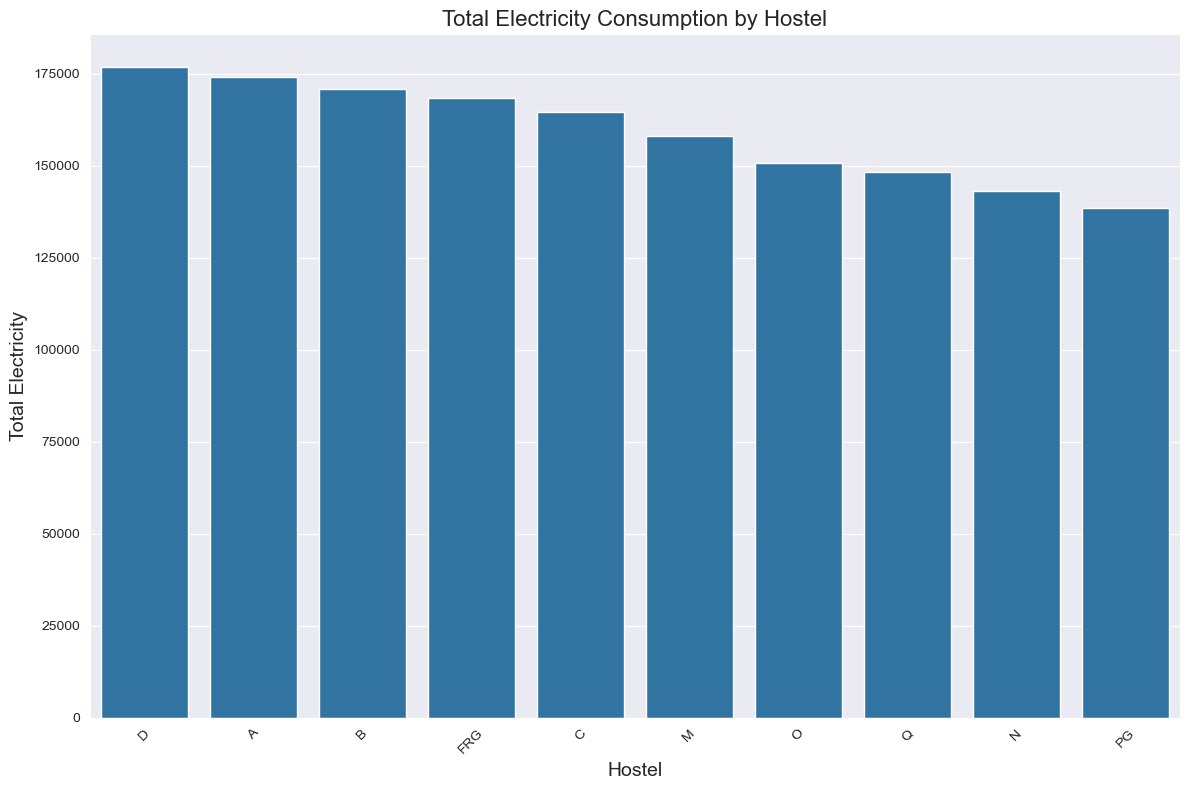

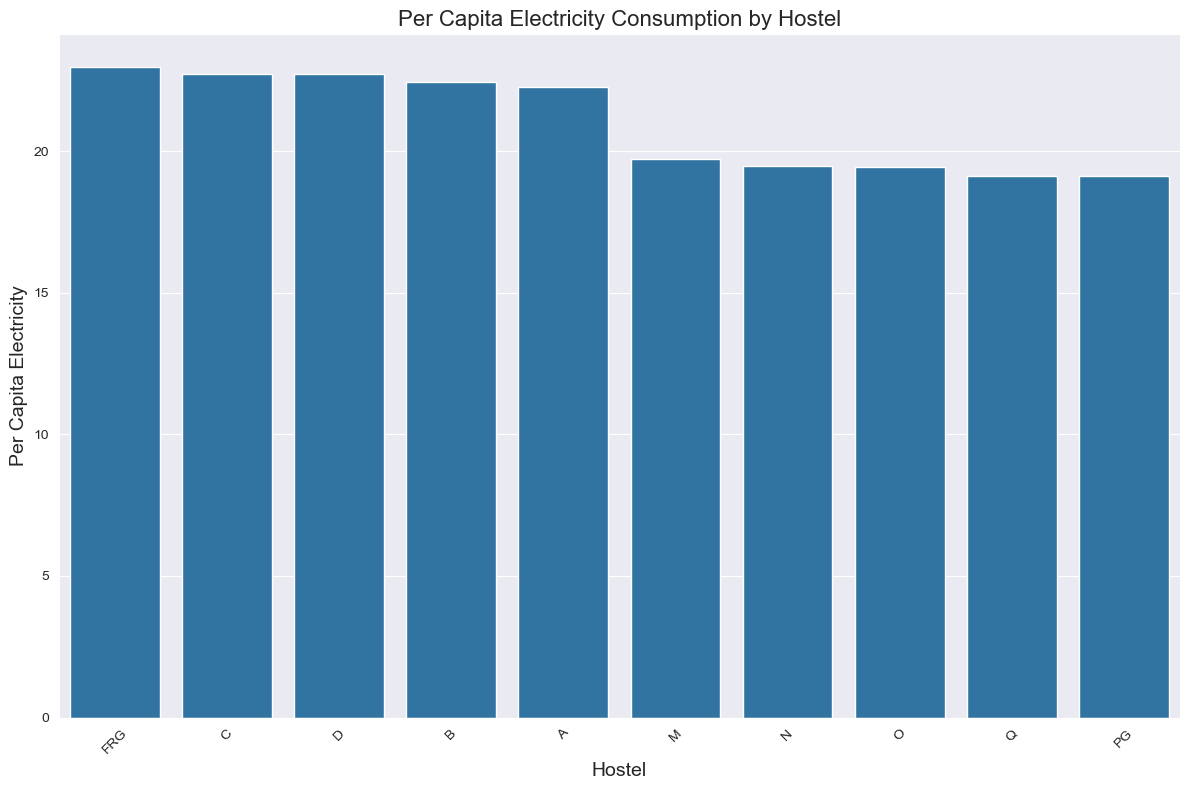

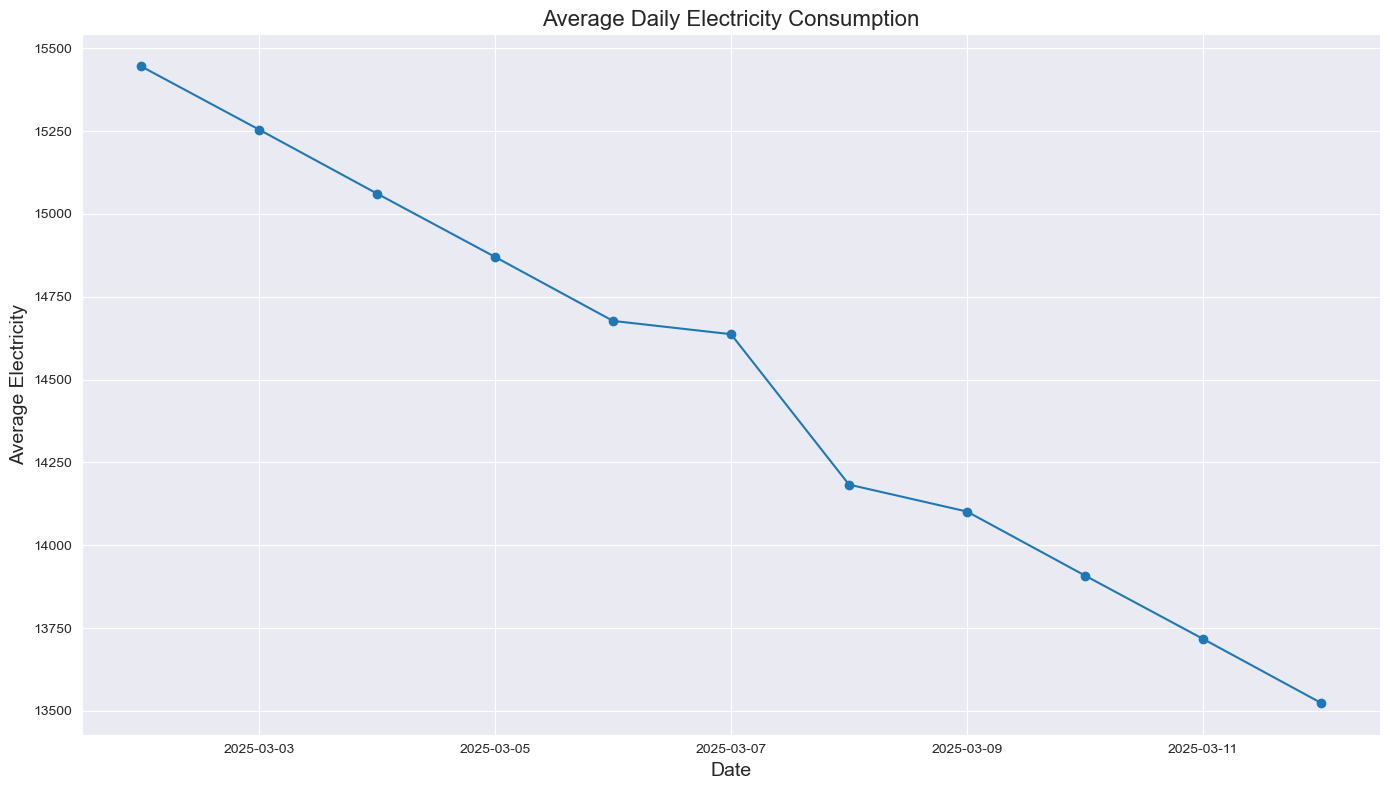

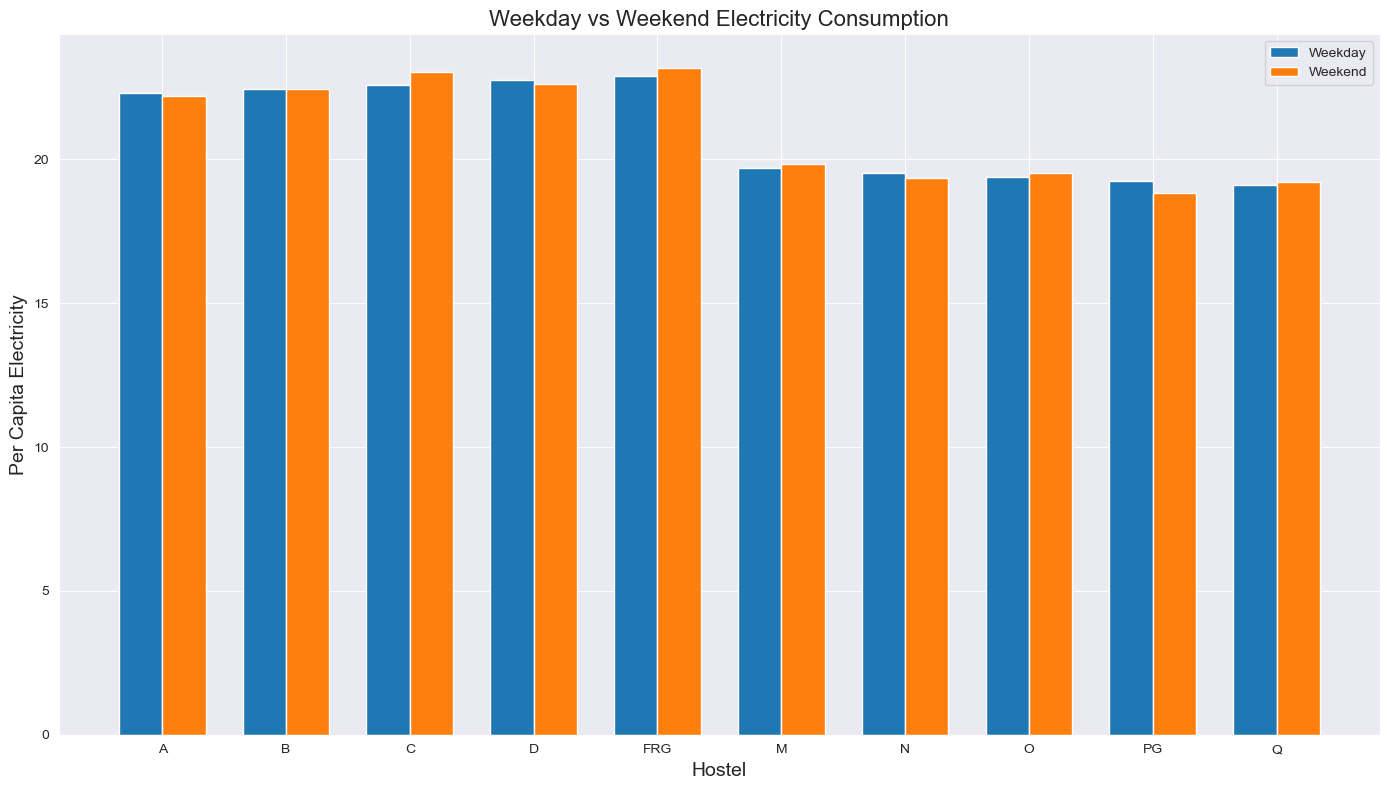


Analyzing water consumption patterns...


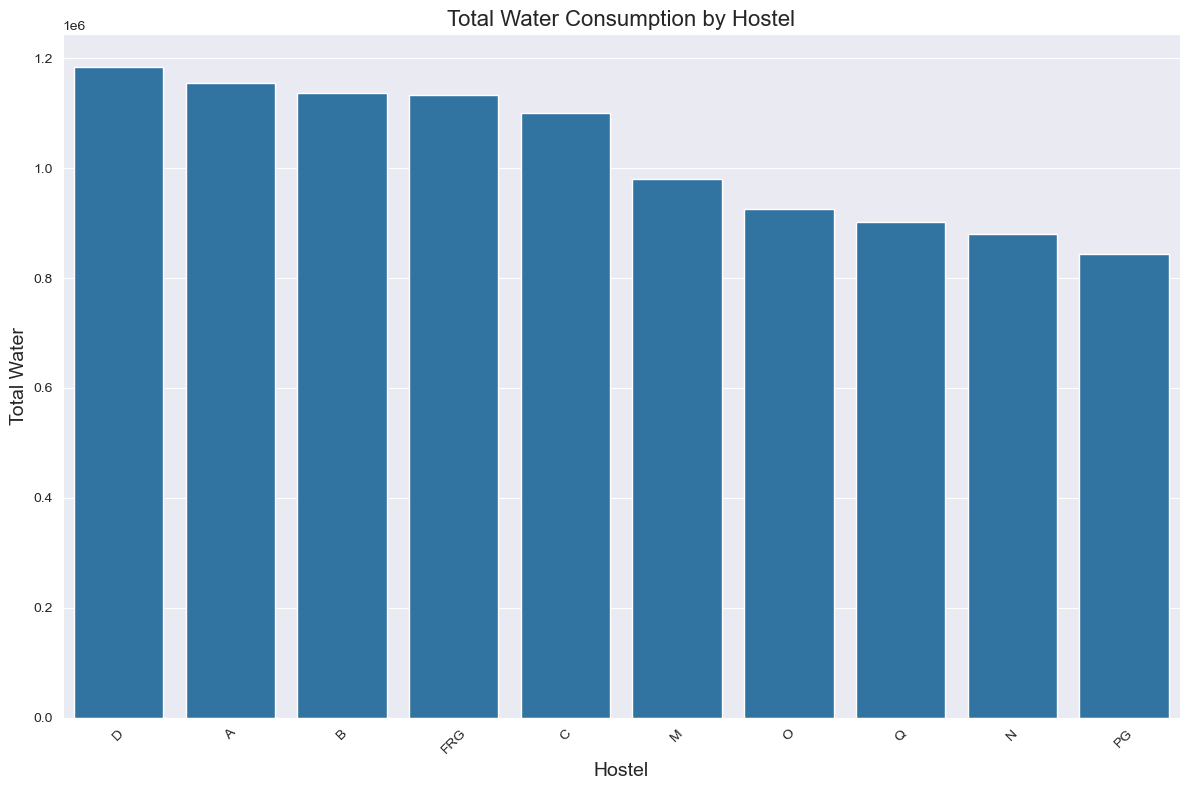

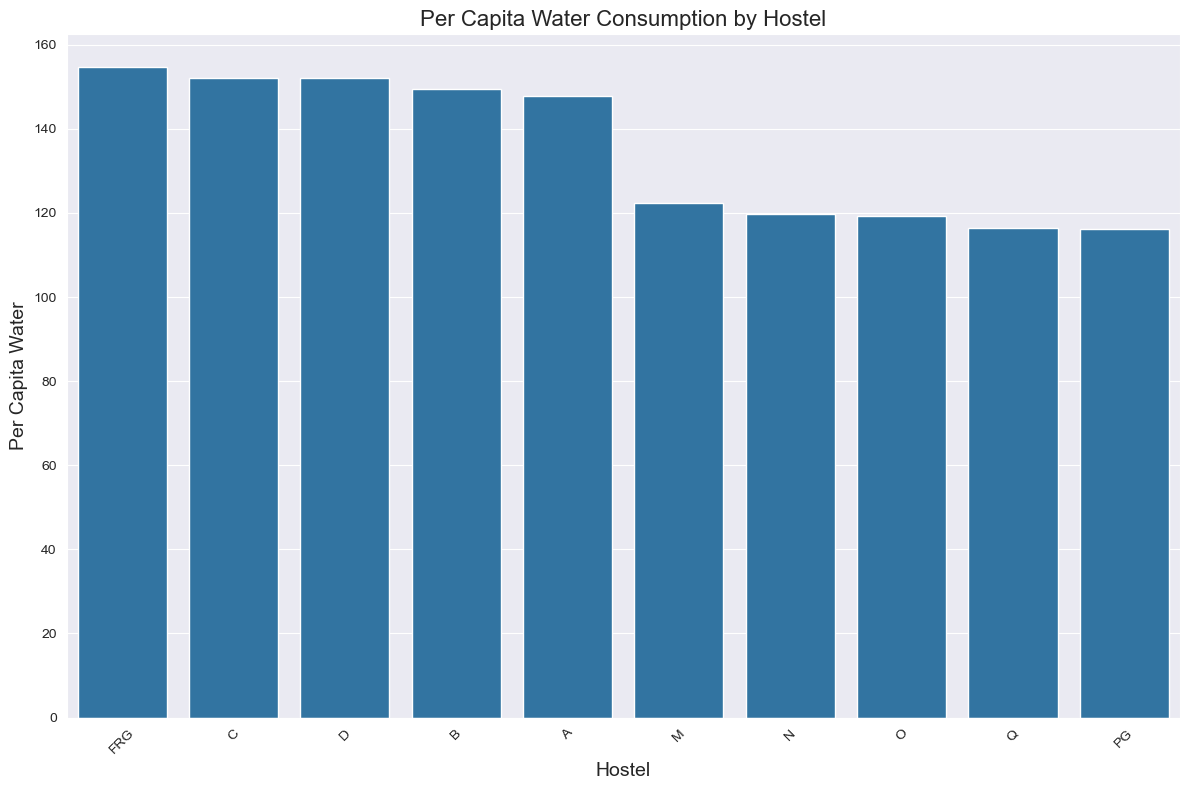

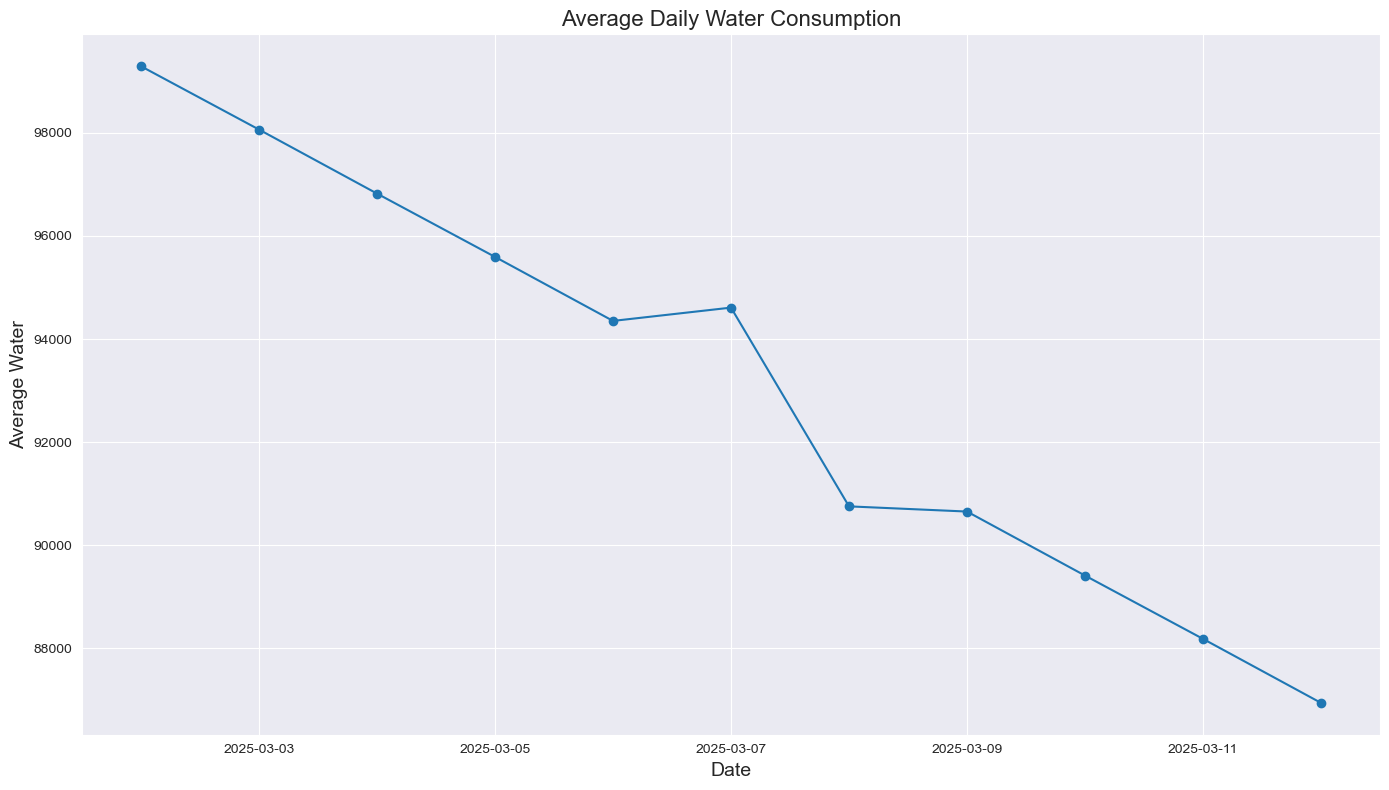

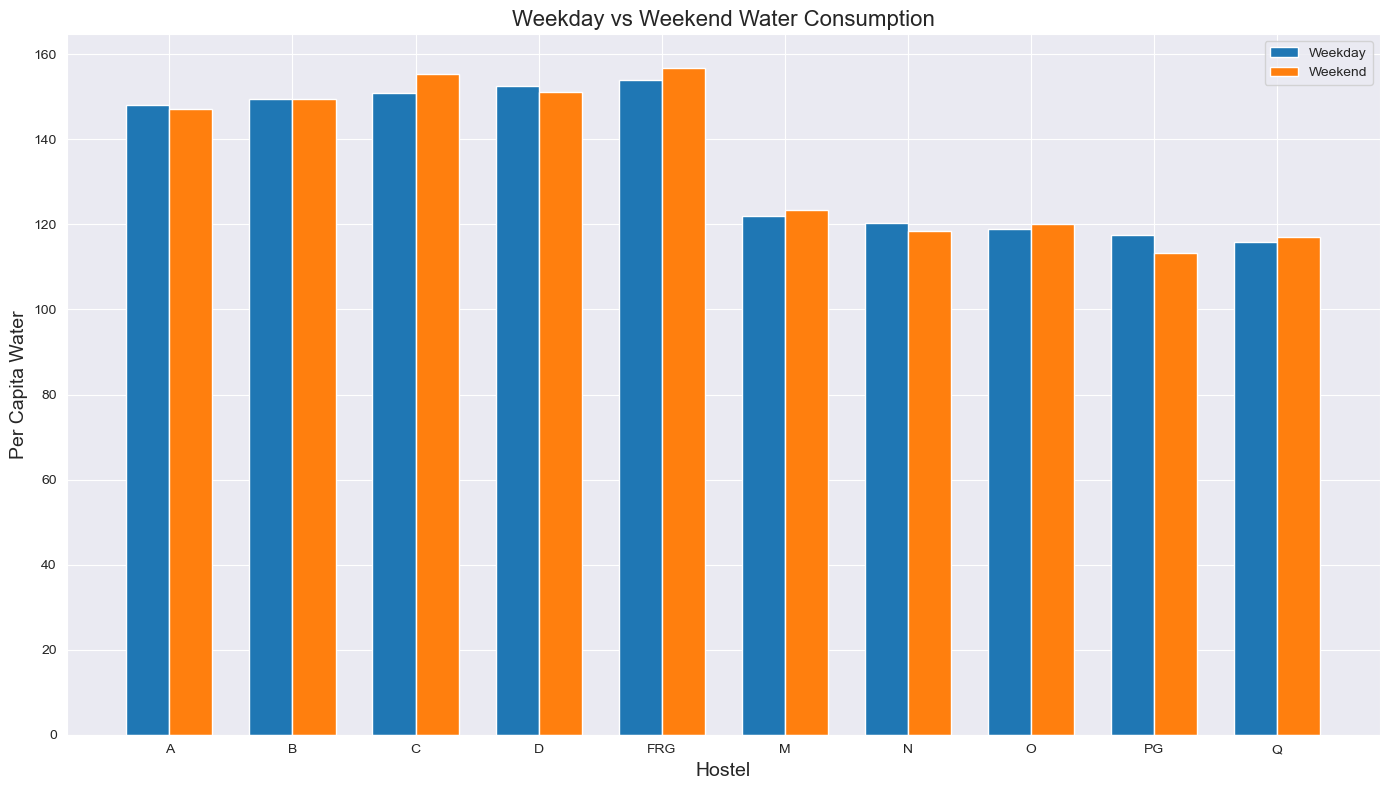


Building electricity prediction model...
Model evaluation - MSE: 139815.17, R²: 0.96
Top 5 important features:
       Feature  Importance
0     capacity    0.161059
8     hostel_D    0.107306
13   hostel_PG    0.102354
7     hostel_C    0.092552
9   hostel_FRG    0.088286

Building water prediction model...
Model evaluation - MSE: 8337462.36, R²: 0.96
Top 5 important features:
       Feature  Importance
8     hostel_D    0.130612
9   hostel_FRG    0.111215
13   hostel_PG    0.106084
0     capacity    0.104066
6     hostel_B    0.099487


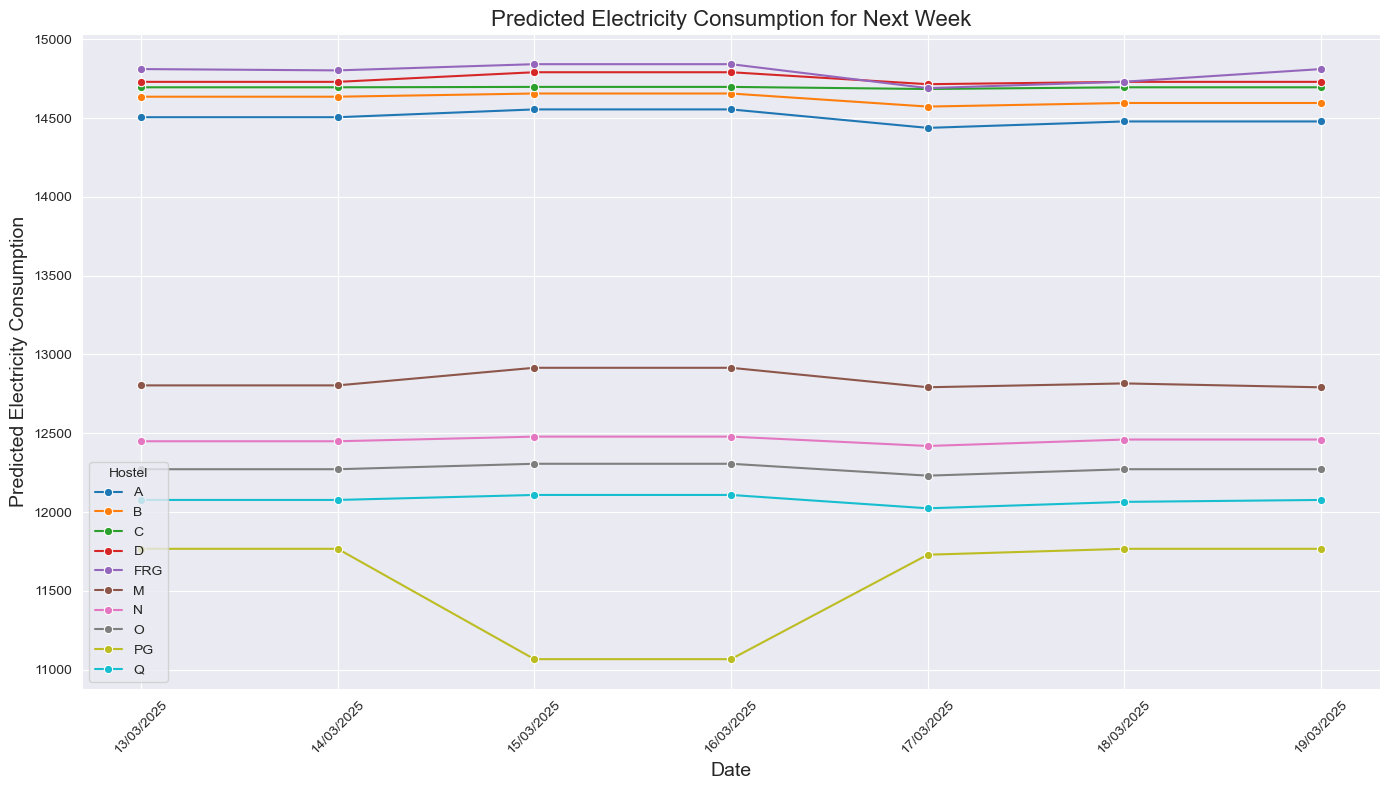

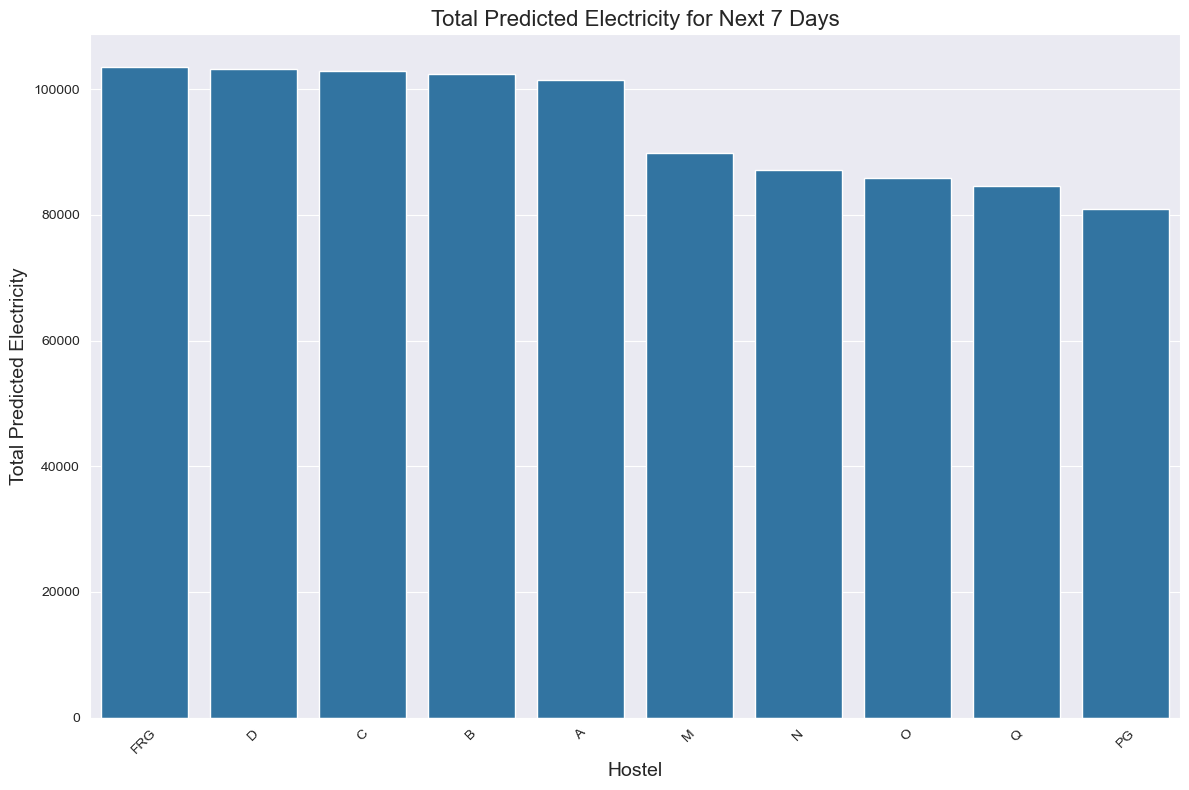

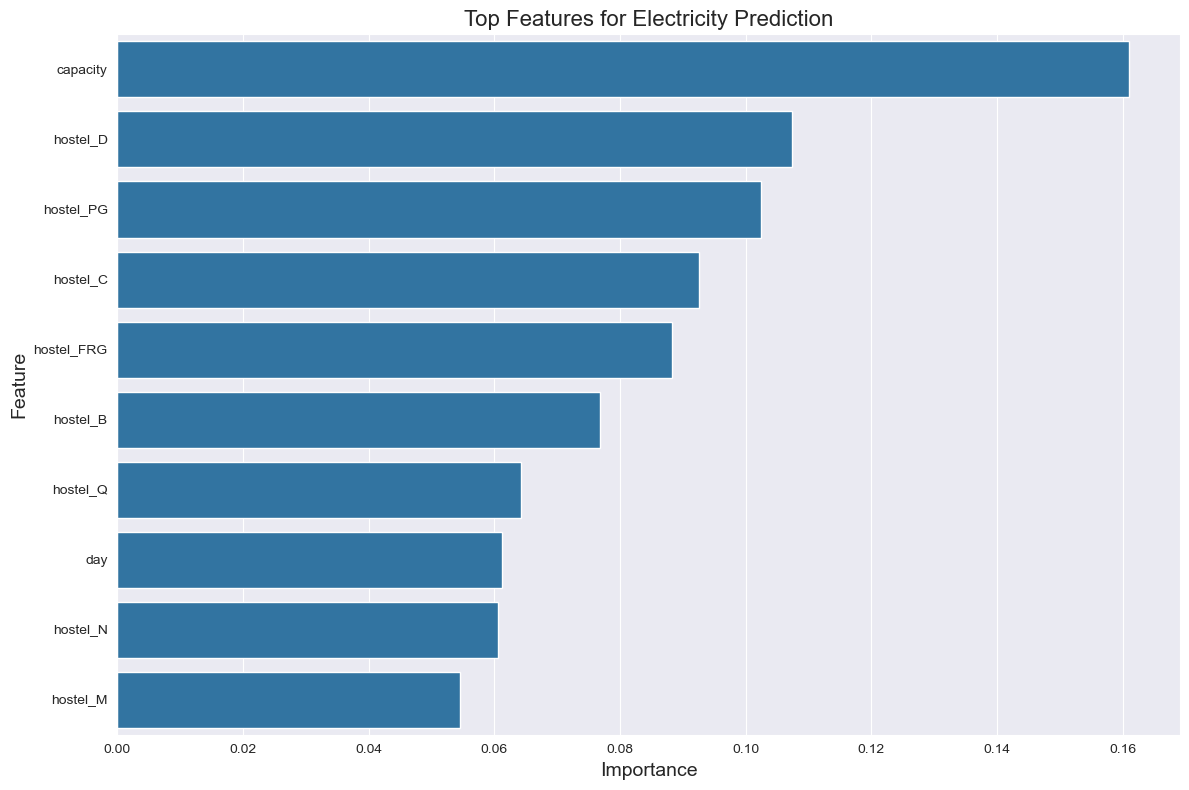


Predicted Electricity Consumption for Next Week:
date_str hostel    13/03/2025    14/03/2025    15/03/2025    16/03/2025  \
4           FRG  14811.033203  14802.699219  14842.108398  14842.108398   
3             D  14729.972656  14729.972656  14790.994141  14790.994141   
2             C  14695.375000  14695.375000  14697.916992  14697.916992   
1             B  14635.660156  14635.660156  14656.000000  14656.000000   
0             A  14505.513672  14505.513672  14555.051758  14555.051758   
5             M  12803.861328  12803.861328  12915.496094  12915.496094   
6             N  12449.291016  12449.291016  12478.731445  12478.731445   
7             O  12271.843750  12271.843750  12306.410156  12306.410156   
9             Q  12076.897461  12076.897461  12108.594727  12108.594727   
8            PG  11766.814453  11766.814453  11066.562500  11066.562500   

date_str    17/03/2025    18/03/2025    19/03/2025          Total  
4         14690.005859  14730.809570  14811.033203  1035

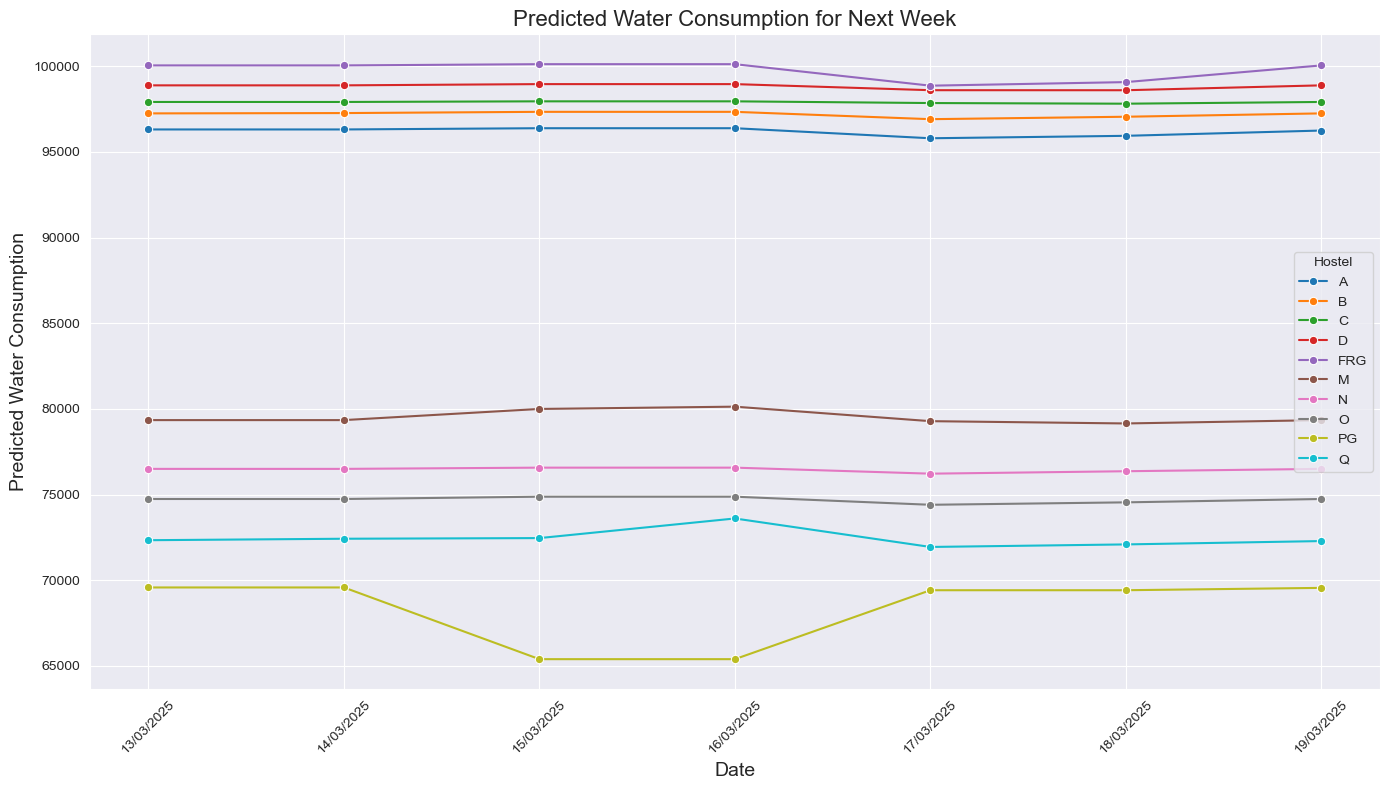

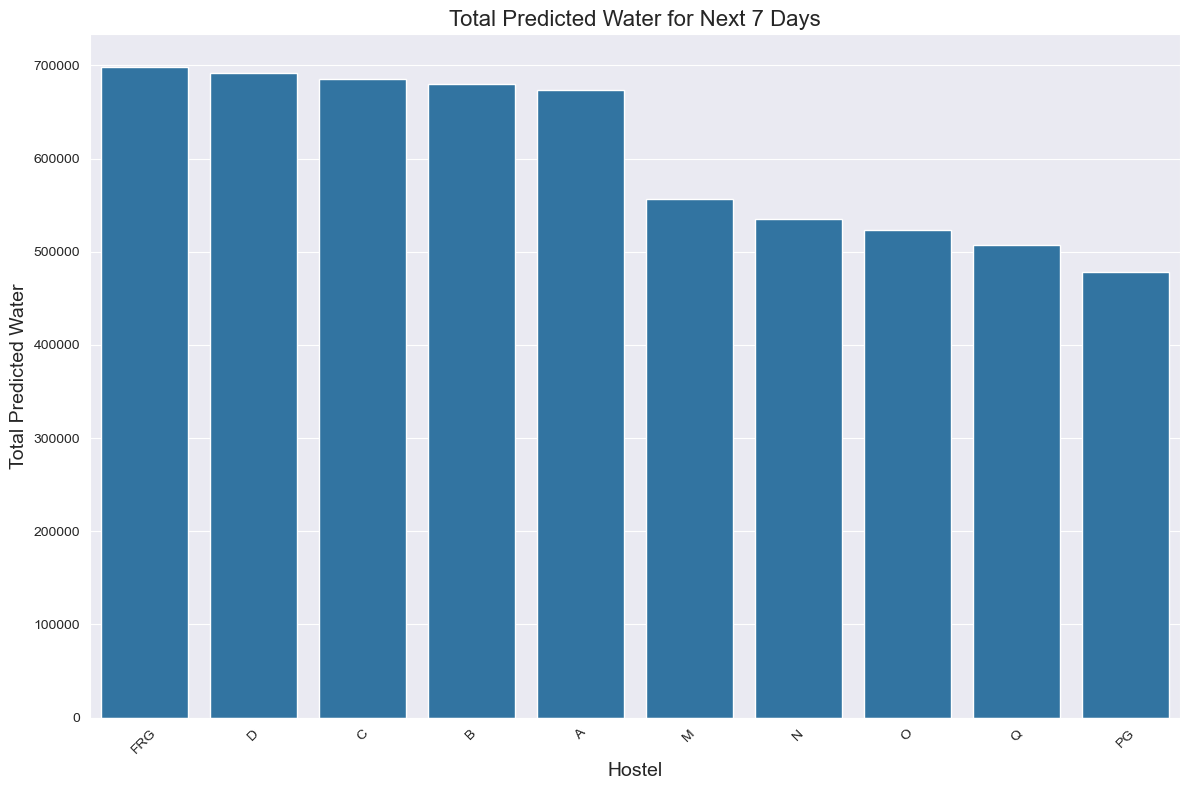

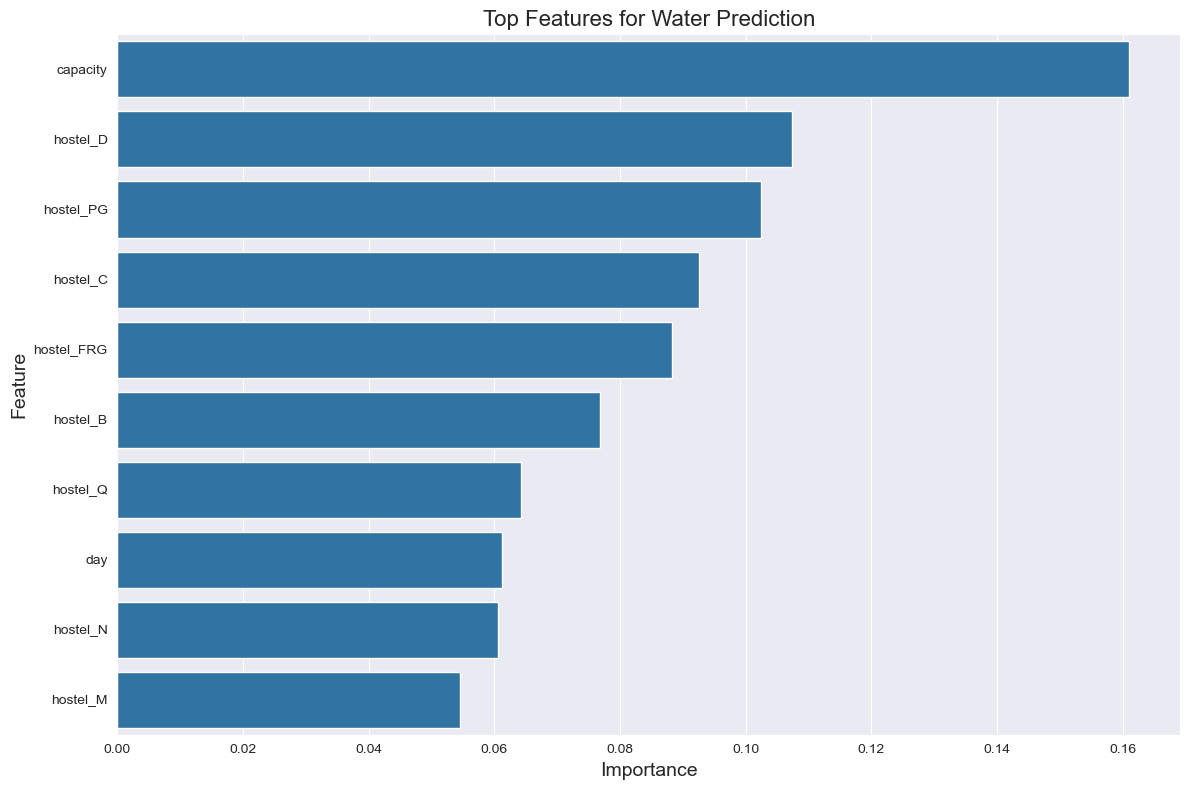


Predicted Water Consumption for Next Week:
date_str hostel     13/03/2025     14/03/2025     15/03/2025     16/03/2025  \
4           FRG  100052.343750  100052.343750  100124.382812  100124.382812   
3             D   98888.351562   98888.351562   98960.390625   98960.390625   
2             C   97918.578125   97918.578125   97955.281250   97955.281250   
1             B   97251.539062   97270.226562   97342.265625   97342.265625   
0             A   96313.960938   96313.960938   96386.000000   96386.000000   
5             M   79347.000000   79347.000000   79998.093750   80131.726562   
6             N   76499.585938   76499.585938   76571.625000   76571.625000   
7             O   74741.453125   74741.453125   74875.843750   74875.843750   
9             Q   72336.031250   72421.703125   72459.609375   73604.687500   
8            PG   69577.609375   69577.609375   65391.710938   65391.710938   

date_str    17/03/2025    18/03/2025     19/03/2025         Total  
4         98869.39

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Set the style for plots
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 8)

# ==============================================
# PART 1: DATA LOADING AND PREPROCESSING
# ==============================================

def load_and_prepare_data(file_path, resource_type):
    """Load and prepare data for analysis and prediction"""
    # Read data
    df = pd.read_csv(file_path)
    
    # Drop any rows with missing values
    df = df.dropna()
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
    
    # Set the resource column name based on type
    resource_col = 'Electricity' if resource_type == 'electricity' else 'Water'
    
    # Rename columns to standardize
    df = df.rename(columns={resource_col: f'total_{resource_type}'})
    
    # Add per capita consumption column
    df[f'per_capita_{resource_type}'] = df[f'total_{resource_type}'] / df['capacity']
    
    # Extract date features
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'] >= 5
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    
    return df

# Load electricity data
print("Loading electricity data...")
electricity_df = load_and_prepare_data('electricity.csv', 'electricity')
print(f"Loaded {len(electricity_df)} electricity records")

# Load water data
print("Loading water data...")
water_df = load_and_prepare_data('water.csv', 'water')
print(f"Loaded {len(water_df)} water records")

# ==============================================
# PART 2: EXPLORATORY DATA ANALYSIS
# ==============================================

def analyze_and_visualize(df, resource_type):
    """Analyze and visualize consumption patterns"""
    # Group by hostel for total consumption
    hostel_consumption = df.groupby('hostel')[f'total_{resource_type}'].sum().reset_index()
    hostel_consumption = hostel_consumption.sort_values(f'total_{resource_type}', ascending=False)
    
    # Calculate per capita consumption
    avg_per_capita = df.groupby('hostel')[f'per_capita_{resource_type}'].mean().reset_index()
    avg_per_capita = avg_per_capita.sort_values(f'per_capita_{resource_type}', ascending=False)
    
    # Plot total consumption by hostel
    plt.figure(figsize=(12, 8))
    sns.barplot(x='hostel', y=f'total_{resource_type}', data=hostel_consumption)
    plt.title(f'Total {resource_type.capitalize()} Consumption by Hostel', fontsize=16)
    plt.xlabel('Hostel', fontsize=14)
    plt.ylabel(f'Total {resource_type.capitalize()}', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot per capita consumption by hostel
    plt.figure(figsize=(12, 8))
    sns.barplot(x='hostel', y=f'per_capita_{resource_type}', data=avg_per_capita)
    plt.title(f'Per Capita {resource_type.capitalize()} Consumption by Hostel', fontsize=16)
    plt.xlabel('Hostel', fontsize=14)
    plt.ylabel(f'Per Capita {resource_type.capitalize()}', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Time series of daily consumption
    daily_avg = df.groupby('date')[f'total_{resource_type}'].mean().reset_index()
    plt.figure(figsize=(14, 8))
    plt.plot(daily_avg['date'], daily_avg[f'total_{resource_type}'], marker='o')
    plt.title(f'Average Daily {resource_type.capitalize()} Consumption', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel(f'Average {resource_type.capitalize()}', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Weekday vs Weekend
    weekday_data = df[~df['is_weekend']]
    weekend_data = df[df['is_weekend']]
    
    weekday_avg = weekday_data.groupby('hostel')[f'per_capita_{resource_type}'].mean()
    weekend_avg = weekend_data.groupby('hostel')[f'per_capita_{resource_type}'].mean()
    
    plt.figure(figsize=(14, 8))
    width = 0.35
    ind = np.arange(len(weekday_avg))
    plt.bar(ind - width/2, weekday_avg, width, label='Weekday')
    plt.bar(ind + width/2, weekend_avg, width, label='Weekend')
    plt.xticks(ind, weekday_avg.index)
    plt.legend()
    plt.title(f'Weekday vs Weekend {resource_type.capitalize()} Consumption', fontsize=16)
    plt.xlabel('Hostel', fontsize=14)
    plt.ylabel(f'Per Capita {resource_type.capitalize()}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Analyze electricity consumption
print("\nAnalyzing electricity consumption patterns...")
analyze_and_visualize(electricity_df, 'electricity')

# Analyze water consumption
print("\nAnalyzing water consumption patterns...")
analyze_and_visualize(water_df, 'water')

# ==============================================
# PART 3: PREDICTION MODEL BUILDING
# ==============================================

def build_prediction_model(df, resource_type, prediction_days=7):
    """Build a model to predict future consumption"""
    print(f"\nBuilding {resource_type} prediction model...")
    
    # Create one-hot encoding for hostels
    hostel_dummies = pd.get_dummies(df['hostel'], prefix='hostel')
    df_with_dummies = pd.concat([df, hostel_dummies], axis=1)
    
    # Select features for the model
    feature_cols = ['capacity', 'day_of_week', 'is_weekend', 'month', 'day'] + list(hostel_dummies.columns)
    X = df_with_dummies[feature_cols]
    y = df_with_dummies[f'total_{resource_type}']
    
    # Split data for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train an XGBoost model
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Evaluate the model
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Model evaluation - MSE: {mse:.2f}, R²: {r2:.2f}")
    
    # Calculate feature importances
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 5 important features:")
    print(feature_importance.head())
    
    # Generate future dates for prediction
    last_date = df['date'].max()
    future_dates = [last_date + timedelta(days=i+1) for i in range(prediction_days)]
    
    # Prepare future scenarios for each hostel
    hostels = df['hostel'].unique()
    future_data = []
    
    for future_date in future_dates:
        for hostel in hostels:
            # Get the last capacity for this hostel
            last_capacity = df[df['hostel'] == hostel]['capacity'].iloc[-1]
            
            # Create prediction scenario
            row = {
                'date': future_date,
                'hostel': hostel,
                'capacity': last_capacity,
                'day_of_week': future_date.dayofweek,
                'is_weekend': future_date.dayofweek >= 5,
                'month': future_date.month,
                'day': future_date.day
            }
            future_data.append(row)
    
    future_df = pd.DataFrame(future_data)
    
    # Create dummy variables for future data
    future_hostel_dummies = pd.get_dummies(future_df['hostel'], prefix='hostel')
    future_df_with_dummies = pd.concat([future_df, future_hostel_dummies], axis=1)
    
    # Ensure all columns from training exist (add missing ones with zeros)
    for col in hostel_dummies.columns:
        if col not in future_df_with_dummies.columns:
            future_df_with_dummies[col] = 0
    
    # Select features for prediction
    future_X = future_df_with_dummies[feature_cols]
    
    # Scale features
    future_X_scaled = scaler.transform(future_X)
    
    # Make predictions
    future_df['predicted_consumption'] = model.predict(future_X_scaled)
    future_df['per_capita_prediction'] = future_df['predicted_consumption'] / future_df['capacity']
    
    return future_df, model, feature_importance

# Build electricity prediction model
electricity_predictions, electricity_model, electricity_importance = build_prediction_model(
    electricity_df, 'electricity', prediction_days=7
)

# Build water prediction model
water_predictions, water_model, water_importance = build_prediction_model(
    water_df, 'water', prediction_days=7
)

# ==============================================
# PART 4: VISUALIZE PREDICTIONS
# ==============================================

def visualize_predictions(predictions, resource_type):
    """Visualize the predictions"""
    # Format date for display
    predictions['date_str'] = predictions['date'].dt.strftime('%d/%m/%Y')
    
    # Plot predictions by date and hostel
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        x='date_str', 
        y='predicted_consumption', 
        hue='hostel', 
        data=predictions,
        marker='o'
    )
    plt.title(f'Predicted {resource_type.capitalize()} Consumption for Next Week', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel(f'Predicted {resource_type.capitalize()} Consumption', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title='Hostel')
    plt.tight_layout()
    plt.show()
    
    # Plot total predictions by hostel (sum across all prediction days)
    hostel_predictions = predictions.groupby('hostel')['predicted_consumption'].sum().reset_index()
    hostel_predictions = hostel_predictions.sort_values('predicted_consumption', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='hostel', y='predicted_consumption', data=hostel_predictions)
    plt.title(f'Total Predicted {resource_type.capitalize()} for Next 7 Days', fontsize=16)
    plt.xlabel('Hostel', fontsize=14)
    plt.ylabel(f'Total Predicted {resource_type.capitalize()}', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot feature importance
    feature_importance = pd.DataFrame({
        'Feature': electricity_importance['Feature'],
        'Importance': electricity_importance['Importance']
    }).head(10)  # Top 10 features
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Top Features for {resource_type.capitalize()} Prediction', fontsize=16)
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Create a summary table of predictions
    summary_table = predictions.pivot_table(
        values='predicted_consumption',
        index='hostel',
        columns='date_str',
        aggfunc='sum'
    ).reset_index()
    
    # Add a total column
    summary_table['Total'] = summary_table.iloc[:, 1:].sum(axis=1)
    summary_table = summary_table.sort_values('Total', ascending=False)
    
    print(f"\nPredicted {resource_type.capitalize()} Consumption for Next Week:")
    print(summary_table)
    
    return summary_table

# Visualize electricity predictions
electricity_summary = visualize_predictions(electricity_predictions, 'electricity')

# Visualize water predictions
water_summary = visualize_predictions(water_predictions, 'water')

# ==============================================
# PART 5: SAVE RESULTS
# ==============================================

# Save prediction summaries to CSV
electricity_summary.to_csv(f'electricity_predictions_summary.csv', index=False)
water_summary.to_csv(f'water_predictions_summary.csv', index=False)

# Save full prediction details
electricity_predictions.to_csv('electricity_predictions_detailed.csv', index=False)
water_predictions.to_csv('water_predictions_detailed.csv', index=False)

print("\nPrediction summaries saved to CSV files.")
print("Analysis and predictions complete!")

Loading electricity data...
Loaded 110 electricity records
        date hostel  capacity  total_electricity  per_capita_electricity  \
0 2025-03-02      A       928              20388               21.969828   
1 2025-03-02      B       724              16204               22.381215   
2 2025-03-02      C       387               9227               23.842377   
3 2025-03-02      D       928              20688               22.293103   
4 2025-03-02    FRG       480              11380               23.708333   

   day_of_week  is_weekend  month  day  
0            6        True      3    2  
1            6        True      3    2  
2            6        True      3    2  
3            6        True      3    2  
4            6        True      3    2  

Loading water data...
Loaded 110 water records
        date hostel  capacity  total_water  per_capita_water  day_of_week  \
0 2025-03-02      A       928       134280        144.698276            6   
1 2025-03-02      B       724       

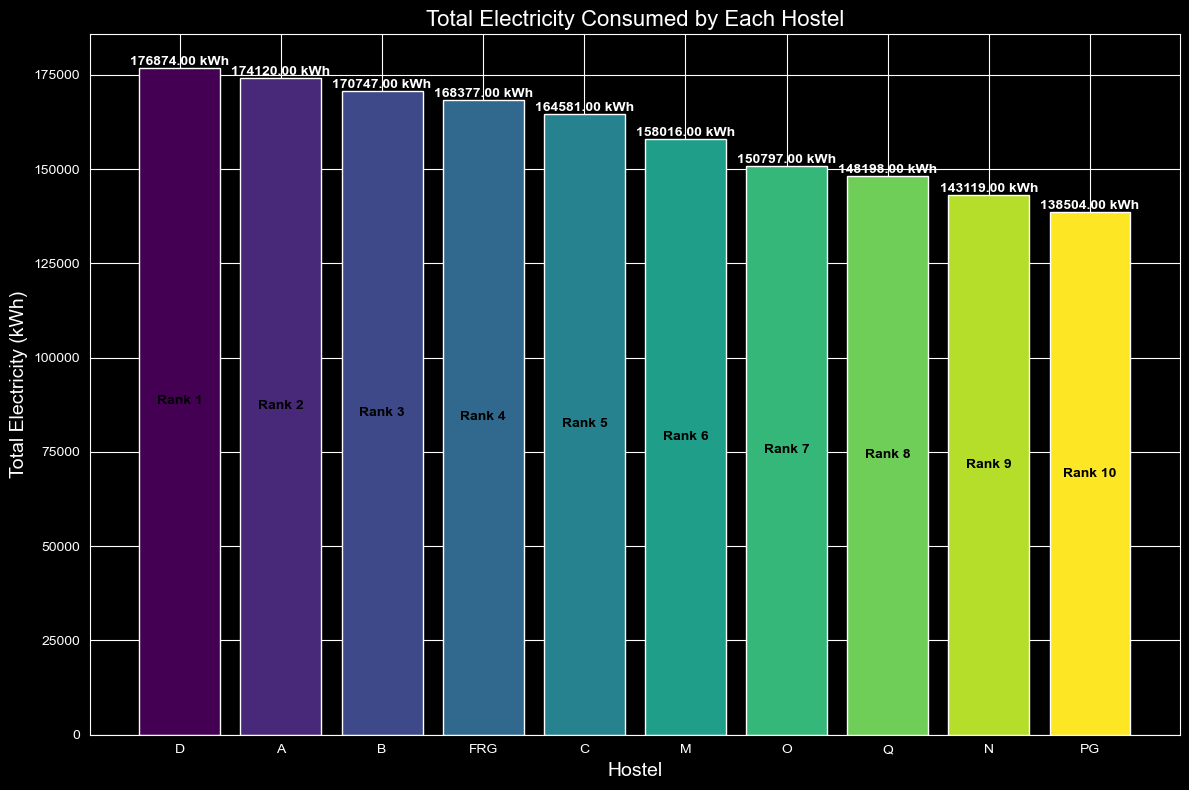

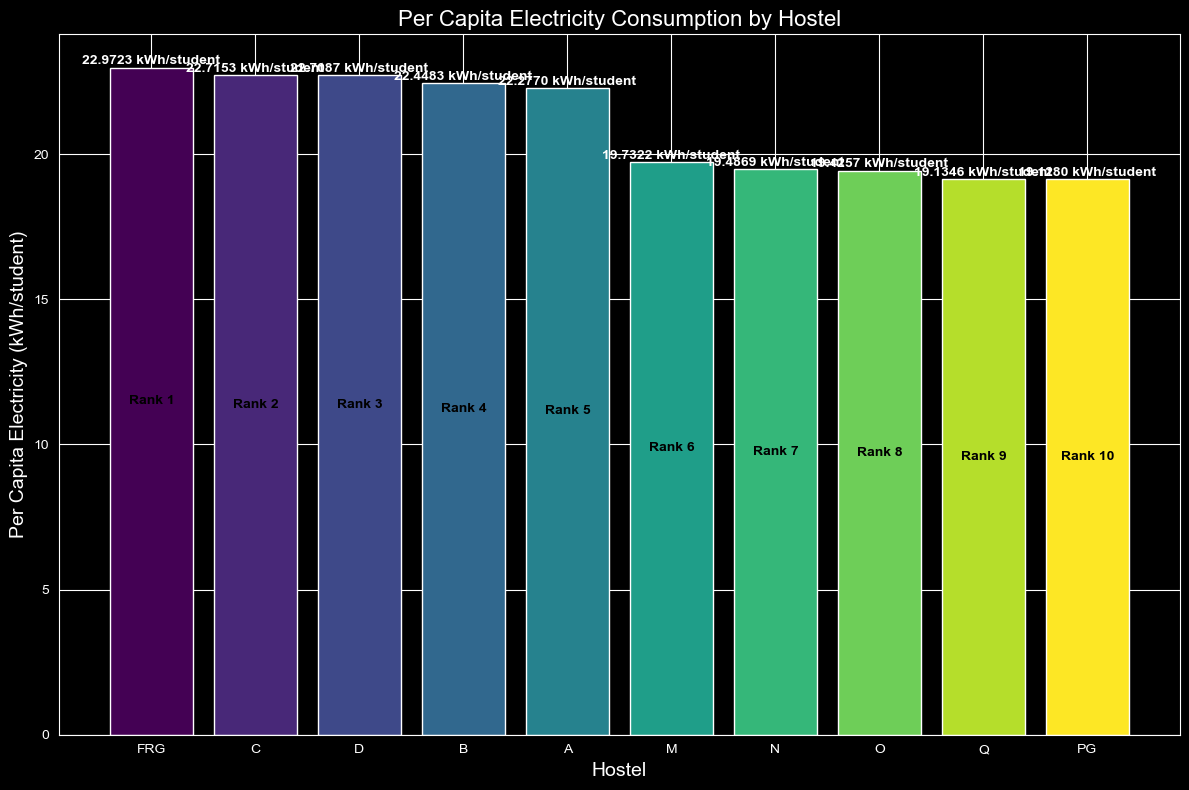

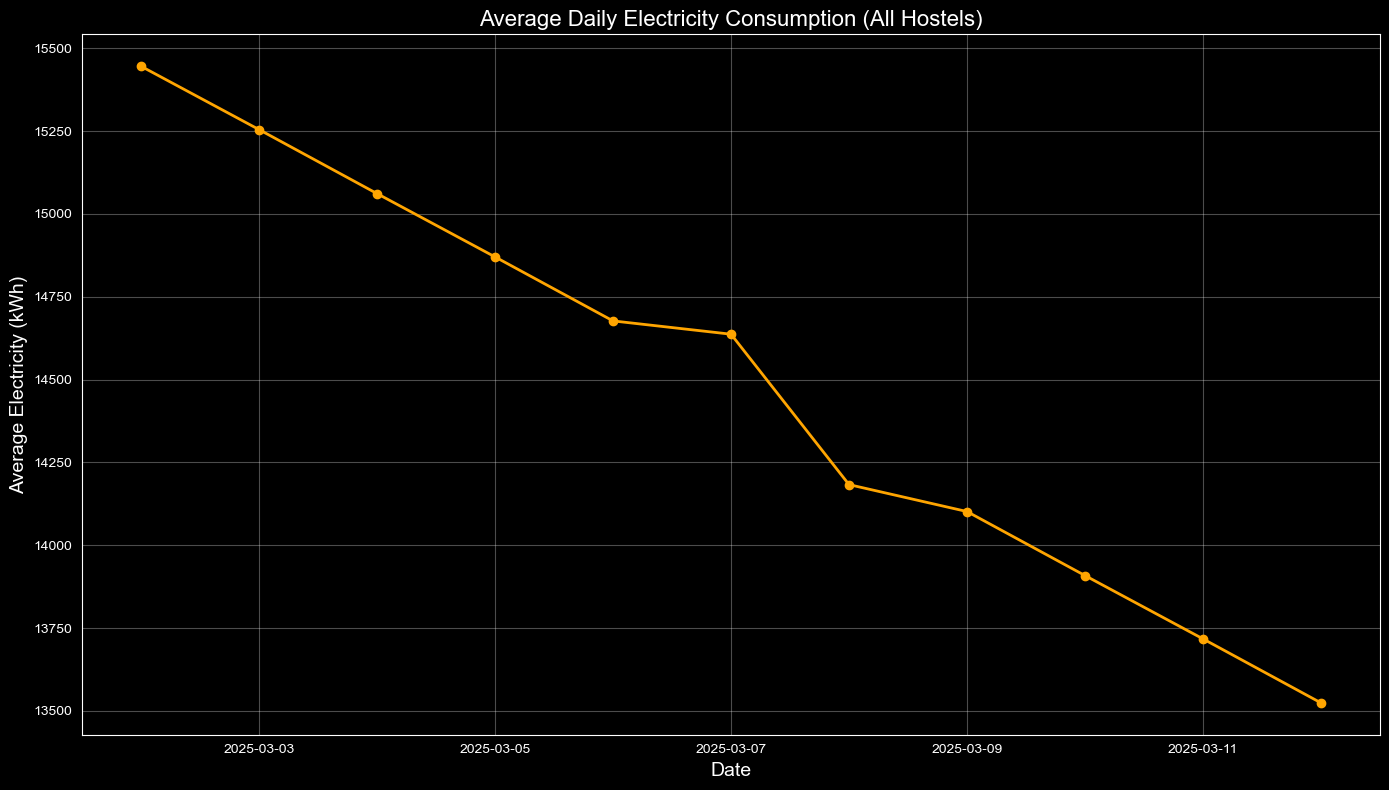

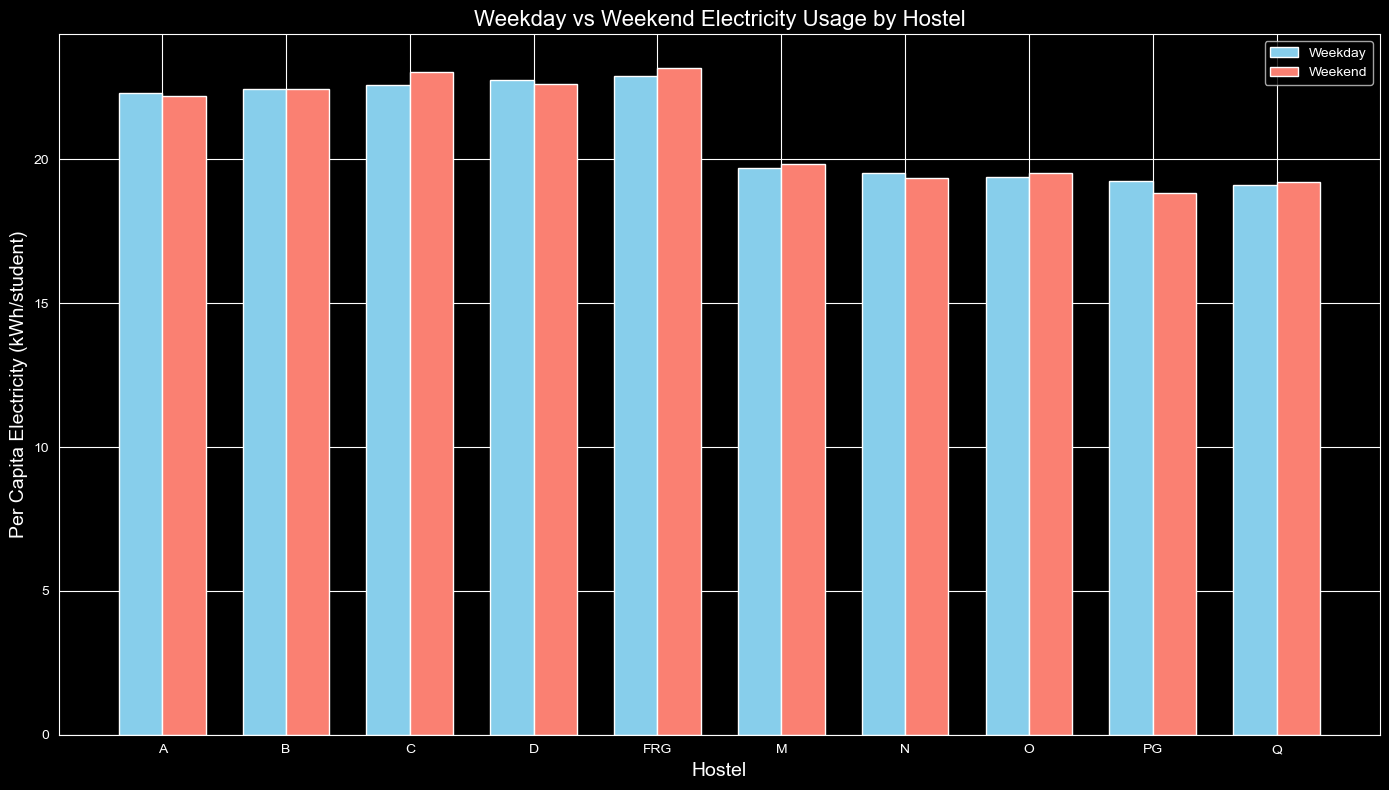


Hostel Ranking by Total Water Usage:
  hostel  total_water
3      D      1184190
0      A      1154700
1      B      1136945
4    FRG      1133495
2      C      1101235
5      M       980460
7      O       926195
9      Q       901630
6      N       880765
8     PG       843240

Hostel Ranking by Per Capita Water Usage:
  hostel  per_capita_water
4    FRG        154.722892
2      C        152.152886
3      D        152.087464
1      B        149.482868
0      A        147.770369
5      M        122.322005
6      N        119.869417
7      O        119.257265
9      Q        116.346405
8     PG        116.280170


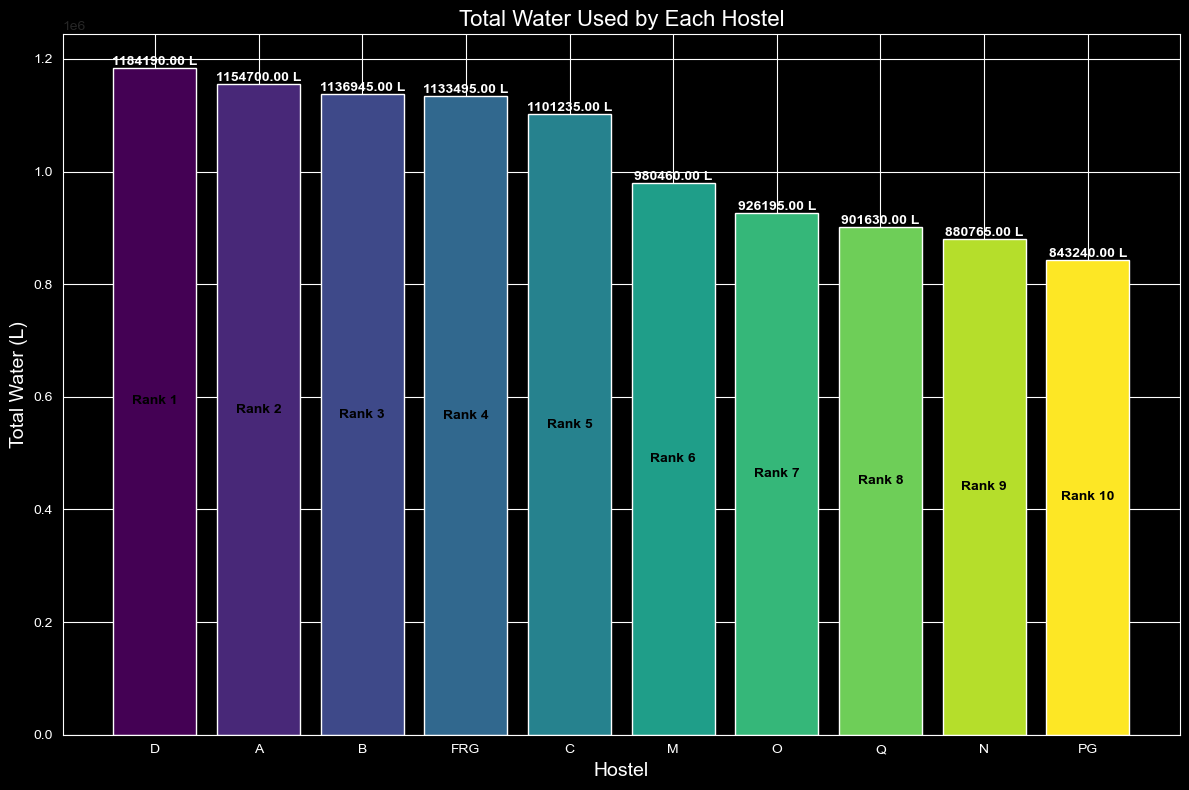

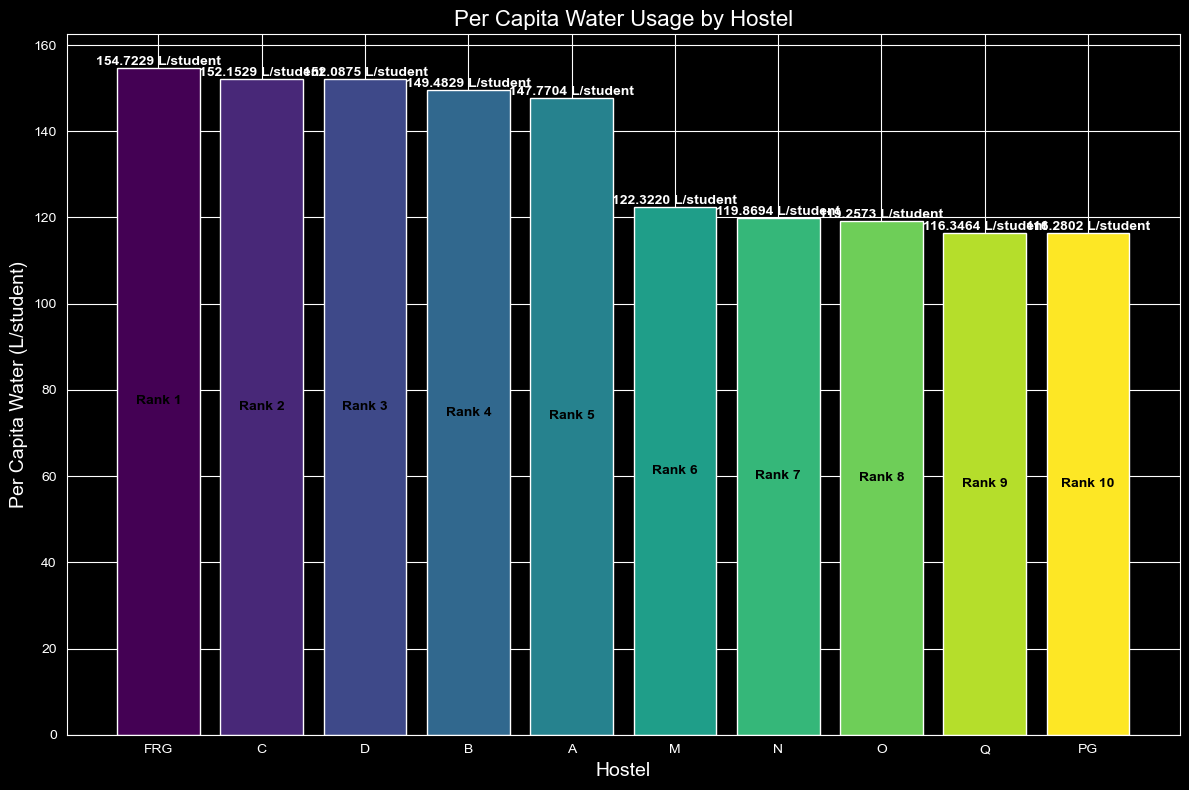

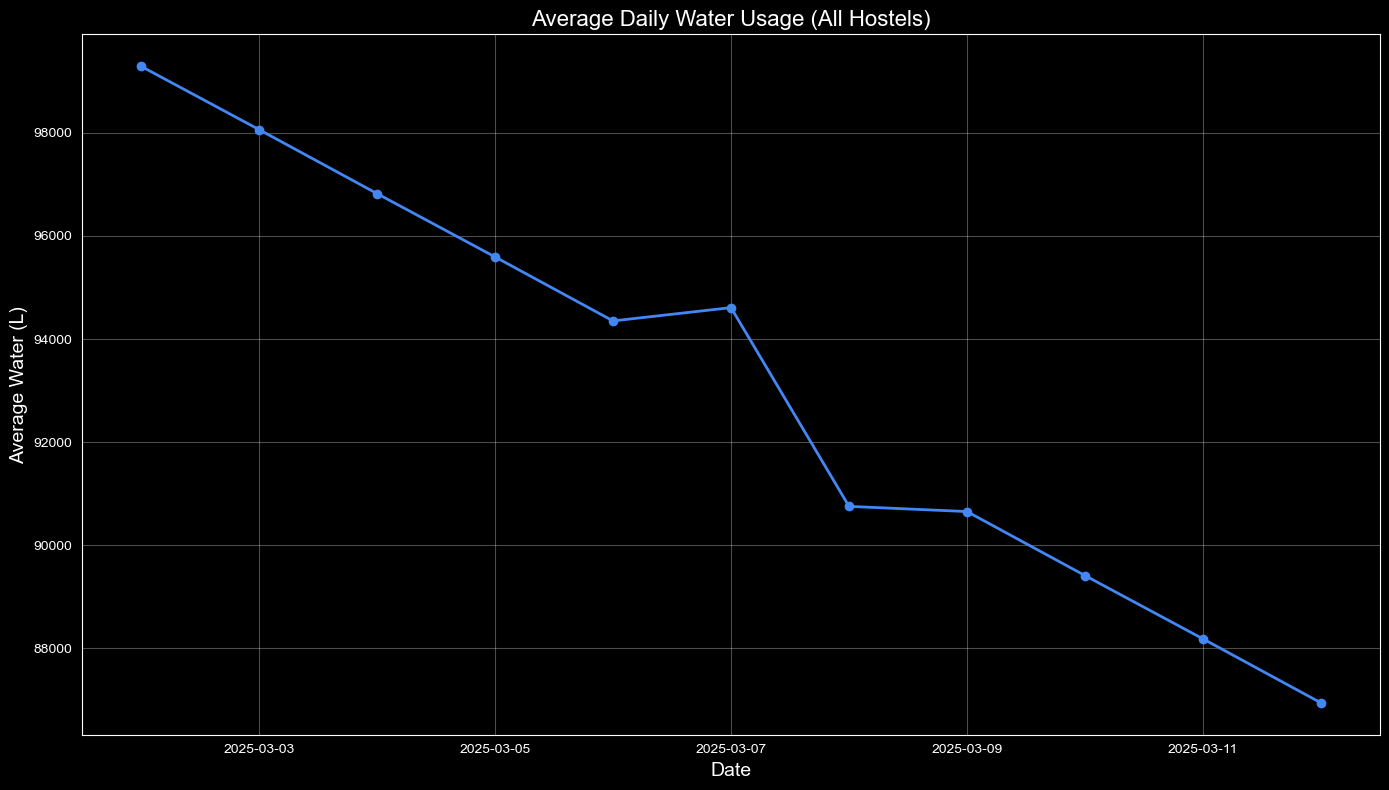

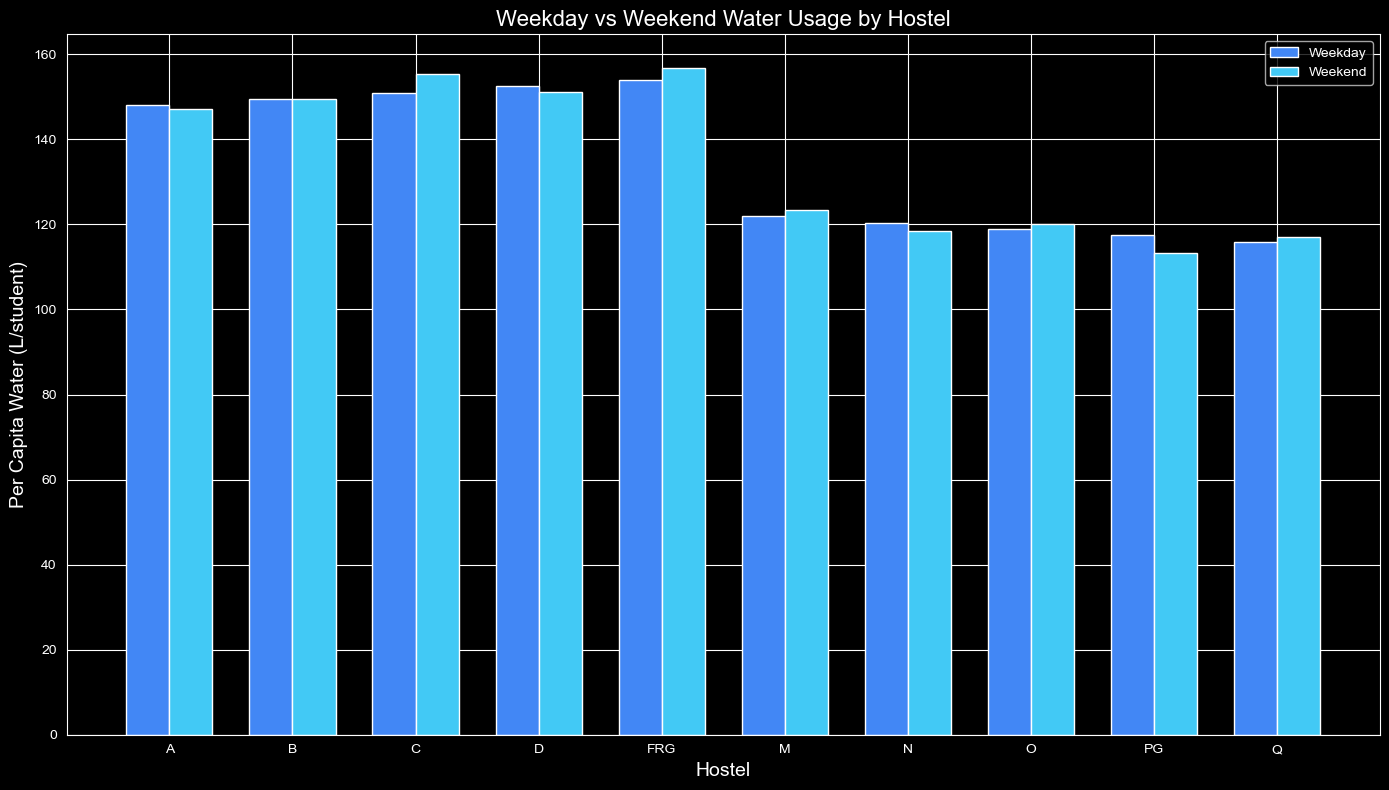

Electricity model - Train set: (88, 15), Test set: (22, 15)

Training XGBoost model to predict electricity consumption...
Electricity Model Performance:
Mean Squared Error: 220377.60
Mean Absolute Error: 320.29
R² Score: 0.94

Factors influencing electricity consumption:
       Feature  Importance
0     capacity    0.132502
2   is_weekend    0.120094
13   hostel_PG    0.094671
7     hostel_C    0.093479
14    hostel_Q    0.074163
8     hostel_D    0.073510
9   hostel_FRG    0.070392
10    hostel_M    0.062386
6     hostel_B    0.061422
11    hostel_N    0.059056


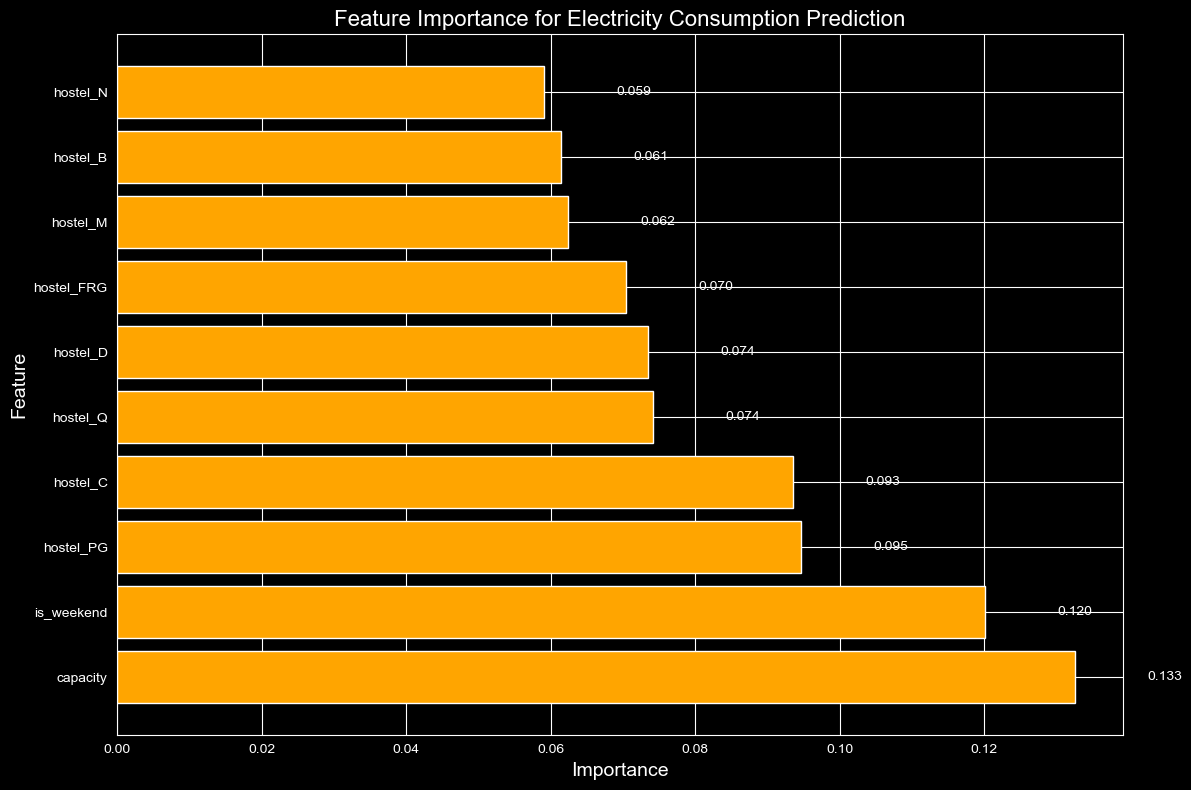

Water model - Train set: (88, 15), Test set: (22, 15)

Training XGBoost model to predict water usage...
Water Model Performance:
Mean Squared Error: 12043874.31
Mean Absolute Error: 2395.63
R² Score: 0.95

Factors influencing water usage:
       Feature  Importance
8     hostel_D    0.146672
6     hostel_B    0.120817
9   hostel_FRG    0.105133
13   hostel_PG    0.098526
7     hostel_C    0.091640
0     capacity    0.091162
14    hostel_Q    0.071903
5     hostel_A    0.062197
12    hostel_O    0.051676
10    hostel_M    0.047544


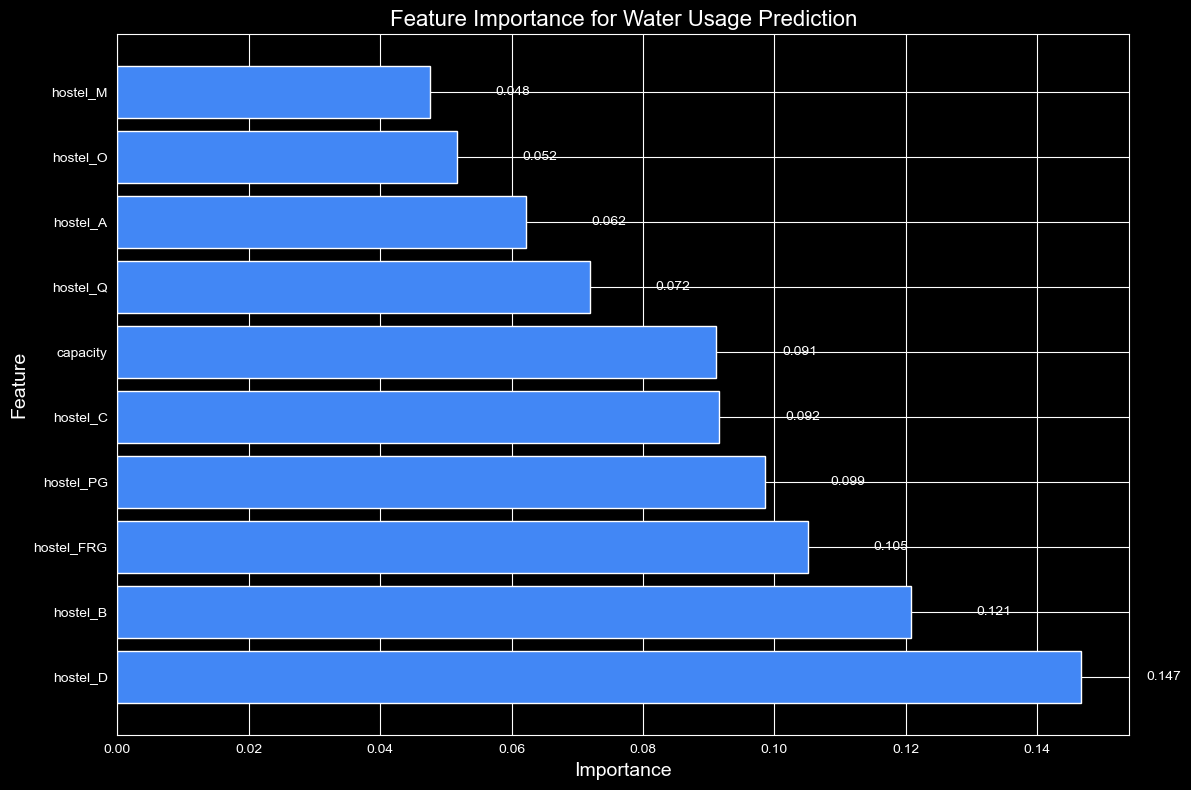


Generating electricity consumption forecasts for the next 7 days...
Generating water usage forecasts for the next 7 days...

Visualizing electricity consumption forecasts...


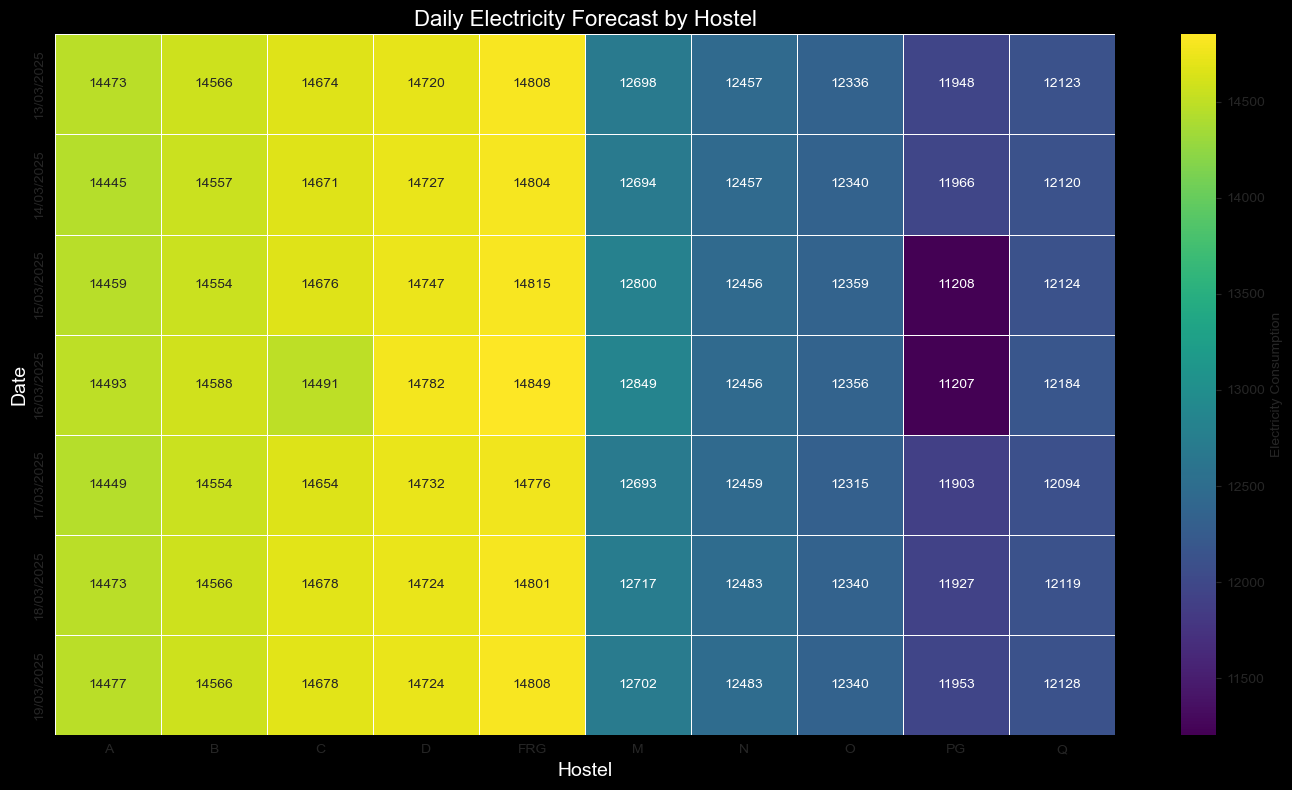

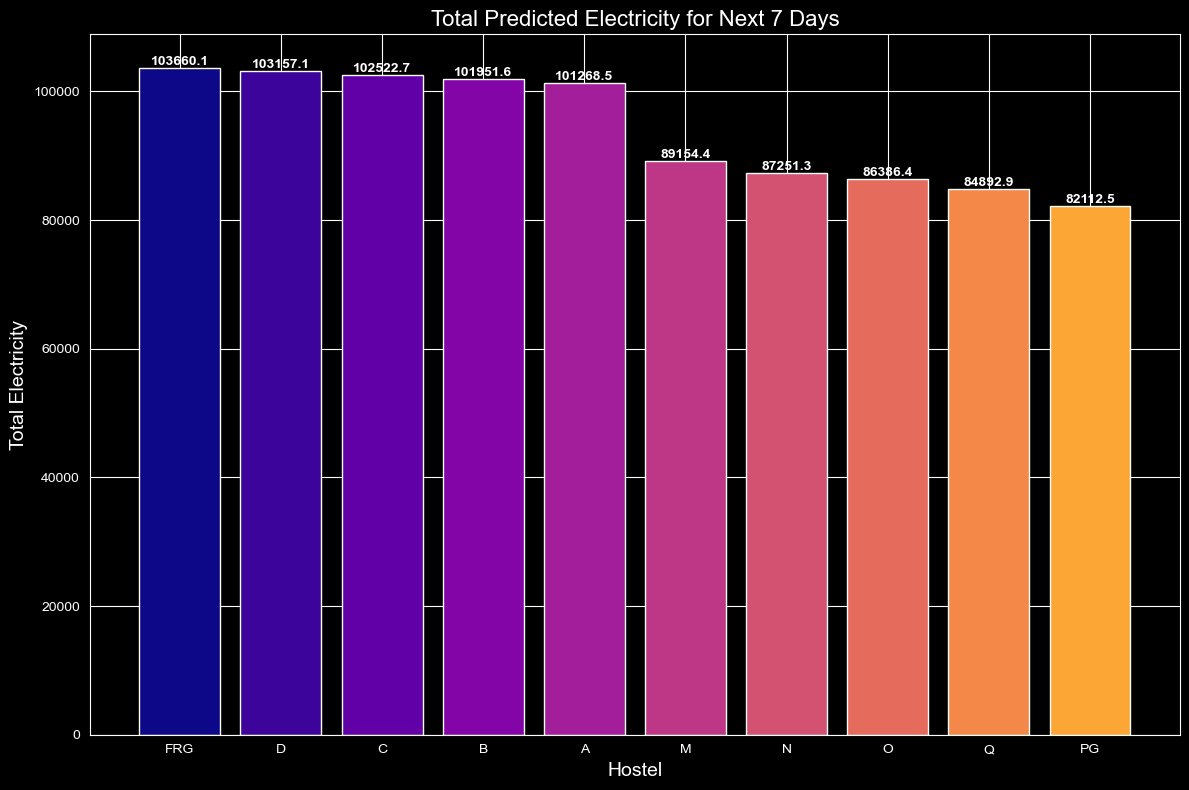

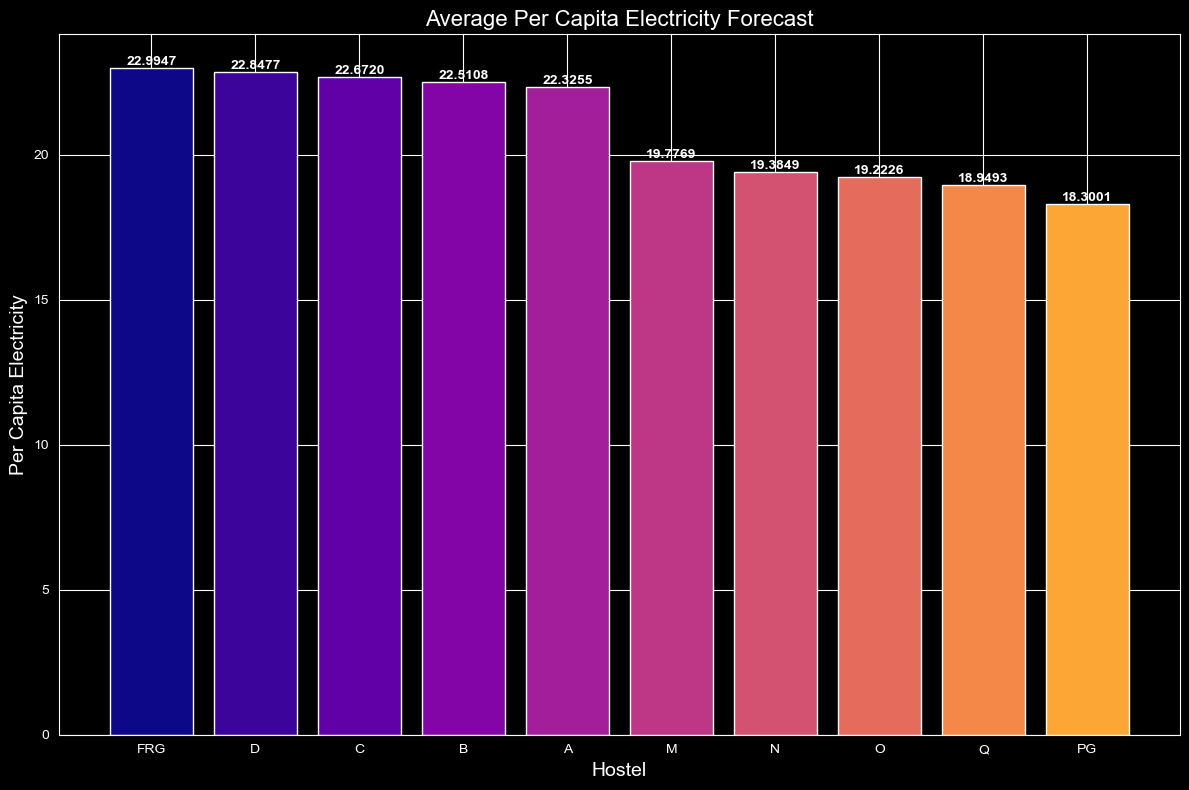


Visualizing water usage forecasts...


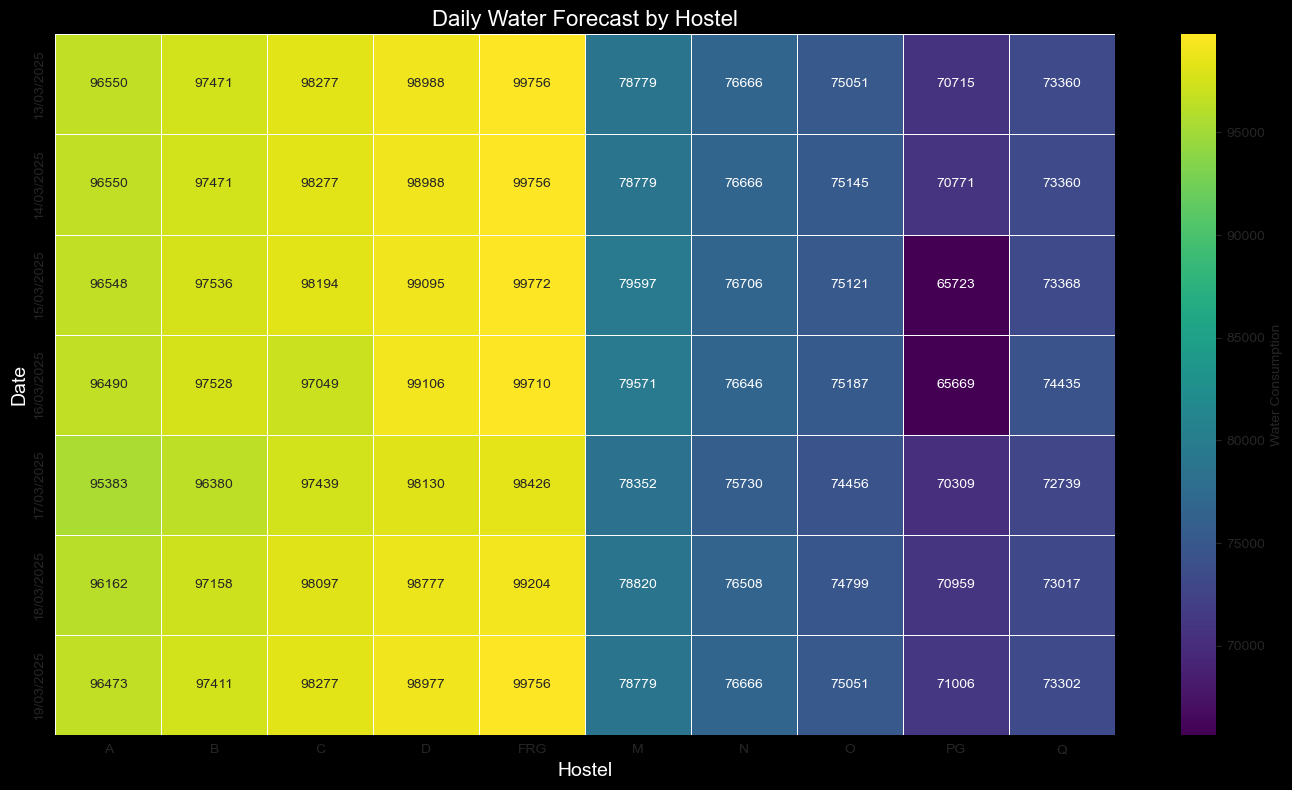

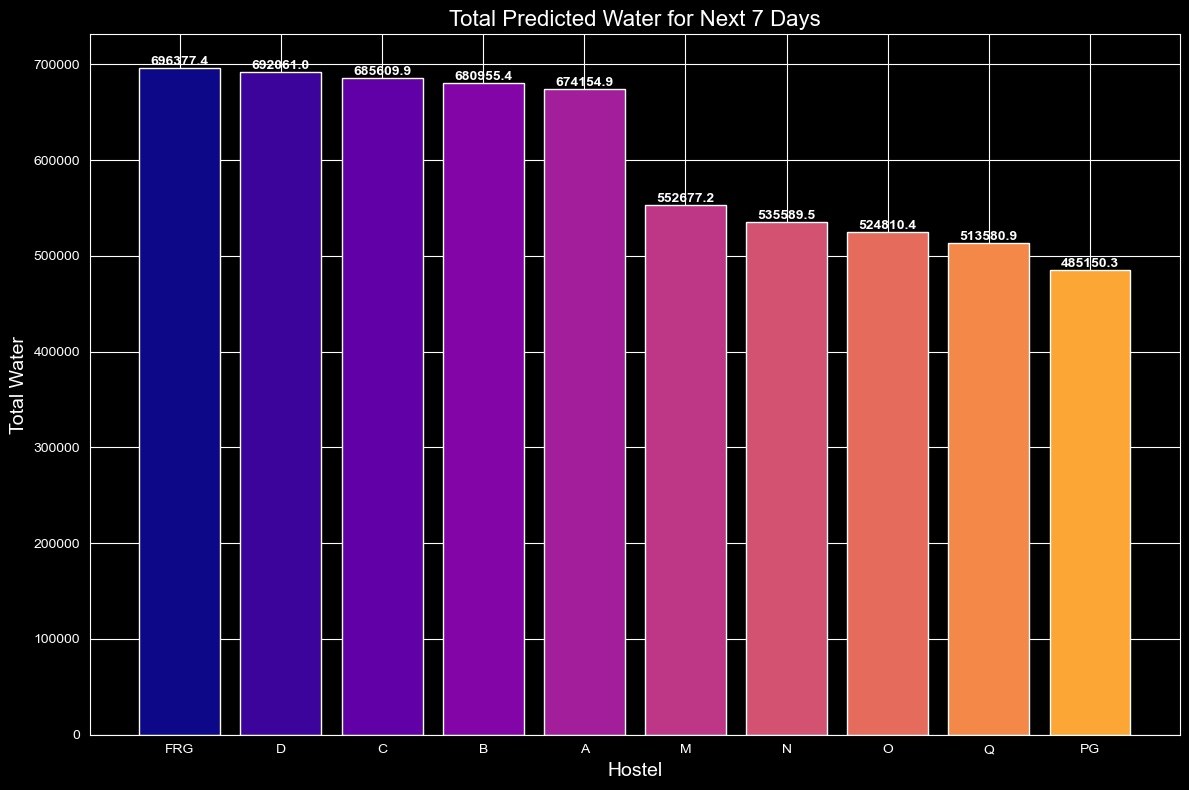

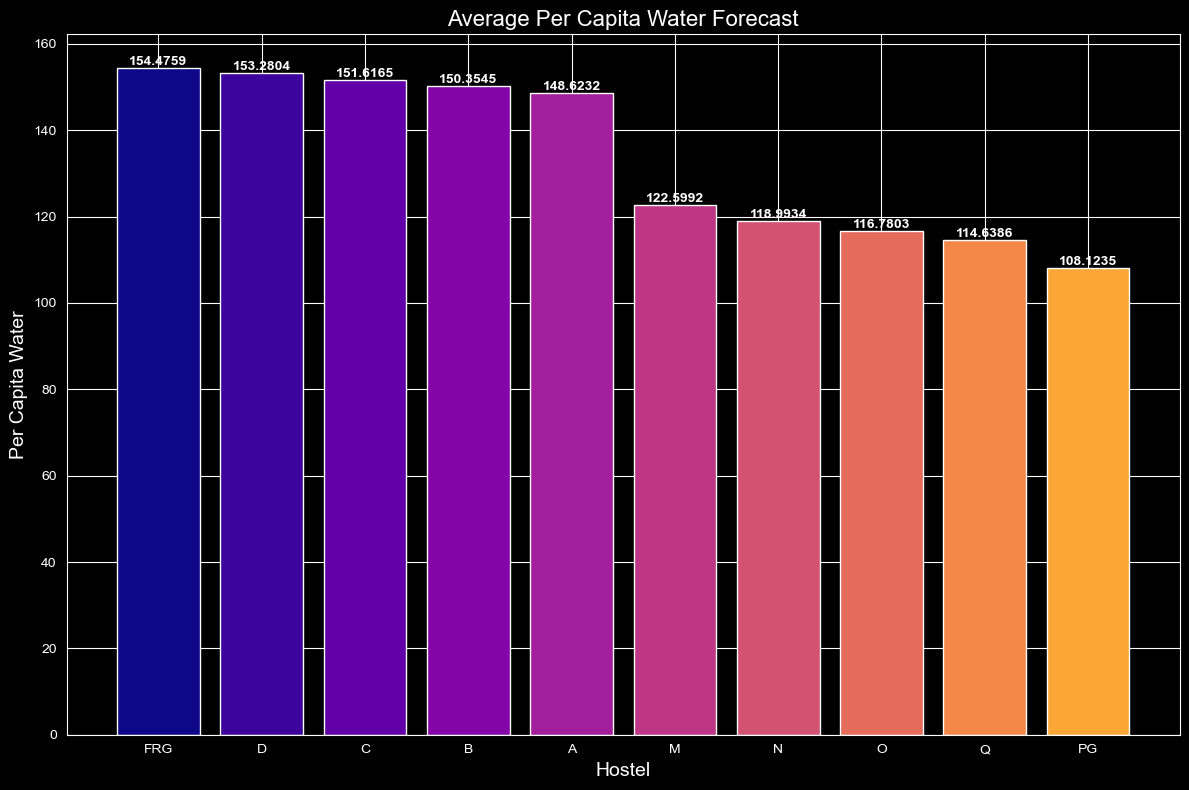


Generating recommendations for electricity conservation...

===== ELECTRICITY CONSERVATION RECOMMENDATIONS =====

Hostel FRG - Rank 5 (Students: 644)
Expected daily electricity: 22.9947 per student, 14808.58 total
• HIGH USAGE: 10.0% above average
  Recommendations:
  - Conduct an energy audit to identify major consumption sources
  - Check for inefficient appliances or equipment
  - Implement awareness campaigns about energy conservation
• Based on XGBoost model, focus on optimizing: capacity

Hostel D - Rank 4 (Students: 645)
Expected daily electricity: 22.8477 per student, 14736.73 total
• Based on XGBoost model, focus on optimizing: capacity

Hostel C - Rank 3 (Students: 646)
Expected daily electricity: 22.6720 per student, 14646.09 total
⚠️ HIGH PRIORITY: This hostel is among the top 3 electricity consumers
• Based on XGBoost model, focus on optimizing: capacity

Hostel B - Rank 2 (Students: 647)
Expected daily electricity: 22.5108 per student, 14564.52 total
⚠️ HIGH PRIORITY: Th

In [33]:
# ======================================
# ELECTRICITY AND WATER USAGE PREDICTION WITH XGBOOST
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configure plot style
sns.set_style("darkgrid", {
    'axes.facecolor': 'black',
    'figure.facecolor': 'black',
    'grid.color': 'white'
})

# ==============================================
# PART 1: DATA LOADING AND PREPROCESSING
# ==============================================

def load_and_prepare_data(file_path, resource_type):
    """Load and prepare data for analysis and prediction"""
    # Read data
    df = pd.read_csv(file_path)
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
    
    # Set the resource column name based on type
    resource_col = 'Electricity' if resource_type == 'electricity' else 'Water'
    
    # Rename columns to standardize
    df = df.rename(columns={resource_col: f'total_{resource_type}'})
    
    # Add per capita consumption column
    df[f'per_capita_{resource_type}'] = df[f'total_{resource_type}'] / df['capacity']
    
    # Extract date features
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'] >= 5
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    
    return df

# Load electricity data
print("Loading electricity data...")
electricity_df = load_and_prepare_data('electricity.csv', 'electricity')
print(f"Loaded {len(electricity_df)} electricity records")
print(electricity_df.head())

# Load water data
print("\nLoading water data...")
water_df = load_and_prepare_data('water.csv', 'water')
print(f"Loaded {len(water_df)} water records")
print(water_df.head())

# ==============================================
# PART 2: ELECTRICITY CONSUMPTION ANALYSIS
# ==============================================

# Get total electricity by hostel
electricity_by_hostel = electricity_df.groupby('hostel')['total_electricity'].sum().reset_index()
electricity_by_hostel = electricity_by_hostel.sort_values('total_electricity', ascending=False)

# Calculate per capita electricity
avg_per_capita_electricity = electricity_df.groupby('hostel')['per_capita_electricity'].mean().reset_index()
avg_per_capita_electricity = avg_per_capita_electricity.sort_values('per_capita_electricity', ascending=False)

# Display the ranked results
print("\nHostel Ranking by Total Electricity Consumption:")
print(electricity_by_hostel)

print("\nHostel Ranking by Per Capita Electricity Consumption:")
print(avg_per_capita_electricity)

# Visualization 1: Total Electricity by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(electricity_by_hostel['hostel'], electricity_by_hostel['total_electricity'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(electricity_by_hostel))))

# Add consumption labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f} kWh',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, consumption) in enumerate(zip(bars, electricity_by_hostel['total_electricity'])):
    plt.text(bar.get_x() + bar.get_width()/2., consumption/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Total Electricity Consumed by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Electricity (kWh)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 2: Per Capita Electricity by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(avg_per_capita_electricity['hostel'], avg_per_capita_electricity['per_capita_electricity'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(avg_per_capita_electricity))))

# Add consumption labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f} kWh/student',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, consumption) in enumerate(zip(bars, avg_per_capita_electricity['per_capita_electricity'])):
    plt.text(bar.get_x() + bar.get_width()/2., consumption/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Per Capita Electricity Consumption by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Electricity (kWh/student)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 3: Time Series of Electricity Consumption
plt.figure(figsize=(14, 8))

# Get average daily consumption across all hostels
daily_avg_electricity = electricity_df.groupby('date')['total_electricity'].mean().reset_index()

# Plot the time series
plt.plot(daily_avg_electricity['date'], daily_avg_electricity['total_electricity'], 
         '-o', color='orange', linewidth=2)

plt.title('Average Daily Electricity Consumption (All Hostels)', color='white', fontsize=16)
plt.xlabel('Date', color='white', fontsize=14)
plt.ylabel('Average Electricity (kWh)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 4: Weekday vs Weekend Electricity Usage
weekday_electricity = electricity_df[~electricity_df['is_weekend']].groupby('hostel')['per_capita_electricity'].mean()
weekend_electricity = electricity_df[electricity_df['is_weekend']].groupby('hostel')['per_capita_electricity'].mean()

plt.figure(figsize=(14, 8))
width = 0.35
x = np.arange(len(weekday_electricity))

plt.bar(x - width/2, weekday_electricity, width, label='Weekday', color='skyblue')
plt.bar(x + width/2, weekend_electricity, width, label='Weekend', color='salmon')

plt.title('Weekday vs Weekend Electricity Usage by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Electricity (kWh/student)', color='white', fontsize=14)
plt.xticks(x, weekday_electricity.index, color='white')
plt.yticks(color='white')
legend = plt.legend(loc='best')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.show()

# ==============================================
# PART 3: WATER USAGE ANALYSIS
# ==============================================

# Get total water by hostel
water_by_hostel = water_df.groupby('hostel')['total_water'].sum().reset_index()
water_by_hostel = water_by_hostel.sort_values('total_water', ascending=False)

# Calculate per capita water
avg_per_capita_water = water_df.groupby('hostel')['per_capita_water'].mean().reset_index()
avg_per_capita_water = avg_per_capita_water.sort_values('per_capita_water', ascending=False)

# Display the ranked results
print("\nHostel Ranking by Total Water Usage:")
print(water_by_hostel)

print("\nHostel Ranking by Per Capita Water Usage:")
print(avg_per_capita_water)

# Visualization 1: Total Water by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(water_by_hostel['hostel'], water_by_hostel['total_water'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(water_by_hostel))))

# Add usage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f} L',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, usage) in enumerate(zip(bars, water_by_hostel['total_water'])):
    plt.text(bar.get_x() + bar.get_width()/2., usage/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Total Water Used by Each Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Total Water (L)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 2: Per Capita Water by Hostel
plt.figure(figsize=(12, 8))
bars = plt.bar(avg_per_capita_water['hostel'], avg_per_capita_water['per_capita_water'], 
       color=plt.cm.viridis(np.linspace(0, 1, len(avg_per_capita_water))))

# Add usage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f} L/student',
            ha='center', va='bottom', color='white', fontweight='bold')

# Add ranking numbers inside bars
for i, (bar, usage) in enumerate(zip(bars, avg_per_capita_water['per_capita_water'])):
    plt.text(bar.get_x() + bar.get_width()/2., usage/2,
            f'Rank {i+1}',
            ha='center', va='center', color='black', fontweight='bold')

plt.title('Per Capita Water Usage by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Water (L/student)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

# Visualization 3: Time Series of Water Usage
plt.figure(figsize=(14, 8))

# Get average daily usage across all hostels
daily_avg_water = water_df.groupby('date')['total_water'].mean().reset_index()

# Plot the time series
plt.plot(daily_avg_water['date'], daily_avg_water['total_water'], 
         '-o', color='#4287f5', linewidth=2)

plt.title('Average Daily Water Usage (All Hostels)', color='white', fontsize=16)
plt.xlabel('Date', color='white', fontsize=14)
plt.ylabel('Average Water (L)', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 4: Weekday vs Weekend Water Usage
weekday_water = water_df[~water_df['is_weekend']].groupby('hostel')['per_capita_water'].mean()
weekend_water = water_df[water_df['is_weekend']].groupby('hostel')['per_capita_water'].mean()

plt.figure(figsize=(14, 8))
width = 0.35
x = np.arange(len(weekday_water))

plt.bar(x - width/2, weekday_water, width, label='Weekday', color='#4287f5')
plt.bar(x + width/2, weekend_water, width, label='Weekend', color='#42c9f5')

plt.title('Weekday vs Weekend Water Usage by Hostel', color='white', fontsize=16)
plt.xlabel('Hostel', color='white', fontsize=14)
plt.ylabel('Per Capita Water (L/student)', color='white', fontsize=14)
plt.xticks(x, weekday_water.index, color='white')
plt.yticks(color='white')
legend = plt.legend(loc='best')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.show()

# ==============================================
# PART 4: XGBOOST MODEL FOR ELECTRICITY PREDICTION
# ==============================================

# Create one-hot encoding for hostels
hostel_dummies_elec = pd.get_dummies(electricity_df['hostel'], prefix='hostel')
electricity_model_data = pd.concat([electricity_df, hostel_dummies_elec], axis=1)

# Select features for the model
X_cols_elec = ['capacity', 'day_of_week', 'is_weekend', 'month', 'day'] + list(hostel_dummies_elec.columns)

# Use total_electricity as the target
X_elec = electricity_model_data[X_cols_elec]
y_elec = electricity_model_data['total_electricity']

# Split the data
X_train_elec, X_test_elec, y_train_elec, y_test_elec = train_test_split(X_elec, y_elec, test_size=0.2, random_state=42)
print(f"Electricity model - Train set: {X_train_elec.shape}, Test set: {X_test_elec.shape}")

# Feature scaling for electricity model
scaler_elec = StandardScaler()
X_train_elec_scaled = scaler_elec.fit_transform(X_train_elec)
X_test_elec_scaled = scaler_elec.transform(X_test_elec)

# Train XGBoost model for electricity
print("\nTraining XGBoost model to predict electricity consumption...")
xgb_electricity_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_electricity_model.fit(X_train_elec_scaled, y_train_elec)

# Make predictions for electricity
y_pred_elec = xgb_electricity_model.predict(X_test_elec_scaled)

# Evaluate electricity model
mse_elec = mean_squared_error(y_test_elec, y_pred_elec)
mae_elec = mean_absolute_error(y_test_elec, y_pred_elec)
r2_elec = r2_score(y_test_elec, y_pred_elec)

print(f"Electricity Model Performance:")
print(f"Mean Squared Error: {mse_elec:.2f}")
print(f"Mean Absolute Error: {mae_elec:.2f}")
print(f"R² Score: {r2_elec:.2f}")

# Feature importance for electricity model
feature_importance_elec = pd.DataFrame({
    'Feature': X_cols_elec,
    'Importance': xgb_electricity_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFactors influencing electricity consumption:")
print(feature_importance_elec.head(10))

# Plot feature importance for electricity
plt.figure(figsize=(12, 8))
top_features_elec = feature_importance_elec.head(min(10, len(feature_importance_elec)))
bars_elec = plt.barh(top_features_elec['Feature'], top_features_elec['Importance'], color='orange')

plt.title('Feature Importance for Electricity Consumption Prediction', color='white', fontsize=16)
plt.xlabel('Importance', color='white', fontsize=14)
plt.ylabel('Feature', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add importance values
for i, v in enumerate(top_features_elec['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', color='white', va='center')

plt.tight_layout()
plt.show()

# ==============================================
# PART 5: XGBOOST MODEL FOR WATER PREDICTION
# ==============================================

# Create one-hot encoding for hostels
hostel_dummies_water = pd.get_dummies(water_df['hostel'], prefix='hostel')
water_model_data = pd.concat([water_df, hostel_dummies_water], axis=1)

# Select features for the model
X_cols_water = ['capacity', 'day_of_week', 'is_weekend', 'month', 'day'] + list(hostel_dummies_water.columns)

# Use total_water as the target
X_water = water_model_data[X_cols_water]
y_water = water_model_data['total_water']

# Split the data
X_train_water, X_test_water, y_train_water, y_test_water = train_test_split(X_water, y_water, test_size=0.2, random_state=42)
print(f"Water model - Train set: {X_train_water.shape}, Test set: {X_test_water.shape}")

# Feature scaling for water model
scaler_water = StandardScaler()
X_train_water_scaled = scaler_water.fit_transform(X_train_water)
X_test_water_scaled = scaler_water.transform(X_test_water)

# Train XGBoost model for water
print("\nTraining XGBoost model to predict water usage...")
xgb_water_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_water_model.fit(X_train_water_scaled, y_train_water)

# Make predictions for water
y_pred_water = xgb_water_model.predict(X_test_water_scaled)

# Evaluate water model
mse_water = mean_squared_error(y_test_water, y_pred_water)
mae_water = mean_absolute_error(y_test_water, y_pred_water)
r2_water = r2_score(y_test_water, y_pred_water)

print(f"Water Model Performance:")
print(f"Mean Squared Error: {mse_water:.2f}")
print(f"Mean Absolute Error: {mae_water:.2f}")
print(f"R² Score: {r2_water:.2f}")

# Feature importance for water model
feature_importance_water = pd.DataFrame({
    'Feature': X_cols_water,
    'Importance': xgb_water_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFactors influencing water usage:")
print(feature_importance_water.head(10))

# Plot feature importance for water
plt.figure(figsize=(12, 8))
top_features_water = feature_importance_water.head(min(10, len(feature_importance_water)))
bars_water = plt.barh(top_features_water['Feature'], top_features_water['Importance'], color='#4287f5')

plt.title('Feature Importance for Water Usage Prediction', color='white', fontsize=16)
plt.xlabel('Importance', color='white', fontsize=14)
plt.ylabel('Feature', color='white', fontsize=14)
plt.xticks(color='white')
plt.yticks(color='white')

# Add importance values
for i, v in enumerate(top_features_water['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', color='white', va='center')

plt.tight_layout()
plt.show()

# ==============================================
# PART 6: FORECASTING FUTURE CONSUMPTION
# ==============================================

def forecast_future_consumption(model, scaler, df, feature_cols, resource_type, prediction_days=7):
    """Generate forecasts for future consumption"""
    # Get the latest date in the dataset
    last_date = df['date'].max()
    
    # Generate future dates
    future_dates = [last_date + timedelta(days=i+1) for i in range(prediction_days)]
    
    # Prepare future scenarios for each hostel
    hostels = df['hostel'].unique()
    future_data = []
    
    for future_date in future_dates:
        for hostel in hostels:
            # Get the capacity for this hostel
            hostel_capacity = df[df['hostel'] == hostel]['capacity'].iloc[-1]
            
            # Create features for prediction
            scenario = {
                'date': future_date,
                'hostel': hostel,
                'capacity': hostel_capacity,
                'day_of_week': future_date.dayofweek,
                'is_weekend': future_date.dayofweek >= 5,
                'month': future_date.month,
                'day': future_date.day
            }
            future_data.append(scenario)
    
    # Convert to DataFrame
    future_df = pd.DataFrame(future_data)
    
    # One-hot encode hostel names
    hostel_dummies = pd.get_dummies(future_df['hostel'], prefix='hostel')
    future_model_data = pd.concat([future_df, hostel_dummies], axis=1)
    
    # Ensure all columns from training exist
    missing_cols = set(feature_cols) - set(future_model_data.columns)
    for col in missing_cols:
        future_model_data[col] = 0
    
    # Select the same features as used in training (in the same order)
    future_X = future_model_data[feature_cols]
    
    # Scale the features
    future_X_scaled = scaler.transform(future_X)
    
    # Make predictions
    future_df['predicted_consumption'] = model.predict(future_X_scaled)
    future_df['per_capita_prediction'] = future_df['predicted_consumption'] / future_df['capacity']
    
    return future_df

# Generate forecasts for electricity and water
print("\nGenerating electricity consumption forecasts for the next 7 days...")
electricity_forecasts = forecast_future_consumption(
    xgb_electricity_model, 
    scaler_elec, 
    electricity_df, 
    X_cols_elec, 
    'electricity'
)

print("Generating water usage forecasts for the next 7 days...")
water_forecasts = forecast_future_consumption(
    xgb_water_model, 
    scaler_water, 
    water_df, 
    X_cols_water, 
    'water'
)

# ==============================================
# PART 7: VISUALIZE FORECASTS
# ==============================================

def visualize_forecasts(forecasts, resource_type):
    """Visualize the forecasts"""
    # Format date for display
    forecasts['date_str'] = forecasts['date'].dt.strftime('%d/%m/%Y')
    
    # Plot daily forecasts by hostel
    plt.figure(figsize=(14, 8))
    
    # Group by date and hostel, and reshape for better visualization
    pivot_data = forecasts.pivot_table(
        index='date_str',
        columns='hostel',
        values='predicted_consumption'
    )
    
    # Plot heatmap
    sns.heatmap(pivot_data, cmap='viridis', annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': f'{resource_type.capitalize()} Consumption'})
    
    plt.title(f'Daily {resource_type.capitalize()} Forecast by Hostel', color='white', fontsize=16)
    plt.xlabel('Hostel', color='white', fontsize=14)
    plt.ylabel('Date', color='white', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Plot total forecast by hostel
    hostel_totals = forecasts.groupby('hostel')['predicted_consumption'].sum().reset_index()
    hostel_totals = hostel_totals.sort_values('predicted_consumption', ascending=False)
    
    plt.figure(figsize=(12, 8))
    bars = plt.bar(hostel_totals['hostel'], hostel_totals['predicted_consumption'], 
           color=plt.cm.plasma(np.linspace(0, 0.8, len(hostel_totals))))
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}',
                ha='center', va='bottom', color='white', fontweight='bold')
    
    plt.title(f'Total Predicted {resource_type.capitalize()} for Next 7 Days', color='white', fontsize=16)
    plt.xlabel('Hostel', color='white', fontsize=14)
    plt.ylabel(f'Total {resource_type.capitalize()}', color='white', fontsize=14)
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()
    
    # Plot per capita forecast
    per_capita_avg = forecasts.groupby('hostel')['per_capita_prediction'].mean().reset_index()
    per_capita_avg = per_capita_avg.sort_values('per_capita_prediction', ascending=False)
    
    plt.figure(figsize=(12, 8))
    bars = plt.bar(per_capita_avg['hostel'], per_capita_avg['per_capita_prediction'], 
           color=plt.cm.plasma(np.linspace(0, 0.8, len(per_capita_avg))))
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.4f}',
                ha='center', va='bottom', color='white', fontweight='bold')
    
    plt.title(f'Average Per Capita {resource_type.capitalize()} Forecast', color='white', fontsize=16)
    plt.xlabel('Hostel', color='white', fontsize=14)
    plt.ylabel(f'Per Capita {resource_type.capitalize()}', color='white', fontsize=14)
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

# Visualize the forecasts
print("\nVisualizing electricity consumption forecasts...")
visualize_forecasts(electricity_forecasts, 'electricity')

print("\nVisualizing water usage forecasts...")
visualize_forecasts(water_forecasts, 'water')

# ==============================================
# PART 8: CONSERVATION RECOMMENDATIONS
# ==============================================

def generate_recommendations(forecasts, feature_importance, resource_type):
    """Generate resource conservation recommendations"""
    # Get overall average per capita usage
    avg_per_capita = forecasts['per_capita_prediction'].mean()
    
    # Calculate threshold for high usage (10% above average)
    high_usage_threshold = avg_per_capita * 1.1
    
    # Group by hostel and get average predictions
    hostel_forecasts = forecasts.groupby('hostel').agg({
        'predicted_consumption': 'mean',
        'per_capita_prediction': 'mean',
        'capacity': 'first'
    }).reset_index()
    
    # Sort by per capita prediction
    hostel_forecasts = hostel_forecasts.sort_values('per_capita_prediction', ascending=False)
    
    print(f"\n===== {resource_type.upper()} CONSERVATION RECOMMENDATIONS =====")
    
    for i, row in hostel_forecasts.iterrows():
        hostel = row['hostel']
        per_capita = row['per_capita_prediction']
        total = row['predicted_consumption']
        capacity = row['capacity']
        rank = i + 1
        
        print(f"\nHostel {hostel} - Rank {rank} (Students: {int(capacity)})")
        print(f"Expected daily {resource_type}: {per_capita:.4f} per student, {total:.2f} total")
        
        if rank <= 3:
            print(f"⚠️ HIGH PRIORITY: This hostel is among the top 3 {resource_type} consumers")
        
        if per_capita > high_usage_threshold:
            print(f"• HIGH USAGE: {(per_capita/avg_per_capita - 1)*100:.1f}% above average")
            
            if resource_type == 'electricity':
                print("  Recommendations:")
                print("  - Conduct an energy audit to identify major consumption sources")
                print("  - Check for inefficient appliances or equipment")
                print("  - Implement awareness campaigns about energy conservation")
            else:  # water
                print("  Recommendations:")
                print("  - Check for leaks in bathrooms and kitchen areas")
                print("  - Install water-saving fixtures in high-usage areas")
                print("  - Raise awareness about responsible water usage")
        
        # Add model-based recommendations using feature importance
        if not feature_importance.empty:
            top_feature = feature_importance['Feature'].iloc[0]
            print(f"• Based on XGBoost model, focus on optimizing: {top_feature}")

# Generate recommendations
print("\nGenerating recommendations for electricity conservation...")
generate_recommendations(electricity_forecasts, feature_importance_elec, 'electricity')

print("\nGenerating recommendations for water conservation...")
generate_recommendations(water_forecasts, feature_importance_water, 'water')

# ==============================================
# PART 9: SAVE MODELS AND PREDICTIONS
# ==============================================

import joblib

# Save the models
joblib.dump(xgb_electricity_model, 'electricity_model.joblib')
joblib.dump(xgb_water_model, 'water_model.joblib')

# Save the scalers
joblib.dump(scaler_elec, 'electricity_scaler.joblib')
joblib.dump(scaler_water, 'water_scaler.joblib')

# Save predictions to CSV
electricity_forecasts.to_csv('electricity_forecasts.csv', index=False)
water_forecasts.to_csv('water_forecasts.csv', index=False)

print("\nModels and forecasts have been saved for future use.")